In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import skfuzzy as fuzz
from scipy.spatial.distance import euclidean
import math
import cv2
import dlib
import os

In [2]:
# color text :)
class bcolors:
    HEADER = '\033[95m'
    OKBLUE = '\033[94m'
    OKCYAN = '\033[96m'
    OKGREEN = '\033[92m'
    WARNING = '\033[93m'
    FAIL = '\033[91m'
    ENDC = '\033[0m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'
    

def dist(p1, p2):
    return euclidean(p1, p2)

def mean_point(points):
    return np.mean(points, axis=0)


def triangular(x, a, b, c):
    if x <= a or x >= c:
        return 0.0
    elif a < x <= b:
        return (x - a) / (b - a)
    elif b < x < c:
        return (c - x) / (c - b)


def trapezoidal(x, a, b, c, d):
    if x <= a or x >= d:
        return 0.0
    elif b <= x <= c:
        return 1.0
    elif a < x < b:
        return (x - a) / (b - a)
    elif c < x < d:
        return (d - x) / (d - c)


def gaussian(x, mu, sigma):
    return math.exp(-0.5 * ((x - mu) / sigma) ** 2)



def extract_features(landmarks):
    """
    landmarks: np.array (68,2)
    returns: dict of raw features
    """
    # -------- Mouth Opening (MO)
    mouth_open = dist(landmarks[62], landmarks[66])
    mouth_width = dist(landmarks[48], landmarks[54])
    MO = mouth_open / mouth_width

    # -------- Eye Opening (EO)
    left_eye = (dist(landmarks[37], landmarks[41]) +
                dist(landmarks[38], landmarks[40])) / (2 * dist(landmarks[36], landmarks[39]))

    right_eye = (dist(landmarks[43], landmarks[47]) +
                 dist(landmarks[44], landmarks[46])) / (2 * dist(landmarks[42], landmarks[45]))

    EO = (left_eye + right_eye) / 2

    # -------- Eyebrow Height (EH)
    left_brow = landmarks[17:22]
    right_brow = landmarks[22:27]
    left_eye_center = mean_point(landmarks[36:42])
    right_eye_center = mean_point(landmarks[42:48])

    EH_left = dist(mean_point(left_brow), left_eye_center)
    EH_right = dist(mean_point(right_brow), right_eye_center)

    face_height = dist(landmarks[8], landmarks[27])
    EH = ((EH_left + EH_right) / 2) / face_height

    # -------- Brow Distance (BD)
    BD = dist(mean_point(left_brow), mean_point(right_brow)) / dist(landmarks[0], landmarks[16])

    # -------- Smile Intensity (SI)
    SI = mouth_width / dist(landmarks[0], landmarks[16])

    return {
        "MO": MO,
        "EO": EO,
        "EH": EH,
        "BD": BD,
        "SI": SI
    }

def draw_landmarks(image, landmarks, color=(0, 255, 0), radius=2):
    """Draw facial landmarks on image"""
    for (x, y) in landmarks:
        cv2.circle(image, (int(x), int(y)), radius, color, -1)
    return image

def draw_face_rectangle(image, rect, color=(0, 255, 0), thickness=2):
    """Draw rectangle around detected face"""
    x, y, w, h = rect.left(), rect.top(), rect.width(), rect.height()
    cv2.rectangle(image, (x, y), (x + w, y + h), color, thickness)
    return image

def analyze_face_image(image_path, show_image=True):
    """
    Main function to analyze a face image
    
    Args:
        image_path: Path to the image file
        show_image: Whether to display the image with landmarks
    """
    # Initialize dlib's face detector and landmark predictor
    detector = dlib.get_frontal_face_detector()
    
    # download link for the shape predictor file:
    # http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
    predictor_path = "shape_predictor_68_face_landmarks.dat"
    
    
    predictor = dlib.shape_predictor(predictor_path)
    
    # Read image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not read image from {image_path}")
        return None
    
    # Convert to grayscale for face detection
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Detect faces
    faces = detector(gray)
    
    if len(faces) == 0:
        print("No faces detected in the image.")
        return None
    
    print(f"Detected {len(faces)} face(s). Analyzing the first face...")
    
    # Process the first face
    face = faces[0]
    
    # Get landmarks
    landmarks = predictor(gray, face)
    landmarks_np = np.array([[p.x, p.y] for p in landmarks.parts()])
    
    # Extract features
    features = extract_features(landmarks_np)
    
    # Draw landmarks and face rectangle
    image_with_landmarks = image.copy()
    image_with_landmarks = draw_face_rectangle(image_with_landmarks, face)
    image_with_landmarks = draw_landmarks(image_with_landmarks, landmarks_np)
    
    return features, image_with_landmarks




def do_extract_features(folder_path):
    features_list = []
    counterr = 0
    for image_path in os.listdir(folder_path):

        # Analyze the image
        results = analyze_face_image(os.path.join(folder_path , image_path), show_image=True)
        
        if results:
            features, annotated_image = results
            print(counterr)
            features_list.append(features)
            counterr += 1
        
        # save the annotated image
        # cv2.imwrite(f"annotated_face/annotated_face{counterr}.jpg", annotated_image)
    return features_list
        
        
# print("****"*20)
folder_images_path = "H:/project/Arshad/fuzzy/dataset/test_test_image"

# raw_features = do_extract_features(folder_images_path)

raw_features = [
{
    'MO': np.float64(0.10542367323743208),
    'EO': np.float64(0.32987609236403426),
    'EH': np.float64(0.2691505729338295),
    'BD': np.float64(0.46293036760652156),
    'SI': np.float64(0.27963986922759804)
}, {
    'MO': np.float64(0.25167664803625345),
    'EO': np.float64(0.21020827897424899),
    'EH': np.float64(0.14438635929334145),
    'BD': np.float64(0.5297308379693949),
    'SI': np.float64(0.5009754978277206)
}, {
    'MO': np.float64(0.02099339861404064),
    'EO': np.float64(0.32617902010465716),
    'EH': np.float64(0.22127748442089964),
    'BD': np.float64(0.5066410251884554),
    'SI': np.float64(0.4145682782651023)
}, {
    'MO': np.float64(0.06817994189674297),
    'EO': np.float64(0.4634970884972698),
    'EH': np.float64(0.22733108708015476),
    'BD': np.float64(0.5051676812098487),
    'SI': np.float64(0.27835212061431325)
}, {
    'MO': np.float64(0.05550362593829676),
    'EO': np.float64(0.37618540384834653),
    'EH': np.float64(0.18681109303675777),
    'BD': np.float64(0.5566836113901157),
    'SI': np.float64(0.37325205860772187)
}, {
    'MO': np.float64(0.3010815663055918),
    'EO': np.float64(0.30660979488741336),
    'EH': np.float64(0.14572064671368803),
    'BD': np.float64(0.4672848332322368),
    'SI': np.float64(0.2298704275452396)
}, {
    'MO': np.float64(0.07075422194712606),
    'EO': np.float64(0.3967773980373453),
    'EH': np.float64(0.2154699472203099),
    'BD': np.float64(0.47965214516187804),
    'SI': np.float64(0.3579711111742566)
}, {
    'MO': np.float64(0.009502801601323923),
    'EO': np.float64(0.34721676009161917),
    'EH': np.float64(0.19070441774489194),
    'BD': np.float64(0.5084244369477169),
    'SI': np.float64(0.39506603114896094)
}, {
    'MO': np.float64(0.02332573806517552),
    'EO': np.float64(0.3571486096083738),
    'EH': np.float64(0.13291274711065346),
    'BD': np.float64(0.5239023372201274),
    'SI': np.float64(0.427506810787171)
}, {
    'MO': np.float64(0.1717140286710765),
    'EO': np.float64(0.240888345164346),
    'EH': np.float64(0.21367936493095258),
    'BD': np.float64(0.46309740290884716),
    'SI': np.float64(0.43214086723446726)
}, {
    'MO': np.float64(0.07670453443011474),
    'EO': np.float64(0.3077042766061303),
    'EH': np.float64(0.23552237976272883),
    'BD': np.float64(0.5650579800809308),
    'SI': np.float64(0.4362029714579223)
}, {
    'MO': np.float64(0.08702683125039695),
    'EO': np.float64(0.2621577112991663),
    'EH': np.float64(0.10775330092390373),
    'BD': np.float64(0.49215973084493236),
    'SI': np.float64(0.48001020705917496)
}, {
    'MO': np.float64(0.01352757086480418),
    'EO': np.float64(0.4181293842947745),
    'EH': np.float64(0.15007788543691067),
    'BD': np.float64(0.5121168729013593),
    'SI': np.float64(0.39449927923205746)
}, {
    'MO': np.float64(0.03235100117296295),
    'EO': np.float64(0.3505048715002854),
    'EH': np.float64(0.16578261980542844),
    'BD': np.float64(0.47078593352719855),
    'SI': np.float64(0.3250208586183703)
}, {
    'MO': np.float64(0.12350597609561753),
    'EO': np.float64(0.3351281992456847),
    'EH': np.float64(0.1765227213538897),
    'BD': np.float64(0.47835098005219834),
    'SI': np.float64(0.43500278588135194)
}, {
    'MO': np.float64(0.022248331263921894),
    'EO': np.float64(0.32155121346551696),
    'EH': np.float64(0.13604109794872002),
    'BD': np.float64(0.48461906936731375),
    'SI': np.float64(0.35371319072287)
}, {
    'MO': np.float64(0.018482574119059084),
    'EO': np.float64(0.3161170604841977),
    'EH': np.float64(0.16727138601595126),
    'BD': np.float64(0.5068334225708891),
    'SI': np.float64(0.3742917397238482)
}, {
    'MO': np.float64(0.25051160502420766),
    'EO': np.float64(0.3743652496213863),
    'EH': np.float64(0.1559502166718414),
    'BD': np.float64(0.4742108714797641),
    'SI': np.float64(0.4378461638339905)
}, {
    'MO': np.float64(0.169703538838685),
    'EO': np.float64(0.27996823197551834),
    'EH': np.float64(0.15369388701310618),
    'BD': np.float64(0.5258067984529262),
    'SI': np.float64(0.49371166788482834)
}, {
    'MO': np.float64(0.14458095630608164),
    'EO': np.float64(0.21816187159057743),
    'EH': np.float64(0.17380137807541343),
    'BD': np.float64(0.47877725202269356),
    'SI': np.float64(0.4743023999977266)
}, {
    'MO': np.float64(0.013149701492014608),
    'EO': np.float64(0.39009156033915415),
    'EH': np.float64(0.1833237463367456),
    'BD': np.float64(0.527500606765576),
    'SI': np.float64(0.3092147935377832)
}, {
    'MO': np.float64(0.06274173818031187),
    'EO': np.float64(0.22156058044389898),
    'EH': np.float64(0.09872312491059952),
    'BD': np.float64(0.5030320296865489),
    'SI': np.float64(0.397126286673284)
}, {
    'MO': np.float64(0.19498087615813867),
    'EO': np.float64(0.2308411170446364),
    'EH': np.float64(0.13775698131523711),
    'BD': np.float64(0.49681592599755714),
    'SI': np.float64(0.46493526726945417)
}, {
    'MO': np.float64(0.23112317556641018),
    'EO': np.float64(0.18287065864121022),
    'EH': np.float64(0.12460257914846247),
    'BD': np.float64(0.5177826269482233),
    'SI': np.float64(0.4590173423558944)
}, {
    'MO': np.float64(0.032050623555754616),
    'EO': np.float64(0.36838781081619854),
    'EH': np.float64(0.1657962750336352),
    'BD': np.float64(0.4069502715428557),
    'SI': np.float64(0.30409461524651227)
}, {
    'MO': np.float64(0.25598156999041716),
    'EO': np.float64(0.3167830227703407),
    'EH': np.float64(0.1685263834278686),
    'BD': np.float64(0.4763155932353909),
    'SI': np.float64(0.40775337768992365)
}, {
    'MO': np.float64(0.057893934992602904),
    'EO': np.float64(0.24763277803198225),
    'EH': np.float64(0.19775611867867152),
    'BD': np.float64(0.49100463311063275),
    'SI': np.float64(0.32258511300632153)
}, {
    'MO': np.float64(0.048493656417528334),
    'EO': np.float64(0.23230471276567388),
    'EH': np.float64(0.1586011632371845),
    'BD': np.float64(0.49162272193072115),
    'SI': np.float64(0.43949542041719863)
}, {
    'MO': np.float64(0.29857983058758797),
    'EO': np.float64(0.31589313436066924),
    'EH': np.float64(0.16997057146267297),
    'BD': np.float64(0.4182365700690364),
    'SI': np.float64(0.3576035892667908)
}, {
    'MO': np.float64(0.014368646646135113),
    'EO': np.float64(0.22706391360081077),
    'EH': np.float64(0.1413728028236792),
    'BD': np.float64(0.5061547340058227),
    'SI': np.float64(0.3680292562822653)
}, {
    'MO': np.float64(0.46399469149838385),
    'EO': np.float64(0.24540643700502496),
    'EH': np.float64(0.1789604818059523),
    'BD': np.float64(0.564721536836073),
    'SI': np.float64(0.4623281270382264)
}, {
    'MO': np.float64(0.17077506031326511),
    'EO': np.float64(0.37324180685889985),
    'EH': np.float64(0.11741972222211394),
    'BD': np.float64(0.4860622301600339),
    'SI': np.float64(0.3421676600599219)
}, {
    'MO': np.float64(0.29346624432901874),
    'EO': np.float64(0.2735427391542265),
    'EH': np.float64(0.165203990018124),
    'BD': np.float64(0.48855009766783325),
    'SI': np.float64(0.4166833512249975)
}, {
    'MO': np.float64(0.3038766041076529),
    'EO': np.float64(0.3755862652893246),
    'EH': np.float64(0.21982536387171445),
    'BD': np.float64(0.4619296908483077),
    'SI': np.float64(0.3330631982635003)
}, {
    'MO': np.float64(0.18235017642882548),
    'EO': np.float64(0.0826748807580613),
    'EH': np.float64(0.1580922067286438),
    'BD': np.float64(0.4450123517255439),
    'SI': np.float64(0.417882048953888)
}, {
    'MO': np.float64(0.045156967489939345),
    'EO': np.float64(0.42484373473320297),
    'EH': np.float64(0.18660868441576456),
    'BD': np.float64(0.31115747773279767),
    'SI': np.float64(0.26860605417455125)
}, {
    'MO': np.float64(0.13375055241077982),
    'EO': np.float64(0.21192235104734536),
    'EH': np.float64(0.14679639093719193),
    'BD': np.float64(0.5236330894749748),
    'SI': np.float64(0.48129529776042285)
}, {
    'MO': np.float64(0.13335897189396514),
    'EO': np.float64(0.28040553500386156),
    'EH': np.float64(0.1885690685735742),
    'BD': np.float64(0.5741543521554809),
    'SI': np.float64(0.5135850308148637)
}, {
    'MO': np.float64(0.5901272503043803),
    'EO': np.float64(0.3638300626207559),
    'EH': np.float64(0.1624157876781741),
    'BD': np.float64(0.4224427118987553),
    'SI': np.float64(0.3224846196349699)
}, {
    'MO': np.float64(0.012845742404183846),
    'EO': np.float64(0.263445613562579),
    'EH': np.float64(0.1566468827928667),
    'BD': np.float64(0.48275810179936884),
    'SI': np.float64(0.38692839113415833)
}, {
    'MO': np.float64(0.013861108946382537),
    'EO': np.float64(0.28639780795784153),
    'EH': np.float64(0.15318723398562334),
    'BD': np.float64(0.5217556830416625),
    'SI': np.float64(0.4002239814098674)
}, {
    'MO': np.float64(0.04160457381773887),
    'EO': np.float64(0.33555865188797696),
    'EH': np.float64(0.14526879007632845),
    'BD': np.float64(0.5173557721196508),
    'SI': np.float64(0.37069582450022903)
}, {
    'MO': np.float64(0.061224489795918366),
    'EO': np.float64(0.1658800176009529),
    'EH': np.float64(0.11987824453620181),
    'BD': np.float64(0.5223922164225139),
    'SI': np.float64(0.43827142729785873)
}, {
    'MO': np.float64(0.22814055850359072),
    'EO': np.float64(0.3572606339911909),
    'EH': np.float64(0.20681623850114253),
    'BD': np.float64(0.47057290016965864),
    'SI': np.float64(0.29946109472202376)
}, {
    'MO': np.float64(0.010256760920897647),
    'EO': np.float64(0.32990988600706),
    'EH': np.float64(0.16954716090182054),
    'BD': np.float64(0.5444006053539504),
    'SI': np.float64(0.39833863568272504)
}, {
    'MO': np.float64(0.1765041093008809),
    'EO': np.float64(0.21538759540109736),
    'EH': np.float64(0.1489696769089173),
    'BD': np.float64(0.4918637315917091),
    'SI': np.float64(0.44064582632686256)
}, {
    'MO': np.float64(0.1843895258272317),
    'EO': np.float64(0.13844233107300646),
    'EH': np.float64(0.1544443043925566),
    'BD': np.float64(0.5315038021086798),
    'SI': np.float64(0.5081703138321454)
}, {
    'MO': np.float64(0.2070112486043701),
    'EO': np.float64(0.19562378217172677),
    'EH': np.float64(0.09585435319749737),
    'BD': np.float64(0.5553608303717396),
    'SI': np.float64(0.503977762875308)
}, {
    'MO': np.float64(0.013990187925021075),
    'EO': np.float64(0.35926285194418994),
    'EH': np.float64(0.12933423693445945),
    'BD': np.float64(0.49125947217302063),
    'SI': np.float64(0.3875261372740818)
}, {
    'MO': np.float64(0.27176258603109443),
    'EO': np.float64(0.22975404552129253),
    'EH': np.float64(0.18019332216879574),
    'BD': np.float64(0.4934768666973898),
    'SI': np.float64(0.3873349876155979)
}, {
    'MO': np.float64(0.017465750223982897),
    'EO': np.float64(0.32308626565346543),
    'EH': np.float64(0.1599344727108912),
    'BD': np.float64(0.5168041771261639),
    'SI': np.float64(0.38106219920406914)
}, {
    'MO': np.float64(0.014567140814584595),
    'EO': np.float64(0.35264926703735866),
    'EH': np.float64(0.15222922904516997),
    'BD': np.float64(0.4662856500947657),
    'SI': np.float64(0.31012084975568077)
}, {
    'MO': np.float64(0.15055661727307948),
    'EO': np.float64(0.4421584009821812),
    'EH': np.float64(0.12824262653399152),
    'BD': np.float64(0.5229059659710179),
    'SI': np.float64(0.3737054943472392)
}, {
    'MO': np.float64(0.024591657333365987),
    'EO': np.float64(0.2476133590101596),
    'EH': np.float64(0.14218838866419686),
    'BD': np.float64(0.5006499960213827),
    'SI': np.float64(0.3716060788845215)
}, {
    'MO': np.float64(0.12792617298035294),
    'EO': np.float64(0.4277550815226062),
    'EH': np.float64(0.2387046490103057),
    'BD': np.float64(0.47683264556541416),
    'SI': np.float64(0.34200863358125705)
}, {
    'MO': np.float64(0.15835378716309156),
    'EO': np.float64(0.3269084461358473),
    'EH': np.float64(0.17446336448349378),
    'BD': np.float64(0.4736594578277564),
    'SI': np.float64(0.4511970152333685)
}, {
    'MO': np.float64(0.15514766018273363),
    'EO': np.float64(0.21724169612145222),
    'EH': np.float64(0.12319598928628464),
    'BD': np.float64(0.5064382284024355),
    'SI': np.float64(0.4593396210086046)
}, {
    'MO': np.float64(0.1457771784728315),
    'EO': np.float64(0.2065082301321296),
    'EH': np.float64(0.1494450652458442),
    'BD': np.float64(0.49448753268322926),
    'SI': np.float64(0.3962304460811514)
}, {
    'MO': np.float64(0.09060062762318541),
    'EO': np.float64(0.33404303065837593),
    'EH': np.float64(0.11891549429546298),
    'BD': np.float64(0.43982037849650735),
    'SI': np.float64(0.2984975974747503)
}, {
    'MO': np.float64(0.023279311409585158),
    'EO': np.float64(0.41931812627701115),
    'EH': np.float64(0.14781070169552277),
    'BD': np.float64(0.48423496987018616),
    'SI': np.float64(0.39106121809064875)
}, {
    'MO': np.float64(0.20954113354177367),
    'EO': np.float64(0.24042407649004172),
    'EH': np.float64(0.1695986272494203),
    'BD': np.float64(0.4268204554746699),
    'SI': np.float64(0.36398806250297555)
}, {
    'MO': np.float64(0.16142090260347983),
    'EO': np.float64(0.2530565974888795),
    'EH': np.float64(0.09886217503854447),
    'BD': np.float64(0.4375954158260791),
    'SI': np.float64(0.43948805517279366)
}, {
    'MO': np.float64(0.17071901303791387),
    'EO': np.float64(0.46770880330891695),
    'EH': np.float64(0.1376003544433561),
    'BD': np.float64(0.4879783168050323),
    'SI': np.float64(0.32282800383217847)
}, {
    'MO': np.float64(0.04068527793544646),
    'EO': np.float64(0.259517534489981),
    'EH': np.float64(0.12657010106202804),
    'BD': np.float64(0.39140998617995265),
    'SI': np.float64(0.3452207994338826)
}, {
    'MO': np.float64(0.016313208693923602),
    'EO': np.float64(0.3786551122508843),
    'EH': np.float64(0.15502073437701464),
    'BD': np.float64(0.5141856199045062),
    'SI': np.float64(0.37779878389203353)
}, {
    'MO': np.float64(0.05721323380724942),
    'EO': np.float64(0.37194636461276115),
    'EH': np.float64(0.1990568709014617),
    'BD': np.float64(0.475557370459967),
    'SI': np.float64(0.3645836451904063)
}, {
    'MO': np.float64(0.00630943081406336),
    'EO': np.float64(0.3198226384526677),
    'EH': np.float64(0.16385966740523664),
    'BD': np.float64(0.520283320410618),
    'SI': np.float64(0.39953901468977215)
}, {
    'MO': np.float64(0.15389437056541322),
    'EO': np.float64(0.21944213176804414),
    'EH': np.float64(0.14833653824146778),
    'BD': np.float64(0.5093926192475519),
    'SI': np.float64(0.5583394061499035)
}, {
    'MO': np.float64(0.06674473120815627),
    'EO': np.float64(0.4022827488836772),
    'EH': np.float64(0.20467745681255373),
    'BD': np.float64(0.5368113839390672),
    'SI': np.float64(0.35762569697915747)
}, {
    'MO': np.float64(0.027904260398911505),
    'EO': np.float64(0.31198081513038894),
    'EH': np.float64(0.20230256965317386),
    'BD': np.float64(0.5529172473937357),
    'SI': np.float64(0.3785433076702292)
}, {
    'MO': np.float64(0.0342413060825286),
    'EO': np.float64(0.25750174492256506),
    'EH': np.float64(0.17271477622436127),
    'BD': np.float64(0.43753970389048064),
    'SI': np.float64(0.2713938313719034)
}, {
    'MO': np.float64(0.1298568666734108),
    'EO': np.float64(0.28668340639009193),
    'EH': np.float64(0.15872092354374992),
    'BD': np.float64(0.5247516691933685),
    'SI': np.float64(0.47219322432590627)
}, {
    'MO': np.float64(0.0),
    'EO': np.float64(0.3031241102118946),
    'EH': np.float64(0.2077032328801933),
    'BD': np.float64(0.5079150080963354),
    'SI': np.float64(0.3570977627782103)
}, {
    'MO': np.float64(0.15461133770546753),
    'EO': np.float64(0.24009426108068072),
    'EH': np.float64(0.1167856234976476),
    'BD': np.float64(0.5261127554550639),
    'SI': np.float64(0.4726927788232086)
}, {
    'MO': np.float64(0.15221304382828965),
    'EO': np.float64(0.26244895853038136),
    'EH': np.float64(0.11555379040315093),
    'BD': np.float64(0.4567347625930593),
    'SI': np.float64(0.4326084560893292)
}, {
    'MO': np.float64(0.011966718967159997),
    'EO': np.float64(0.29721595270854734),
    'EH': np.float64(0.2035965430445315),
    'BD': np.float64(0.4798122307794073),
    'SI': np.float64(0.3972309895583116)
}, {
    'MO': np.float64(0.22254884869929478),
    'EO': np.float64(0.241259215072535),
    'EH': np.float64(0.18253231712407866),
    'BD': np.float64(0.4389351239254339),
    'SI': np.float64(0.44281398630081553)
}, {
    'MO': np.float64(0.007104358688914863),
    'EO': np.float64(0.3716691665349108),
    'EH': np.float64(0.1846904897027782),
    'BD': np.float64(0.5081636077135755),
    'SI': np.float64(0.3791232324523597)
}, {
    'MO': np.float64(0.010903253374106395),
    'EO': np.float64(0.2040123465094827),
    'EH': np.float64(0.15063925373877343),
    'BD': np.float64(0.46541037369149607),
    'SI': np.float64(0.43483675972159946)
}, {
    'MO': np.float64(0.09911862830526935),
    'EO': np.float64(0.236555235550572),
    'EH': np.float64(0.1703718968910605),
    'BD': np.float64(0.5352098162984779),
    'SI': np.float64(0.41219096181242454)
}, {
    'MO': np.float64(0.13464126551695596),
    'EO': np.float64(0.33052875719959984),
    'EH': np.float64(0.19636990248034306),
    'BD': np.float64(0.43793808778089094),
    'SI': np.float64(0.3202162815211924)
}, {
    'MO': np.float64(0.16851673548343352),
    'EO': np.float64(0.2762633431168702),
    'EH': np.float64(0.18207021725769293),
    'BD': np.float64(0.5084064759270818),
    'SI': np.float64(0.4709308200960455)
}, {
    'MO': np.float64(0.11738755202294521),
    'EO': np.float64(0.33490260214948114),
    'EH': np.float64(0.13359256863786653),
    'BD': np.float64(0.4848056306050726),
    'SI': np.float64(0.39060812396843303)
}, {
    'MO': np.float64(0.013924119796312405),
    'EO': np.float64(0.3574973187009865),
    'EH': np.float64(0.15873024000511185),
    'BD': np.float64(0.4928607269317613),
    'SI': np.float64(0.42108893068095177)
}, {
    'MO': np.float64(0.048889222716758954),
    'EO': np.float64(0.3012677612008079),
    'EH': np.float64(0.2169086497452714),
    'BD': np.float64(0.5278291679944357),
    'SI': np.float64(0.32686385247927385)
}, {
    'MO': np.float64(0.06021909217766706),
    'EO': np.float64(0.31462726812559694),
    'EH': np.float64(0.16907209146535757),
    'BD': np.float64(0.5057388442914649),
    'SI': np.float64(0.40287024623598505)
}, {
    'MO': np.float64(0.18596376753958035),
    'EO': np.float64(0.22322881487973584),
    'EH': np.float64(0.18407284512919503),
    'BD': np.float64(0.5136941520982712),
    'SI': np.float64(0.4939342154396955)
}, {
    'MO': np.float64(0.12404637175530707),
    'EO': np.float64(0.3095549715680502),
    'EH': np.float64(0.16393500119955084),
    'BD': np.float64(0.4860792771911484),
    'SI': np.float64(0.37697652240201857)
}, {
    'MO': np.float64(0.11370597129360852),
    'EO': np.float64(0.26637124462247236),
    'EH': np.float64(0.15357771640848702),
    'BD': np.float64(0.4506230009218961),
    'SI': np.float64(0.3302624022878089)
}, {
    'MO': np.float64(0.09588011447160251),
    'EO': np.float64(0.31729771798872575),
    'EH': np.float64(0.2360263113859135),
    'BD': np.float64(0.4452754770142634),
    'SI': np.float64(0.2961003173179809)
}, {
    'MO': np.float64(0.16956521739130434),
    'EO': np.float64(0.2334443126955656),
    'EH': np.float64(0.18331514194490559),
    'BD': np.float64(0.49024825350425844),
    'SI': np.float64(0.3865458870640272)
}, {
    'MO': np.float64(0.22205023905548366),
    'EO': np.float64(0.36203278671548),
    'EH': np.float64(0.18004125604706947),
    'BD': np.float64(0.4359302644021561),
    'SI': np.float64(0.37299070420371616)
}, {
    'MO': np.float64(0.2091034547508267),
    'EO': np.float64(0.24801148508652132),
    'EH': np.float64(0.15915637444506955),
    'BD': np.float64(0.5180554097070408),
    'SI': np.float64(0.49987466856941093)
}, {
    'MO': np.float64(0.015499411375443676),
    'EO': np.float64(0.26193893643239574),
    'EH': np.float64(0.15019391632544443),
    'BD': np.float64(0.5025082092674938),
    'SI': np.float64(0.46737510016317696)
}, {
    'MO': np.float64(0.30092775857108434),
    'EO': np.float64(0.28272298732017287),
    'EH': np.float64(0.1234356421962561),
    'BD': np.float64(0.5176907647097799),
    'SI': np.float64(0.45074237201233547)
}, {
    'MO': np.float64(0.09164213022540123),
    'EO': np.float64(0.22333681506994363),
    'EH': np.float64(0.14320746595221606),
    'BD': np.float64(0.4824602724509668),
    'SI': np.float64(0.4372731769133712)
}, {
    'MO': np.float64(0.14891060165172812),
    'EO': np.float64(0.3345759709450342),
    'EH': np.float64(0.178367501525019),
    'BD': np.float64(0.49706536353706476),
    'SI': np.float64(0.38802208865849525)
}, {
    'MO': np.float64(0.030808122324252927),
    'EO': np.float64(0.3284176882844282),
    'EH': np.float64(0.12414689227192048),
    'BD': np.float64(0.5268575916752789),
    'SI': np.float64(0.4188321966590592)
}, {
    'MO': np.float64(0.014243193513360364),
    'EO': np.float64(0.25402773928005035),
    'EH': np.float64(0.16701100785284298),
    'BD': np.float64(0.45846273519921027),
    'SI': np.float64(0.3574742174999141)
}, {
    'MO': np.float64(0.13871905413348223),
    'EO': np.float64(0.3891184342557085),
    'EH': np.float64(0.18474442907876953),
    'BD': np.float64(0.5346610321557452),
    'SI': np.float64(0.3232754273537108)
}, {
    'MO': np.float64(0.11365512694785038),
    'EO': np.float64(0.21300404767523876),
    'EH': np.float64(0.117004535559441),
    'BD': np.float64(0.4946229437206389),
    'SI': np.float64(0.48302552254466635)
}, {
    'MO': np.float64(0.128949682057797),
    'EO': np.float64(0.19948496763427886),
    'EH': np.float64(0.21020551863431783),
    'BD': np.float64(0.5382159111717455),
    'SI': np.float64(0.4491527451138005)
}, {
    'MO': np.float64(0.13894183469933308),
    'EO': np.float64(0.4403372931514785),
    'EH': np.float64(0.24458282464292147),
    'BD': np.float64(0.45907801715922286),
    'SI': np.float64(0.22588341169807047)
}, {
    'MO': np.float64(0.1690465671922804),
    'EO': np.float64(0.29509021838625366),
    'EH': np.float64(0.19299848828101004),
    'BD': np.float64(0.536383955112668),
    'SI': np.float64(0.5191035345713318)
}, {
    'MO': np.float64(0.14116316563796324),
    'EO': np.float64(0.27564967914081967),
    'EH': np.float64(0.14201809081330727),
    'BD': np.float64(0.5089552483618427),
    'SI': np.float64(0.45230839654485905)
}, {
    'MO': np.float64(0.023606318840875044),
    'EO': np.float64(0.23057208264030885),
    'EH': np.float64(0.13647537117685074),
    'BD': np.float64(0.48822672921901217),
    'SI': np.float64(0.37616454304499736)
}, {
    'MO': np.float64(0.016569576094928092),
    'EO': np.float64(0.27931701418581506),
    'EH': np.float64(0.13851632438167014),
    'BD': np.float64(0.48496535285772124),
    'SI': np.float64(0.4116391952546008)
}, {
    'MO': np.float64(0.17620338066521068),
    'EO': np.float64(0.23215872543459107),
    'EH': np.float64(0.1509700411401278),
    'BD': np.float64(0.5024644883164784),
    'SI': np.float64(0.4762767898992506)
}, {
    'MO': np.float64(0.20334483364604078),
    'EO': np.float64(0.2842612854094829),
    'EH': np.float64(0.1766680768546166),
    'BD': np.float64(0.5368273050467924),
    'SI': np.float64(0.4467776393119824)
}, {
    'MO': np.float64(0.047686211330309855),
    'EO': np.float64(0.319751341165192),
    'EH': np.float64(0.22914857807659422),
    'BD': np.float64(0.4501144432587565),
    'SI': np.float64(0.2914221397554611)
}, {
    'MO': np.float64(0.1783195689861221),
    'EO': np.float64(0.1804091799788341),
    'EH': np.float64(0.1753909466339365),
    'BD': np.float64(0.5389456304651596),
    'SI': np.float64(0.49994712212131265)
}, {
    'MO': np.float64(0.034240528516707336),
    'EO': np.float64(0.22425655552828655),
    'EH': np.float64(0.17642696853133025),
    'BD': np.float64(0.41724711777542756),
    'SI': np.float64(0.27728942470403695)
}, {
    'MO': np.float64(0.005965234511213668),
    'EO': np.float64(0.28550700134381024),
    'EH': np.float64(0.19855807800059752),
    'BD': np.float64(0.5119246469109009),
    'SI': np.float64(0.40930132969248245)
}, {
    'MO': np.float64(0.20863093945449973),
    'EO': np.float64(0.33071248092458666),
    'EH': np.float64(0.15359162224554948),
    'BD': np.float64(0.5038165528047608),
    'SI': np.float64(0.44810420971541803)
}, {
    'MO': np.float64(0.0),
    'EO': np.float64(0.37568459653487196),
    'EH': np.float64(0.1398630173432513),
    'BD': np.float64(0.4664369559473725),
    'SI': np.float64(0.36669362120556537)
}, {
    'MO': np.float64(0.01882520011224869),
    'EO': np.float64(0.17189360932573514),
    'EH': np.float64(0.15103258162656627),
    'BD': np.float64(0.5477917315659646),
    'SI': np.float64(0.3808684380007454)
}, {
    'MO': np.float64(0.01392011362285578),
    'EO': np.float64(0.2603132509326045),
    'EH': np.float64(0.18814482744963457),
    'BD': np.float64(0.5193017974126377),
    'SI': np.float64(0.4709336743083738)
}, {
    'MO': np.float64(0.007979598309152024),
    'EO': np.float64(0.28894073714423296),
    'EH': np.float64(0.1497128644151162),
    'BD': np.float64(0.46733970578562123),
    'SI': np.float64(0.28690363108350775)
}, {
    'MO': np.float64(0.03174757003019511),
    'EO': np.float64(0.3887694558522169),
    'EH': np.float64(0.17743102627052684),
    'BD': np.float64(0.4488402054911719),
    'SI': np.float64(0.2828729796166035)
}, {
    'MO': np.float64(0.02691487845264699),
    'EO': np.float64(0.26274768440628693),
    'EH': np.float64(0.19987631363226105),
    'BD': np.float64(0.4635978205797522),
    'SI': np.float64(0.37048732280872976)
}, {
    'MO': np.float64(0.0723223364935832),
    'EO': np.float64(0.46247130079194365),
    'EH': np.float64(0.1773208453375331),
    'BD': np.float64(0.3340922129874195),
    'SI': np.float64(0.23246021621506677)
}, {
    'MO': np.float64(0.27586862953412267),
    'EO': np.float64(0.32966951867232835),
    'EH': np.float64(0.17842571897629067),
    'BD': np.float64(0.41512279236089955),
    'SI': np.float64(0.267259238041747)
}, {
    'MO': np.float64(0.021906325237055907),
    'EO': np.float64(0.4592175063029339),
    'EH': np.float64(0.18135387240870998),
    'BD': np.float64(0.45990963386359607),
    'SI': np.float64(0.33972497676629776)
}, {
    'MO': np.float64(0.1596826458090477),
    'EO': np.float64(0.40042408993643885),
    'EH': np.float64(0.14666154449812516),
    'BD': np.float64(0.48554838327017125),
    'SI': np.float64(0.3358697467885044)
}, {
    'MO': np.float64(0.0559584101844101),
    'EO': np.float64(0.13724019227250422),
    'EH': np.float64(0.17316514757900994),
    'BD': np.float64(0.4770874787277138),
    'SI': np.float64(0.35982198708772595)
}, {
    'MO': np.float64(0.05208449689654435),
    'EO': np.float64(0.34547417974288086),
    'EH': np.float64(0.1254597784524203),
    'BD': np.float64(0.4251176886331903),
    'SI': np.float64(0.3037917552992374)
}, {
    'MO': np.float64(0.13964519336948641),
    'EO': np.float64(0.28521525190182584),
    'EH': np.float64(0.19592751874866454),
    'BD': np.float64(0.6064540271941041),
    'SI': np.float64(0.4459174810875572)
}, {
    'MO': np.float64(0.1358084701824045),
    'EO': np.float64(0.21650558147582055),
    'EH': np.float64(0.15270215363404516),
    'BD': np.float64(0.49192543878836276),
    'SI': np.float64(0.41897992273741536)
}, {
    'MO': np.float64(0.018906169088546462),
    'EO': np.float64(0.34346843631002777),
    'EH': np.float64(0.19830160776473904),
    'BD': np.float64(0.4717065121605572),
    'SI': np.float64(0.3561344408173185)
}, {
    'MO': np.float64(0.10431108394135183),
    'EO': np.float64(0.3291776106562212),
    'EH': np.float64(0.15440902380868293),
    'BD': np.float64(0.48065885433400307),
    'SI': np.float64(0.4507994632255273)
}, {
    'MO': np.float64(0.013706992178090013),
    'EO': np.float64(0.390707402523228),
    'EH': np.float64(0.17129686424709586),
    'BD': np.float64(0.5363143085882311),
    'SI': np.float64(0.38710587502130583)
}, {
    'MO': np.float64(0.15411851215458558),
    'EO': np.float64(0.23466765178313298),
    'EH': np.float64(0.17406223311086327),
    'BD': np.float64(0.5170187227769896),
    'SI': np.float64(0.41596894029778286)
}, {
    'MO': np.float64(0.05677252456199021),
    'EO': np.float64(0.3219546373939553),
    'EH': np.float64(0.14024840354351387),
    'BD': np.float64(0.5001517964868896),
    'SI': np.float64(0.42646672547815795)
}, {
    'MO': np.float64(0.016865480854231354),
    'EO': np.float64(0.2516253705670611),
    'EH': np.float64(0.14712824799125454),
    'BD': np.float64(0.5027058790849249),
    'SI': np.float64(0.4047071562467294)
}, {
    'MO': np.float64(0.0),
    'EO': np.float64(0.38415505921689697),
    'EH': np.float64(0.18129995594252435),
    'BD': np.float64(0.48244762394760654),
    'SI': np.float64(0.36397376961609845)
}, {
    'MO': np.float64(0.017229367223547305),
    'EO': np.float64(0.23186793530216843),
    'EH': np.float64(0.19496196297032928),
    'BD': np.float64(0.5214725344086715),
    'SI': np.float64(0.37694464395992366)
}, {
    'MO': np.float64(0.02543582484974917),
    'EO': np.float64(0.19933911996545145),
    'EH': np.float64(0.23732880913639418),
    'BD': np.float64(0.5065737040174617),
    'SI': np.float64(0.32523654766245996)
}, {
    'MO': np.float64(0.13003876263625513),
    'EO': np.float64(0.250233590566934),
    'EH': np.float64(0.16448328242311355),
    'BD': np.float64(0.5297381001750856),
    'SI': np.float64(0.49644488720788)
}, {
    'MO': np.float64(0.18178792154431517),
    'EO': np.float64(0.21139849697828944),
    'EH': np.float64(0.10297579303026118),
    'BD': np.float64(0.47079084879459293),
    'SI': np.float64(0.42616337619998007)
}, {
    'MO': np.float64(0.14994555767126308),
    'EO': np.float64(0.14314205422522894),
    'EH': np.float64(0.23520583930309688),
    'BD': np.float64(0.4863941072196362),
    'SI': np.float64(0.39672078476733946)
}, {
    'MO': np.float64(0.23581641377839857),
    'EO': np.float64(0.25703459246293037),
    'EH': np.float64(0.16347658926159148),
    'BD': np.float64(0.4643481480567603),
    'SI': np.float64(0.4271350791719913)
}, {
    'MO': np.float64(0.07340184557339857),
    'EO': np.float64(0.26567855279252117),
    'EH': np.float64(0.1947560191556483),
    'BD': np.float64(0.498080780792809),
    'SI': np.float64(0.4006652882497652)
}, {
    'MO': np.float64(0.04060913705583756),
    'EO': np.float64(0.2469912855370287),
    'EH': np.float64(0.12747226051253324),
    'BD': np.float64(0.47291462285381175),
    'SI': np.float64(0.34978706414862903)
}, {
    'MO': np.float64(0.03828681461144464),
    'EO': np.float64(0.29569693319455526),
    'EH': np.float64(0.21801472494838534),
    'BD': np.float64(0.519767787046149),
    'SI': np.float64(0.4700970377836983)
}, {
    'MO': np.float64(0.06361544968749193),
    'EO': np.float64(0.28926875158730403),
    'EH': np.float64(0.16036203112403435),
    'BD': np.float64(0.5124665120783831),
    'SI': np.float64(0.4226882731409884)
}, {
    'MO': np.float64(0.004272880039747875),
    'EO': np.float64(0.33973622797118985),
    'EH': np.float64(0.1447349190447762),
    'BD': np.float64(0.487345326301449),
    'SI': np.float64(0.4295999078542337)
}, {
    'MO': np.float64(0.0),
    'EO': np.float64(0.3091305145213274),
    'EH': np.float64(0.1521757764372489),
    'BD': np.float64(0.5169444800898587),
    'SI': np.float64(0.43765961371813933)
}, {
    'MO': np.float64(0.17772177993953084),
    'EO': np.float64(0.3112774627241127),
    'EH': np.float64(0.1440209115914163),
    'BD': np.float64(0.4815244511413274),
    'SI': np.float64(0.31636721591085554)
}, {
    'MO': np.float64(0.03977272727272727),
    'EO': np.float64(0.3359536273076492),
    'EH': np.float64(0.15336891679683542),
    'BD': np.float64(0.47230144200448115),
    'SI': np.float64(0.2918595157401039)
}, {
    'MO': np.float64(0.2074134756351299),
    'EO': np.float64(0.30213633214098595),
    'EH': np.float64(0.19159937251482786),
    'BD': np.float64(0.5584931620300463),
    'SI': np.float64(0.4576377438708613)
}, {
    'MO': np.float64(0.18425223933920162),
    'EO': np.float64(0.2883159750321488),
    'EH': np.float64(0.1737720418900676),
    'BD': np.float64(0.5307296341802861),
    'SI': np.float64(0.48679483392841855)
}, {
    'MO': np.float64(0.4582442942408466),
    'EO': np.float64(0.4158028071850921),
    'EH': np.float64(0.17152843750175456),
    'BD': np.float64(0.4777431997942991),
    'SI': np.float64(0.32362435572502835)
}, {
    'MO': np.float64(0.053713780587883383),
    'EO': np.float64(0.30513910459160487),
    'EH': np.float64(0.1619290954392927),
    'BD': np.float64(0.4527335138553303),
    'SI': np.float64(0.3684771628770296)
}, {
    'MO': np.float64(0.11409175338499039),
    'EO': np.float64(0.20602619894462182),
    'EH': np.float64(0.17000227091224188),
    'BD': np.float64(0.49198223003592634),
    'SI': np.float64(0.4199347358460792)
}, {
    'MO': np.float64(0.013928914103616694),
    'EO': np.float64(0.3395315115075137),
    'EH': np.float64(0.19869549581058124),
    'BD': np.float64(0.45998386291854343),
    'SI': np.float64(0.3513091776227195)
}, {
    'MO': np.float64(0.16204400099435418),
    'EO': np.float64(0.27080068032603444),
    'EH': np.float64(0.1707058891992815),
    'BD': np.float64(0.5016481594047675),
    'SI': np.float64(0.33227643052502615)
}, {
    'MO': np.float64(0.2018790306111602),
    'EO': np.float64(0.236538160884251),
    'EH': np.float64(0.1446557852076438),
    'BD': np.float64(0.46970090396289443),
    'SI': np.float64(0.4705134952164317)
}, {
    'MO': np.float64(0.12607623215659908),
    'EO': np.float64(0.3039807794263134),
    'EH': np.float64(0.15743047671473362),
    'BD': np.float64(0.5178141173339968),
    'SI': np.float64(0.40733444455880985)
}, {
    'MO': np.float64(0.22512434125378084),
    'EO': np.float64(0.214245423658605),
    'EH': np.float64(0.22409464105115665),
    'BD': np.float64(0.47479628303234134),
    'SI': np.float64(0.3001243692085128)
}, {
    'MO': np.float64(0.09054366579187977),
    'EO': np.float64(0.2774285165878013),
    'EH': np.float64(0.18202311629218),
    'BD': np.float64(0.5816604640772244),
    'SI': np.float64(0.377390193131862)
}, {
    'MO': np.float64(0.20700243805982443),
    'EO': np.float64(0.4025555098301055),
    'EH': np.float64(0.21378405685622667),
    'BD': np.float64(0.41767105658591397),
    'SI': np.float64(0.31286115579670565)
}, {
    'MO': np.float64(0.009429515428049933),
    'EO': np.float64(0.31067935617559916),
    'EH': np.float64(0.20653050726507274),
    'BD': np.float64(0.5327023238241121),
    'SI': np.float64(0.4203721521859849)
}, {
    'MO': np.float64(0.15571710100187464),
    'EO': np.float64(0.13185364156062843),
    'EH': np.float64(0.15520102845697503),
    'BD': np.float64(0.4963046529457792),
    'SI': np.float64(0.4672416936802987)
}, {
    'MO': np.float64(0.010254495723243216),
    'EO': np.float64(0.26051917194041846),
    'EH': np.float64(0.20989434050354983),
    'BD': np.float64(0.5572194320147141),
    'SI': np.float64(0.39497890290933074)
}, {
    'MO': np.float64(0.18790330775896996),
    'EO': np.float64(0.22790766314508532),
    'EH': np.float64(0.1692648897953905),
    'BD': np.float64(0.4812582928828829),
    'SI': np.float64(0.526854744601293)
}, {
    'MO': np.float64(0.1278274981412284),
    'EO': np.float64(0.36396919235396596),
    'EH': np.float64(0.19632045496475303),
    'BD': np.float64(0.5028235928073086),
    'SI': np.float64(0.3523321317088221)
}, {
    'MO': np.float64(0.32428626856244164),
    'EO': np.float64(0.3674334669326597),
    'EH': np.float64(0.1775649575325123),
    'BD': np.float64(0.4771451809123199),
    'SI': np.float64(0.3436139454710604)
}, {
    'MO': np.float64(0.1972035974316426),
    'EO': np.float64(0.1802628954629395),
    'EH': np.float64(0.1434510830725659),
    'BD': np.float64(0.5372063473425666),
    'SI': np.float64(0.47820709832129077)
}, {
    'MO': np.float64(0.029251244575523513),
    'EO': np.float64(0.19348488380824894),
    'EH': np.float64(0.21563845400938297),
    'BD': np.float64(0.4965451156227691),
    'SI': np.float64(0.3453013703155399)
}, {
    'MO': np.float64(0.13191899710893118),
    'EO': np.float64(0.28272893926737264),
    'EH': np.float64(0.19273979222955467),
    'BD': np.float64(0.5412377635213205),
    'SI': np.float64(0.49817186470905594)
}, {
    'MO': np.float64(0.03052812554363318),
    'EO': np.float64(0.39509745571649274),
    'EH': np.float64(0.16778280120600544),
    'BD': np.float64(0.4468718630651668),
    'SI': np.float64(0.3761588019693666)
}, {
    'MO': np.float64(0.15356550771964075),
    'EO': np.float64(0.26321313650711364),
    'EH': np.float64(0.13353833726576375),
    'BD': np.float64(0.5325852751683366),
    'SI': np.float64(0.4269797239544946)
}, {
    'MO': np.float64(0.06271201141356304),
    'EO': np.float64(0.3164900654426036),
    'EH': np.float64(0.24612654877955567),
    'BD': np.float64(0.46884424318352125),
    'SI': np.float64(0.29168507721956977)
}, {
    'MO': np.float64(0.28918798973626847),
    'EO': np.float64(0.23665395079216028),
    'EH': np.float64(0.1470599954867003),
    'BD': np.float64(0.4112127393192783),
    'SI': np.float64(0.27932777044437246)
}, {
    'MO': np.float64(0.18623523777063838),
    'EO': np.float64(0.33441974598835184),
    'EH': np.float64(0.12479086288518784),
    'BD': np.float64(0.5079281317543877),
    'SI': np.float64(0.4814053476913863)
}, {
    'MO': np.float64(0.07402332101976053),
    'EO': np.float64(0.2661066431046425),
    'EH': np.float64(0.1686053328662126),
    'BD': np.float64(0.49242193212693935),
    'SI': np.float64(0.3661628904844879)
}, {
    'MO': np.float64(0.11652005173679648),
    'EO': np.float64(0.288606047013009),
    'EH': np.float64(0.18776959742454313),
    'BD': np.float64(0.494848354630088),
    'SI': np.float64(0.4192311521775024)
}, {
    'MO': np.float64(0.04131667046665284),
    'EO': np.float64(0.4179736318087701),
    'EH': np.float64(0.23167246006853454),
    'BD': np.float64(0.49353753044825155),
    'SI': np.float64(0.2782095740503261)
}, {
    'MO': np.float64(0.060809542394975),
    'EO': np.float64(0.37703966093852376),
    'EH': np.float64(0.17490338189697283),
    'BD': np.float64(0.5485986644428064),
    'SI': np.float64(0.5175859998223279)
}, {
    'MO': np.float64(0.03508232077228117),
    'EO': np.float64(0.39406354776924885),
    'EH': np.float64(0.21287501558739758),
    'BD': np.float64(0.4832022837138765),
    'SI': np.float64(0.4189836446764984)
}, {
    'MO': np.float64(0.09588136535781434),
    'EO': np.float64(0.323192343756421),
    'EH': np.float64(0.23243152238667475),
    'BD': np.float64(0.537602665015717),
    'SI': np.float64(0.43475510874783585)
}, {
    'MO': np.float64(0.0411336547166265),
    'EO': np.float64(0.2884958515857563),
    'EH': np.float64(0.17545943500139322),
    'BD': np.float64(0.5062944925559574),
    'SI': np.float64(0.3917023032484421)
}, {
    'MO': np.float64(0.03389343708657537),
    'EO': np.float64(0.16747756901724004),
    'EH': np.float64(0.195761515979029),
    'BD': np.float64(0.5018307755819046),
    'SI': np.float64(0.4155468375165815)
}, {
    'MO': np.float64(0.20916388803328675),
    'EO': np.float64(0.27609390838228653),
    'EH': np.float64(0.192076599013731),
    'BD': np.float64(0.4956936636305044),
    'SI': np.float64(0.501170051759493)
}, {
    'MO': np.float64(0.10185010546583882),
    'EO': np.float64(0.3426842366829577),
    'EH': np.float64(0.18968094822716405),
    'BD': np.float64(0.41154106999726664),
    'SI': np.float64(0.3094809709762212)
}, {
    'MO': np.float64(0.18634923477011453),
    'EO': np.float64(0.20079981426755222),
    'EH': np.float64(0.13275767637919195),
    'BD': np.float64(0.4411345349248271),
    'SI': np.float64(0.43637419968802865)
}, {
    'MO': np.float64(0.3768357029114137),
    'EO': np.float64(0.30995017239060785),
    'EH': np.float64(0.1245018208890038),
    'BD': np.float64(0.5020404284965264),
    'SI': np.float64(0.4374172166110114)
}, {
    'MO': np.float64(0.03619079825951026),
    'EO': np.float64(0.2903714981253188),
    'EH': np.float64(0.14403616685829654),
    'BD': np.float64(0.5104827293092773),
    'SI': np.float64(0.38429127867439716)
}, {
    'MO': np.float64(0.0052048752957396804),
    'EO': np.float64(0.12544664435864522),
    'EH': np.float64(0.24168616691549052),
    'BD': np.float64(0.5388267679086218),
    'SI': np.float64(0.34367888287543263)
}, {
    'MO': np.float64(0.05737934746061249),
    'EO': np.float64(0.2628663266257065),
    'EH': np.float64(0.14270362773548992),
    'BD': np.float64(0.47576519726099537),
    'SI': np.float64(0.4584121797948279)
}, {
    'MO': np.float64(0.18427807923362444),
    'EO': np.float64(0.14124670587183996),
    'EH': np.float64(0.10967186519828585),
    'BD': np.float64(0.4219425908924129),
    'SI': np.float64(0.4688008426467685)
}, {
    'MO': np.float64(0.13049057908487655),
    'EO': np.float64(0.0527362293188829),
    'EH': np.float64(0.15278567169124477),
    'BD': np.float64(0.508181584420304),
    'SI': np.float64(0.4022256149225502)
}, {
    'MO': np.float64(0.12102648881894056),
    'EO': np.float64(0.36266462152899887),
    'EH': np.float64(0.15379465648365326),
    'BD': np.float64(0.41062855254336067),
    'SI': np.float64(0.34234206107410636)
}, {
    'MO': np.float64(0.01925351311472357),
    'EO': np.float64(0.43470353634226633),
    'EH': np.float64(0.22465745968090348),
    'BD': np.float64(0.5284977986457495),
    'SI': np.float64(0.35002968276556384)
}, {
    'MO': np.float64(0.07633914067562571),
    'EO': np.float64(0.29057524379495064),
    'EH': np.float64(0.2179791460770621),
    'BD': np.float64(0.5207629724901838),
    'SI': np.float64(0.3394061569888183)
}, {
    'MO': np.float64(0.018953940434793582),
    'EO': np.float64(0.3471346857071158),
    'EH': np.float64(0.2008178953312619),
    'BD': np.float64(0.5155589369011395),
    'SI': np.float64(0.3850646477319563)
}, {
    'MO': np.float64(0.13708515105710528),
    'EO': np.float64(0.20253843986417064),
    'EH': np.float64(0.16042623678188364),
    'BD': np.float64(0.4991320683144425),
    'SI': np.float64(0.3796716081201828)
}, {
    'MO': np.float64(0.21295659379817908),
    'EO': np.float64(0.19472610860879186),
    'EH': np.float64(0.1340447694175521),
    'BD': np.float64(0.48567324458522165),
    'SI': np.float64(0.47571183681721874)
}, {
    'MO': np.float64(0.07775246021725174),
    'EO': np.float64(0.27991408108884375),
    'EH': np.float64(0.17178994307490175),
    'BD': np.float64(0.503427301903751),
    'SI': np.float64(0.39726034234998775)
}, {
    'MO': np.float64(0.013881928247130342),
    'EO': np.float64(0.35280642373637616),
    'EH': np.float64(0.1582415141486848),
    'BD': np.float64(0.4036472839774842),
    'SI': np.float64(0.3014036464904049)
}, {
    'MO': np.float64(0.02527243911526804),
    'EO': np.float64(0.32573441678593973),
    'EH': np.float64(0.19101040236557829),
    'BD': np.float64(0.511581719115759),
    'SI': np.float64(0.392396838033129)
}, {
    'MO': np.float64(0.19910630929834391),
    'EO': np.float64(0.2905666453290855),
    'EH': np.float64(0.15212234768747643),
    'BD': np.float64(0.512451631600227),
    'SI': np.float64(0.3883729894727547)
}, {
    'MO': np.float64(0.1383129131429646),
    'EO': np.float64(0.25713619116337855),
    'EH': np.float64(0.18258970093751375),
    'BD': np.float64(0.5282245366866972),
    'SI': np.float64(0.4728276741853866)
}, {
    'MO': np.float64(0.07906306749573404),
    'EO': np.float64(0.04063203694413932),
    'EH': np.float64(0.2056165193066272),
    'BD': np.float64(0.5115014432094169),
    'SI': np.float64(0.4788451191280135)
}, {
    'MO': np.float64(0.06944987273771511),
    'EO': np.float64(0.36508483975110617),
    'EH': np.float64(0.09406359694806196),
    'BD': np.float64(0.5369177167729587),
    'SI': np.float64(0.42275985636785224)
}, {
    'MO': np.float64(0.017071583991052797),
    'EO': np.float64(0.43620420468071486),
    'EH': np.float64(0.2214850703240436),
    'BD': np.float64(0.3657476698107113),
    'SI': np.float64(0.20462014579811524)
}, {
    'MO': np.float64(0.11012980002988972),
    'EO': np.float64(0.22289401725701596),
    'EH': np.float64(0.22194962309919083),
    'BD': np.float64(0.47101816900011745),
    'SI': np.float64(0.4012390210730102)
}, {
    'MO': np.float64(0.18182449066744885),
    'EO': np.float64(0.29845569718109877),
    'EH': np.float64(0.13769088288195808),
    'BD': np.float64(0.5018132865308396),
    'SI': np.float64(0.4781548347158517)
}, {
    'MO': np.float64(0.0071742214127887005),
    'EO': np.float64(0.3928811497589706),
    'EH': np.float64(0.19734336292786217),
    'BD': np.float64(0.5008581154512903),
    'SI': np.float64(0.3538756937483679)
}, {
    'MO': np.float64(0.1574754332880994),
    'EO': np.float64(0.32277942116036573),
    'EH': np.float64(0.20497032263957002),
    'BD': np.float64(0.5461868122260181),
    'SI': np.float64(0.43846497698866804)
}, {
    'MO': np.float64(0.09796391673838652),
    'EO': np.float64(0.2719921719104271),
    'EH': np.float64(0.2061247254769596),
    'BD': np.float64(0.4848865325033521),
    'SI': np.float64(0.353041309978081)
}, {
    'MO': np.float64(0.1553216504605268),
    'EO': np.float64(0.17356502670887486),
    'EH': np.float64(0.14627977771677556),
    'BD': np.float64(0.47660344207696054),
    'SI': np.float64(0.39118239275020183)
}, {
    'MO': np.float64(0.15431093728323345),
    'EO': np.float64(0.2747982584382907),
    'EH': np.float64(0.13327602046250683),
    'BD': np.float64(0.4673114268940433),
    'SI': np.float64(0.439463579557687)
}, {
    'MO': np.float64(0.011351732374621455),
    'EO': np.float64(0.3759639783097928),
    'EH': np.float64(0.19086193626376674),
    'BD': np.float64(0.4861734009571942),
    'SI': np.float64(0.4004815227150539)
}, {
    'MO': np.float64(0.10384606414199517),
    'EO': np.float64(0.3063749832430532),
    'EH': np.float64(0.16952910354895173),
    'BD': np.float64(0.4711579357578199),
    'SI': np.float64(0.3895222681281498)
}, {
    'MO': np.float64(0.03280244568715884),
    'EO': np.float64(0.2969982598641337),
    'EH': np.float64(0.18668781020694586),
    'BD': np.float64(0.5264979410505408),
    'SI': np.float64(0.418239521522391)
}, {
    'MO': np.float64(0.010173145278829235),
    'EO': np.float64(0.313914420352361),
    'EH': np.float64(0.21513197892754374),
    'BD': np.float64(0.5025934917366472),
    'SI': np.float64(0.3115153198598896)
}, {
    'MO': np.float64(0.14829192663472884),
    'EO': np.float64(0.07627904212455092),
    'EH': np.float64(0.21475460614122827),
    'BD': np.float64(0.5237157911377086),
    'SI': np.float64(0.41728674274464256)
}, {
    'MO': np.float64(0.12504746220522223),
    'EO': np.float64(0.2642253765456381),
    'EH': np.float64(0.16108993134379002),
    'BD': np.float64(0.5141966355520373),
    'SI': np.float64(0.5026016964296516)
}, {
    'MO': np.float64(0.15896875899543636),
    'EO': np.float64(0.28727630214435157),
    'EH': np.float64(0.1437654977028178),
    'BD': np.float64(0.49346575961082084),
    'SI': np.float64(0.39859404365739015)
}, {
    'MO': np.float64(0.032573117099222816),
    'EO': np.float64(0.14271601500096986),
    'EH': np.float64(0.2198155739283158),
    'BD': np.float64(0.5223866174038209),
    'SI': np.float64(0.3212680368536989)
}, {
    'MO': np.float64(0.1555486714200812),
    'EO': np.float64(0.26001924336687365),
    'EH': np.float64(0.13328583445210043),
    'BD': np.float64(0.5028020647849665),
    'SI': np.float64(0.515691213727597)
}, {
    'MO': np.float64(0.013304037576530245),
    'EO': np.float64(0.4443028072194015),
    'EH': np.float64(0.17257631947542454),
    'BD': np.float64(0.5162673005582753),
    'SI': np.float64(0.3134794323877034)
}, {
    'MO': np.float64(0.2546010485207694),
    'EO': np.float64(0.1427335131470085),
    'EH': np.float64(0.1438503077034992),
    'BD': np.float64(0.45112649843207364),
    'SI': np.float64(0.5112899850133957)
}, {
    'MO': np.float64(0.12943071068119716),
    'EO': np.float64(0.18845797392810126),
    'EH': np.float64(0.16641763232865983),
    'BD': np.float64(0.48829014865290465),
    'SI': np.float64(0.39690756351703993)
}, {
    'MO': np.float64(0.01849870455795555),
    'EO': np.float64(0.3318145608638078),
    'EH': np.float64(0.23241932782286723),
    'BD': np.float64(0.4791755359032514),
    'SI': np.float64(0.3484770729503646)
}, {
    'MO': np.float64(0.19750381919736704),
    'EO': np.float64(0.3767957052447196),
    'EH': np.float64(0.17652976370619697),
    'BD': np.float64(0.47225475731783206),
    'SI': np.float64(0.30180353804297805)
}, {
    'MO': np.float64(0.0695205942184695),
    'EO': np.float64(0.33436031309771286),
    'EH': np.float64(0.13050072920531122),
    'BD': np.float64(0.5356174294237018),
    'SI': np.float64(0.4143546424855447)
}, {
    'MO': np.float64(0.05611914395500575),
    'EO': np.float64(0.28118165129212347),
    'EH': np.float64(0.1369338934887215),
    'BD': np.float64(0.5061371083202706),
    'SI': np.float64(0.4441137640330344)
}, {
    'MO': np.float64(0.1984276545365859),
    'EO': np.float64(0.22963688738533586),
    'EH': np.float64(0.1267868218374853),
    'BD': np.float64(0.5615708505895454),
    'SI': np.float64(0.4886944991016919)
}, {
    'MO': np.float64(0.21021935007741172),
    'EO': np.float64(0.37800752767528717),
    'EH': np.float64(0.19245456748692524),
    'BD': np.float64(0.4995323549976095),
    'SI': np.float64(0.2537168694780907)
}, {
    'MO': np.float64(0.1630152658955757),
    'EO': np.float64(0.3388606589911865),
    'EH': np.float64(0.14323300893660124),
    'BD': np.float64(0.4966948644391895),
    'SI': np.float64(0.46311489040993287)
}, {
    'MO': np.float64(0.060099890278424606),
    'EO': np.float64(0.38151455539440443),
    'EH': np.float64(0.18794680111314294),
    'BD': np.float64(0.5062890633216742),
    'SI': np.float64(0.3816347099821935)
}, {
    'MO': np.float64(0.1640605402727453),
    'EO': np.float64(0.2457284252435028),
    'EH': np.float64(0.176234273997535),
    'BD': np.float64(0.5037904373132752),
    'SI': np.float64(0.4428713630075181)
}, {
    'MO': np.float64(0.03401766236876702),
    'EO': np.float64(0.14257885443160012),
    'EH': np.float64(0.17010039353381554),
    'BD': np.float64(0.5130274834023705),
    'SI': np.float64(0.40234338139241604)
}, {
    'MO': np.float64(0.343793857095385),
    'EO': np.float64(0.3647382945735067),
    'EH': np.float64(0.1214874953143638),
    'BD': np.float64(0.48460983180643763),
    'SI': np.float64(0.3449744785988895)
}, {
    'MO': np.float64(0.032966535347685365),
    'EO': np.float64(0.3410221982358624),
    'EH': np.float64(0.1650351347172416),
    'BD': np.float64(0.48558096314581817),
    'SI': np.float64(0.32439259268327775)
}, {
    'MO': np.float64(0.024525473902812307),
    'EO': np.float64(0.31947522797435046),
    'EH': np.float64(0.19053558619969915),
    'BD': np.float64(0.49151873518133443),
    'SI': np.float64(0.4225083242912039)
}, {
    'MO': np.float64(0.07599027386737764),
    'EO': np.float64(0.26360964881507787),
    'EH': np.float64(0.19935265285977735),
    'BD': np.float64(0.5074665582120885),
    'SI': np.float64(0.4288612575178493)
}, {
    'MO': np.float64(0.27482293746377573),
    'EO': np.float64(0.21089468827463093),
    'EH': np.float64(0.13537000549048706),
    'BD': np.float64(0.504653221397777),
    'SI': np.float64(0.467837640772838)
}, {
    'MO': np.float64(0.18107661020740295),
    'EO': np.float64(0.255742604957578),
    'EH': np.float64(0.11886214309317562),
    'BD': np.float64(0.4888640906315977),
    'SI': np.float64(0.42901830738383984)
}, {
    'MO': np.float64(0.23941932832855786),
    'EO': np.float64(0.20385796197273298),
    'EH': np.float64(0.12406986381640842),
    'BD': np.float64(0.5075016604832523),
    'SI': np.float64(0.47607092803703077)
}, {
    'MO': np.float64(0.1350041320377647),
    'EO': np.float64(0.23665037574509926),
    'EH': np.float64(0.11636247569957633),
    'BD': np.float64(0.5097250866774291),
    'SI': np.float64(0.46847124046303934)
}, {
    'MO': np.float64(0.06114581799341252),
    'EO': np.float64(0.362191697687252),
    'EH': np.float64(0.15916608565723872),
    'BD': np.float64(0.4781295061286658),
    'SI': np.float64(0.37206864129033157)
}, {
    'MO': np.float64(0.014485719366802966),
    'EO': np.float64(0.4033977661419019),
    'EH': np.float64(0.16416039306638897),
    'BD': np.float64(0.4635984263112651),
    'SI': np.float64(0.3505407670839177)
}, {
    'MO': np.float64(0.10324766317258532),
    'EO': np.float64(0.3786531427650516),
    'EH': np.float64(0.183934952352118),
    'BD': np.float64(0.5145047525194792),
    'SI': np.float64(0.3214002603388079)
}, {
    'MO': np.float64(0.1603593191539742),
    'EO': np.float64(0.28026618232329625),
    'EH': np.float64(0.18773481011870086),
    'BD': np.float64(0.5169716197007246),
    'SI': np.float64(0.3511726275415889)
}, {
    'MO': np.float64(0.020395425411200103),
    'EO': np.float64(0.329955290496437),
    'EH': np.float64(0.1436531814271644),
    'BD': np.float64(0.5345147002929843),
    'SI': np.float64(0.37158385943071015)
}, {
    'MO': np.float64(0.06441872629596583),
    'EO': np.float64(0.1572041793689497),
    'EH': np.float64(0.12535078908030922),
    'BD': np.float64(0.478146999657917),
    'SI': np.float64(0.4625132741739298)
}, {
    'MO': np.float64(0.14255854890664996),
    'EO': np.float64(0.2724215304174628),
    'EH': np.float64(0.15160236604176358),
    'BD': np.float64(0.528290398297693),
    'SI': np.float64(0.49946841576387235)
}, {
    'MO': np.float64(0.21612396968396053),
    'EO': np.float64(0.3428052036607214),
    'EH': np.float64(0.1614805274399218),
    'BD': np.float64(0.5029133206675074),
    'SI': np.float64(0.44432169328138515)
}, {
    'MO': np.float64(0.1711014247653837),
    'EO': np.float64(0.27404871689161664),
    'EH': np.float64(0.11365675973482667),
    'BD': np.float64(0.5134270074060572),
    'SI': np.float64(0.46522711057836)
}, {
    'MO': np.float64(0.2550406089742816),
    'EO': np.float64(0.24161632563955032),
    'EH': np.float64(0.16959078603942207),
    'BD': np.float64(0.5358489100048045),
    'SI': np.float64(0.43571534762628455)
}, {
    'MO': np.float64(0.010597002531915626),
    'EO': np.float64(0.35749823441558215),
    'EH': np.float64(0.19984005184137565),
    'BD': np.float64(0.4876503211061149),
    'SI': np.float64(0.3459097409633846)
}, {
    'MO': np.float64(0.006638329846989442),
    'EO': np.float64(0.28367972011394627),
    'EH': np.float64(0.11854649180408135),
    'BD': np.float64(0.49109651366135926),
    'SI': np.float64(0.3616514252172278)
}, {
    'MO': np.float64(0.15042909989421882),
    'EO': np.float64(0.35678619645823406),
    'EH': np.float64(0.12637850935245526),
    'BD': np.float64(0.5099636035139287),
    'SI': np.float64(0.38292094990357883)
}, {
    'MO': np.float64(0.029279477817478868),
    'EO': np.float64(0.11775523198228083),
    'EH': np.float64(0.15242391843432704),
    'BD': np.float64(0.48356091012108043),
    'SI': np.float64(0.38560081168648136)
}, {
    'MO': np.float64(0.02118567993035179),
    'EO': np.float64(0.2587569202900524),
    'EH': np.float64(0.12798890901822477),
    'BD': np.float64(0.4703034795386735),
    'SI': np.float64(0.37700841841446203)
}, {
    'MO': np.float64(0.27021881609337106),
    'EO': np.float64(0.1881543343057488),
    'EH': np.float64(0.1300467958309448),
    'BD': np.float64(0.448263258528002),
    'SI': np.float64(0.3894649713563097)
}, {
    'MO': np.float64(0.15455322489660972),
    'EO': np.float64(0.30387580194981323),
    'EH': np.float64(0.1366298126247689),
    'BD': np.float64(0.487152966678648),
    'SI': np.float64(0.41242291597983033)
}, {
    'MO': np.float64(0.1947022133984622),
    'EO': np.float64(0.3659342187989394),
    'EH': np.float64(0.197418206183068),
    'BD': np.float64(0.5456230836315241),
    'SI': np.float64(0.46464248310329076)
}, {
    'MO': np.float64(0.1641234815044145),
    'EO': np.float64(0.25733824222006574),
    'EH': np.float64(0.19298486861386205),
    'BD': np.float64(0.5069452191632153),
    'SI': np.float64(0.48135046065622067)
}, {
    'MO': np.float64(0.01011702255324591),
    'EO': np.float64(0.2825902153354999),
    'EH': np.float64(0.21133181897449763),
    'BD': np.float64(0.5077619785198456),
    'SI': np.float64(0.3804114484527299)
}, {
    'MO': np.float64(0.1403488060933525),
    'EO': np.float64(0.3757603869689091),
    'EH': np.float64(0.21600430392839645),
    'BD': np.float64(0.5602849031186484),
    'SI': np.float64(0.34372300549913476)
}, {
    'MO': np.float64(0.12146087440153694),
    'EO': np.float64(0.11264714329839669),
    'EH': np.float64(0.12825614505093333),
    'BD': np.float64(0.4891871208791671),
    'SI': np.float64(0.4335107690237359)
}, {
    'MO': np.float64(0.1477715868962322),
    'EO': np.float64(0.2753656805483613),
    'EH': np.float64(0.16353306341305782),
    'BD': np.float64(0.5325926127182513),
    'SI': np.float64(0.48351738322372284)
}, {
    'MO': np.float64(0.1668080574112084),
    'EO': np.float64(0.288876175160821),
    'EH': np.float64(0.14133459645216254),
    'BD': np.float64(0.4850901030827571),
    'SI': np.float64(0.48119915020207094)
}, {
    'MO': np.float64(0.23646195157104422),
    'EO': np.float64(0.23004804726266356),
    'EH': np.float64(0.1286481821111189),
    'BD': np.float64(0.4938922028935005),
    'SI': np.float64(0.47305872800702725)
}, {
    'MO': np.float64(0.012430035183109004),
    'EO': np.float64(0.4187492104212447),
    'EH': np.float64(0.17555305428013054),
    'BD': np.float64(0.380092521736898),
    'SI': np.float64(0.2717783550186238)
}, {
    'MO': np.float64(0.005050440638602785),
    'EO': np.float64(0.3798408565968383),
    'EH': np.float64(0.19642505890265236),
    'BD': np.float64(0.4439679068098504),
    'SI': np.float64(0.3299565517782001)
}, {
    'MO': np.float64(0.00781226159233428),
    'EO': np.float64(0.23924142633971718),
    'EH': np.float64(0.17322226475930505),
    'BD': np.float64(0.522952960284965),
    'SI': np.float64(0.4367964513195618)
}, {
    'MO': np.float64(0.12772932032479228),
    'EO': np.float64(0.22427446125947847),
    'EH': np.float64(0.18922869421763308),
    'BD': np.float64(0.5133898673034797),
    'SI': np.float64(0.45646955591281485)
}, {
    'MO': np.float64(0.09243641207316163),
    'EO': np.float64(0.23511273625833523),
    'EH': np.float64(0.1850406597208869),
    'BD': np.float64(0.5002124454834098),
    'SI': np.float64(0.4631005298451354)
}, {
    'MO': np.float64(0.24508350435956583),
    'EO': np.float64(0.20564440429065417),
    'EH': np.float64(0.1444224163034511),
    'BD': np.float64(0.4745791443471015),
    'SI': np.float64(0.42457086971826796)
}, {
    'MO': np.float64(0.22671329941542484),
    'EO': np.float64(0.16452926056342954),
    'EH': np.float64(0.15585964560114463),
    'BD': np.float64(0.51049153261546),
    'SI': np.float64(0.41106045276776876)
}, {
    'MO': np.float64(0.24531029813059865),
    'EO': np.float64(0.3019621568158326),
    'EH': np.float64(0.17023200593574944),
    'BD': np.float64(0.4965120680404019),
    'SI': np.float64(0.4438792943404409)
}, {
    'MO': np.float64(0.04609986187178417),
    'EO': np.float64(0.2540856914746412),
    'EH': np.float64(0.16587888845976162),
    'BD': np.float64(0.509497608522222),
    'SI': np.float64(0.37497423496753196)
}, {
    'MO': np.float64(0.021287161519360755),
    'EO': np.float64(0.22608603371018549),
    'EH': np.float64(0.20598227947926118),
    'BD': np.float64(0.5065268109312517),
    'SI': np.float64(0.3980650574455827)
}, {
    'MO': np.float64(0.19750799515811426),
    'EO': np.float64(0.2953819372109965),
    'EH': np.float64(0.11212215154455638),
    'BD': np.float64(0.48146782321925924),
    'SI': np.float64(0.3908309013407202)
}, {
    'MO': np.float64(0.010833149020907496),
    'EO': np.float64(0.3105355468695159),
    'EH': np.float64(0.18647799405071214),
    'BD': np.float64(0.45944970941195473),
    'SI': np.float64(0.3322864187054322)
}, {
    'MO': np.float64(0.08654352357007852),
    'EO': np.float64(0.34525276889306244),
    'EH': np.float64(0.13021593437313542),
    'BD': np.float64(0.5319325582064061),
    'SI': np.float64(0.36544584742836284)
}, {
    'MO': np.float64(0.01307440900921227),
    'EO': np.float64(0.2581590069122069),
    'EH': np.float64(0.1509725165997125),
    'BD': np.float64(0.5435624862628234),
    'SI': np.float64(0.3800485047555235)
}, {
    'MO': np.float64(0.23451360048495384),
    'EO': np.float64(0.3176230306373199),
    'EH': np.float64(0.15469876163035753),
    'BD': np.float64(0.4871157993232015),
    'SI': np.float64(0.4558249711677314)
}, {
    'MO': np.float64(0.13641623564673566),
    'EO': np.float64(0.23722634642837007),
    'EH': np.float64(0.1123702323174945),
    'BD': np.float64(0.4804979121391786),
    'SI': np.float64(0.446659587976068)
}, {
    'MO': np.float64(0.011524745705690032),
    'EO': np.float64(0.2880745465160346),
    'EH': np.float64(0.14791901981245395),
    'BD': np.float64(0.5420860290545595),
    'SI': np.float64(0.35858845087774743)
}, {
    'MO': np.float64(0.17570595257453833),
    'EO': np.float64(0.3538508692676645),
    'EH': np.float64(0.21381539507246106),
    'BD': np.float64(0.4728683492001705),
    'SI': np.float64(0.26198138064349247)
}, {
    'MO': np.float64(0.00565522577893405),
    'EO': np.float64(0.272622347967967),
    'EH': np.float64(0.19237745161617006),
    'BD': np.float64(0.4852254746647675),
    'SI': np.float64(0.4071084685991326)
}, {
    'MO': np.float64(0.0),
    'EO': np.float64(0.20638422476461105),
    'EH': np.float64(0.14815927484937463),
    'BD': np.float64(0.5008606141644254),
    'SI': np.float64(0.40780222180130926)
}, {
    'MO': np.float64(0.03364412696812676),
    'EO': np.float64(0.28249194885715634),
    'EH': np.float64(0.13551933015693524),
    'BD': np.float64(0.45657714356362156),
    'SI': np.float64(0.35791605991141723)
}, {
    'MO': np.float64(0.018179697193571844),
    'EO': np.float64(0.3204575571919801),
    'EH': np.float64(0.1888998571771729),
    'BD': np.float64(0.5075081193288026),
    'SI': np.float64(0.39887329718461795)
}, {
    'MO': np.float64(0.009708280325593281),
    'EO': np.float64(0.36330929542155715),
    'EH': np.float64(0.13150179088143482),
    'BD': np.float64(0.5209234199736777),
    'SI': np.float64(0.36979625821945916)
}, {
    'MO': np.float64(0.033087176450279206),
    'EO': np.float64(0.3007348792350727),
    'EH': np.float64(0.22465820431092803),
    'BD': np.float64(0.4814706506018294),
    'SI': np.float64(0.28036196260630497)
}, {
    'MO': np.float64(0.01817280910462035),
    'EO': np.float64(0.29109604868937133),
    'EH': np.float64(0.18423796159271202),
    'BD': np.float64(0.4750337147869094),
    'SI': np.float64(0.3003154572395428)
}, {
    'MO': np.float64(0.21059717668887823),
    'EO': np.float64(0.2663036744906605),
    'EH': np.float64(0.14666128542391904),
    'BD': np.float64(0.5449733802032092),
    'SI': np.float64(0.5348591865550962)
}, {
    'MO': np.float64(0.009552706302043096),
    'EO': np.float64(0.28507529207280036),
    'EH': np.float64(0.17024459057755525),
    'BD': np.float64(0.520161099294714),
    'SI': np.float64(0.4092028562566594)
}, {
    'MO': np.float64(0.01774154318041165),
    'EO': np.float64(0.2677248365772689),
    'EH': np.float64(0.1556937750457407),
    'BD': np.float64(0.4988434153094815),
    'SI': np.float64(0.4152690936883214)
}, {
    'MO': np.float64(0.12770646162739463),
    'EO': np.float64(0.3221030366364635),
    'EH': np.float64(0.1902219312607),
    'BD': np.float64(0.4773871909463337),
    'SI': np.float64(0.4085424152316543)
}, {
    'MO': np.float64(0.01693213653696491),
    'EO': np.float64(0.35914213177868987),
    'EH': np.float64(0.1916062093378435),
    'BD': np.float64(0.5112902674113784),
    'SI': np.float64(0.454328460020628)
}, {
    'MO': np.float64(0.19299675492690707),
    'EO': np.float64(0.2991254240467528),
    'EH': np.float64(0.13312428499756487),
    'BD': np.float64(0.5043837421841315),
    'SI': np.float64(0.43710976864747747)
}, {
    'MO': np.float64(0.12359994675072293),
    'EO': np.float64(0.26435101045676374),
    'EH': np.float64(0.17328739969296772),
    'BD': np.float64(0.5194928377141567),
    'SI': np.float64(0.4821756616631176)
}, {
    'MO': np.float64(0.16856615041641762),
    'EO': np.float64(0.2326547315433919),
    'EH': np.float64(0.1457148112348459),
    'BD': np.float64(0.5392853274931665),
    'SI': np.float64(0.5089308928184724)
}, {
    'MO': np.float64(0.03142417491687669),
    'EO': np.float64(0.2115024567343986),
    'EH': np.float64(0.1425311692109444),
    'BD': np.float64(0.496176652970163),
    'SI': np.float64(0.35488537875455817)
}, {
    'MO': np.float64(0.12909104898082147),
    'EO': np.float64(0.2677499177230473),
    'EH': np.float64(0.14875849724935947),
    'BD': np.float64(0.47469773023521167),
    'SI': np.float64(0.43633580075450307)
}, {
    'MO': np.float64(0.04049908460577826),
    'EO': np.float64(0.1954848253003892),
    'EH': np.float64(0.143702587125061),
    'BD': np.float64(0.4967803621811061),
    'SI': np.float64(0.4302580630797789)
}, {
    'MO': np.float64(0.1329457558781552),
    'EO': np.float64(0.4289312335839377),
    'EH': np.float64(0.22590722855244044),
    'BD': np.float64(0.5012222551531014),
    'SI': np.float64(0.30869560889054903)
}, {
    'MO': np.float64(0.13755237096758838),
    'EO': np.float64(0.23638619936990468),
    'EH': np.float64(0.1404900472551949),
    'BD': np.float64(0.44650082201593766),
    'SI': np.float64(0.3972056914069611)
}, {
    'MO': np.float64(0.16722167086189296),
    'EO': np.float64(0.20074217663226698),
    'EH': np.float64(0.1812374438918147),
    'BD': np.float64(0.5208012359590727),
    'SI': np.float64(0.48687588623692624)
}, {
    'MO': np.float64(0.01812498583986034),
    'EO': np.float64(0.3410469989862729),
    'EH': np.float64(0.21044754515899367),
    'BD': np.float64(0.5288279233963051),
    'SI': np.float64(0.4014893693537285)
}, {
    'MO': np.float64(0.06943774745378858),
    'EO': np.float64(0.3396910912937382),
    'EH': np.float64(0.20416578706836672),
    'BD': np.float64(0.418137213536516),
    'SI': np.float64(0.2886843342166835)
}, {
    'MO': np.float64(0.12975638692109223),
    'EO': np.float64(0.3619810830328533),
    'EH': np.float64(0.18212076215013204),
    'BD': np.float64(0.5025548409475479),
    'SI': np.float64(0.4610075384016829)
}, {
    'MO': np.float64(0.004783812939273111),
    'EO': np.float64(0.16184722747158026),
    'EH': np.float64(0.24397721996834937),
    'BD': np.float64(0.5385108423344529),
    'SI': np.float64(0.36608649550324607)
}, {
    'MO': np.float64(0.006452150045255147),
    'EO': np.float64(0.3723133867689886),
    'EH': np.float64(0.2089865355884659),
    'BD': np.float64(0.5527902618778563),
    'SI': np.float64(0.3753159797249231)
}, {
    'MO': np.float64(0.0938524914716728),
    'EO': np.float64(0.2168760058264955),
    'EH': np.float64(0.16030817017424218),
    'BD': np.float64(0.4847498312653839),
    'SI': np.float64(0.39749272446645584)
}, {
    'MO': np.float64(0.0048733545307388946),
    'EO': np.float64(0.3520428160913861),
    'EH': np.float64(0.1796596916504929),
    'BD': np.float64(0.46212364779953763),
    'SI': np.float64(0.353137437271714)
}, {
    'MO': np.float64(0.09517083803215547),
    'EO': np.float64(0.23885746775182912),
    'EH': np.float64(0.1567717029262369),
    'BD': np.float64(0.5099796415655824),
    'SI': np.float64(0.47077925925060077)
}, {
    'MO': np.float64(0.020314657555012102),
    'EO': np.float64(0.21017182862718473),
    'EH': np.float64(0.15575849894771046),
    'BD': np.float64(0.4982734493171087),
    'SI': np.float64(0.4230799976420177)
}, {
    'MO': np.float64(0.24407895037699665),
    'EO': np.float64(0.23735781761225905),
    'EH': np.float64(0.1695224398044402),
    'BD': np.float64(0.5320582463961518),
    'SI': np.float64(0.4379996006218568)
}, {
    'MO': np.float64(0.16228953700930984),
    'EO': np.float64(0.29975670525328),
    'EH': np.float64(0.1877817627213403),
    'BD': np.float64(0.4981565271408888),
    'SI': np.float64(0.442444537423642)
}, {
    'MO': np.float64(0.04153453125939303),
    'EO': np.float64(0.2969614657552828),
    'EH': np.float64(0.21030589144515527),
    'BD': np.float64(0.5171576322161588),
    'SI': np.float64(0.3620761198859892)
}, {
    'MO': np.float64(0.6045936419130892),
    'EO': np.float64(0.215598194407646),
    'EH': np.float64(0.17390003032548168),
    'BD': np.float64(0.479114775540279),
    'SI': np.float64(0.38413333374309566)
}, {
    'MO': np.float64(0.0594319438350903),
    'EO': np.float64(0.40378796112975507),
    'EH': np.float64(0.1626050014104929),
    'BD': np.float64(0.4773371039581859),
    'SI': np.float64(0.3286455810464143)
}, {
    'MO': np.float64(0.13804572080441865),
    'EO': np.float64(0.3822330937970206),
    'EH': np.float64(0.16053381303207948),
    'BD': np.float64(0.5002030115292538),
    'SI': np.float64(0.3148483998464975)
}, {
    'MO': np.float64(0.018174009541197585),
    'EO': np.float64(0.3378001674182571),
    'EH': np.float64(0.21168066352138787),
    'BD': np.float64(0.5370369443280495),
    'SI': np.float64(0.44476847813673237)
}, {
    'MO': np.float64(0.005892505359889763),
    'EO': np.float64(0.3086036072314938),
    'EH': np.float64(0.11838135863973567),
    'BD': np.float64(0.5049712269515254),
    'SI': np.float64(0.3884271357278081)
}, {
    'MO': np.float64(0.08493121187304564),
    'EO': np.float64(0.23352800550449698),
    'EH': np.float64(0.1415444056069966),
    'BD': np.float64(0.49326409865737103),
    'SI': np.float64(0.3849000374297185)
}, {
    'MO': np.float64(0.5271658813107046),
    'EO': np.float64(0.32587907208096933),
    'EH': np.float64(0.17301557486142669),
    'BD': np.float64(0.5519517632983321),
    'SI': np.float64(0.3924801248491788)
}, {
    'MO': np.float64(0.29495175481641345),
    'EO': np.float64(0.39814651653113164),
    'EH': np.float64(0.10750422547614245),
    'BD': np.float64(0.4067331687998865),
    'SI': np.float64(0.2892541081562232)
}, {
    'MO': np.float64(0.0870618580398968),
    'EO': np.float64(0.2898438647516238),
    'EH': np.float64(0.20223570530347415),
    'BD': np.float64(0.5041735991100029),
    'SI': np.float64(0.4032504458505663)
}, {
    'MO': np.float64(0.023568131187657517),
    'EO': np.float64(0.4030055811173537),
    'EH': np.float64(0.17550744494876572),
    'BD': np.float64(0.5150104419828874),
    'SI': np.float64(0.3788354384059191)
}, {
    'MO': np.float64(0.25646872362217843),
    'EO': np.float64(0.32612512838290963),
    'EH': np.float64(0.16787134726243497),
    'BD': np.float64(0.5178379105141946),
    'SI': np.float64(0.46072830196164877)
}, {
    'MO': np.float64(0.05646868122829498),
    'EO': np.float64(0.3729600168660929),
    'EH': np.float64(0.1459321577374642),
    'BD': np.float64(0.46141980913872827),
    'SI': np.float64(0.3816145794463926)
}, {
    'MO': np.float64(0.006384467353578116),
    'EO': np.float64(0.2658782534962616),
    'EH': np.float64(0.13371539609511415),
    'BD': np.float64(0.4994202623212303),
    'SI': np.float64(0.39936076602120785)
}, {
    'MO': np.float64(0.11584142643783892),
    'EO': np.float64(0.3601343121155648),
    'EH': np.float64(0.16605441268358734),
    'BD': np.float64(0.5733712631672685),
    'SI': np.float64(0.44472291772182754)
}, {
    'MO': np.float64(0.18763570593157264),
    'EO': np.float64(0.32466310512386565),
    'EH': np.float64(0.13615215976985295),
    'BD': np.float64(0.4440700919733052),
    'SI': np.float64(0.3508022126027149)
}, {
    'MO': np.float64(0.1797976548076385),
    'EO': np.float64(0.19873548137545524),
    'EH': np.float64(0.15685941435695733),
    'BD': np.float64(0.520252873881289),
    'SI': np.float64(0.47009878465316446)
}, {
    'MO': np.float64(0.026486820632474997),
    'EO': np.float64(0.23456338033788426),
    'EH': np.float64(0.15721046493995136),
    'BD': np.float64(0.5284548872179269),
    'SI': np.float64(0.4002537903577079)
}, {
    'MO': np.float64(0.19245433007293092),
    'EO': np.float64(0.3425347690612225),
    'EH': np.float64(0.18426107197149794),
    'BD': np.float64(0.5270335301601717),
    'SI': np.float64(0.3775546909248404)
}, {
    'MO': np.float64(0.1623880881599039),
    'EO': np.float64(0.45597564357153797),
    'EH': np.float64(0.20606648388756127),
    'BD': np.float64(0.564279894254907),
    'SI': np.float64(0.39874652144541084)
}, {
    'MO': np.float64(0.2190990967553422),
    'EO': np.float64(0.423297154403979),
    'EH': np.float64(0.22097473403836906),
    'BD': np.float64(0.3554696838142682),
    'SI': np.float64(0.2765950814245705)
}, {
    'MO': np.float64(0.15609136174720514),
    'EO': np.float64(0.34911830315252657),
    'EH': np.float64(0.1735172222492204),
    'BD': np.float64(0.41080177364451875),
    'SI': np.float64(0.28852238156308296)
}, {
    'MO': np.float64(0.20766685704084428),
    'EO': np.float64(0.2255772590604164),
    'EH': np.float64(0.16310274409367),
    'BD': np.float64(0.4692190845381396),
    'SI': np.float64(0.4785378040092306)
}, {
    'MO': np.float64(0.017086193821703614),
    'EO': np.float64(0.22524227115185258),
    'EH': np.float64(0.16889965638643256),
    'BD': np.float64(0.5674031925535138),
    'SI': np.float64(0.3922221072827289)
}, {
    'MO': np.float64(0.17907718111738713),
    'EO': np.float64(0.202057136171432),
    'EH': np.float64(0.11919095263302978),
    'BD': np.float64(0.5100399748102137),
    'SI': np.float64(0.40248504576656247)
}, {
    'MO': np.float64(0.15068982573745987),
    'EO': np.float64(0.3417383267038649),
    'EH': np.float64(0.19502700042370194),
    'BD': np.float64(0.47549921951386814),
    'SI': np.float64(0.3440126803307825)
}, {
    'MO': np.float64(0.1995865037586144),
    'EO': np.float64(0.33896251670059685),
    'EH': np.float64(0.16043350911552914),
    'BD': np.float64(0.44967142365548385),
    'SI': np.float64(0.34285872022147573)
}, {
    'MO': np.float64(0.13597326026363468),
    'EO': np.float64(0.2355070911412223),
    'EH': np.float64(0.15729440035588363),
    'BD': np.float64(0.5527930394034488),
    'SI': np.float64(0.5432812060964737)
}, {
    'MO': np.float64(0.15804992539115578),
    'EO': np.float64(0.16739786650371202),
    'EH': np.float64(0.11078232334072868),
    'BD': np.float64(0.4985524024134942),
    'SI': np.float64(0.45773183153494895)
}, {
    'MO': np.float64(0.016687812506372725),
    'EO': np.float64(0.3708632111916994),
    'EH': np.float64(0.2020495618905098),
    'BD': np.float64(0.5678747761631994),
    'SI': np.float64(0.4474900405343938)
}, {
    'MO': np.float64(0.009166503548914226),
    'EO': np.float64(0.24679529363812827),
    'EH': np.float64(0.11341512557035067),
    'BD': np.float64(0.5256337525253166),
    'SI': np.float64(0.3938370049152182)
}, {
    'MO': np.float64(0.13817282903064435),
    'EO': np.float64(0.27588535921287693),
    'EH': np.float64(0.24550568929754554),
    'BD': np.float64(0.47819585340523274),
    'SI': np.float64(0.31839232895797875)
}, {
    'MO': np.float64(0.10074395620571021),
    'EO': np.float64(0.44438135020576064),
    'EH': np.float64(0.18692267275152652),
    'BD': np.float64(0.5361374900509693),
    'SI': np.float64(0.3510420342152094)
}, {
    'MO': np.float64(0.25469244006358416),
    'EO': np.float64(0.3571937074592344),
    'EH': np.float64(0.211782642475411),
    'BD': np.float64(0.49646415980464587),
    'SI': np.float64(0.39508094668048266)
}, {
    'MO': np.float64(0.1744947961965583),
    'EO': np.float64(0.29657037830810407),
    'EH': np.float64(0.1634702242170449),
    'BD': np.float64(0.4911059273062792),
    'SI': np.float64(0.4739340337965979)
}, {
    'MO': np.float64(0.015209912042853971),
    'EO': np.float64(0.22147775432650135),
    'EH': np.float64(0.1391338632414073),
    'BD': np.float64(0.4441478072697296),
    'SI': np.float64(0.37679192979522336)
}, {
    'MO': np.float64(0.23017054500145281),
    'EO': np.float64(0.3563937611870811),
    'EH': np.float64(0.14980241818121615),
    'BD': np.float64(0.5283788748745587),
    'SI': np.float64(0.4681138539234651)
}, {
    'MO': np.float64(0.10144860948148668),
    'EO': np.float64(0.2615315579286506),
    'EH': np.float64(0.15924592258843245),
    'BD': np.float64(0.5030441376426772),
    'SI': np.float64(0.4677754929499643)
}, {
    'MO': np.float64(0.12065553817391274),
    'EO': np.float64(0.26328453142940056),
    'EH': np.float64(0.17042511993382398),
    'BD': np.float64(0.4991028472939837),
    'SI': np.float64(0.43085102843326634)
}, {
    'MO': np.float64(0.1090503607102233),
    'EO': np.float64(0.24132766534330974),
    'EH': np.float64(0.2490477201087933),
    'BD': np.float64(0.49080014954763457),
    'SI': np.float64(0.36985978820099985)
}, {
    'MO': np.float64(0.18627729232111506),
    'EO': np.float64(0.2012357340512491),
    'EH': np.float64(0.1531937465948315),
    'BD': np.float64(0.4951903006914233),
    'SI': np.float64(0.4720583534545683)
}, {
    'MO': np.float64(0.1992102550675859),
    'EO': np.float64(0.2483738601105898),
    'EH': np.float64(0.14579431091258468),
    'BD': np.float64(0.4415382329736),
    'SI': np.float64(0.4715971856468505)
}, {
    'MO': np.float64(0.013992242053239692),
    'EO': np.float64(0.1725184660042975),
    'EH': np.float64(0.16731016824350012),
    'BD': np.float64(0.5538905131406967),
    'SI': np.float64(0.42316502000207107)
}, {
    'MO': np.float64(0.17388429035142763),
    'EO': np.float64(0.31928296180624105),
    'EH': np.float64(0.1666478920867265),
    'BD': np.float64(0.5672638050912099),
    'SI': np.float64(0.4609399609473899)
}, {
    'MO': np.float64(0.02150482381912976),
    'EO': np.float64(0.1767428057415874),
    'EH': np.float64(0.12445842869831836),
    'BD': np.float64(0.49717193850148245),
    'SI': np.float64(0.4559756400884266)
}, {
    'MO': np.float64(0.009316222104825817),
    'EO': np.float64(0.26426095353689594),
    'EH': np.float64(0.14009698011973873),
    'BD': np.float64(0.5141472624445149),
    'SI': np.float64(0.42436286175573446)
}, {
    'MO': np.float64(0.2509765550203159),
    'EO': np.float64(0.24928397797037305),
    'EH': np.float64(0.1546796506129131),
    'BD': np.float64(0.5062060143782989),
    'SI': np.float64(0.4321418451883462)
}, {
    'MO': np.float64(0.13926315405996634),
    'EO': np.float64(0.23867649527386237),
    'EH': np.float64(0.12712490549463007),
    'BD': np.float64(0.4961948909136941),
    'SI': np.float64(0.4635524102483816)
}, {
    'MO': np.float64(0.251204151464506),
    'EO': np.float64(0.3032558865872237),
    'EH': np.float64(0.13325249229266728),
    'BD': np.float64(0.5032903331379446),
    'SI': np.float64(0.37021228278795926)
}, {
    'MO': np.float64(0.12020296028129493),
    'EO': np.float64(0.2886902015612437),
    'EH': np.float64(0.13154286692801417),
    'BD': np.float64(0.48663475044159543),
    'SI': np.float64(0.3415144965919539)
}, {
    'MO': np.float64(0.1447227906739637),
    'EO': np.float64(0.24382117092840774),
    'EH': np.float64(0.12217829073818662),
    'BD': np.float64(0.4743607915275022),
    'SI': np.float64(0.47575051072077584)
}, {
    'MO': np.float64(0.16939044181752438),
    'EO': np.float64(0.2684864049711302),
    'EH': np.float64(0.20942343453246268),
    'BD': np.float64(0.45923226348755636),
    'SI': np.float64(0.41379944257735074)
}, {
    'MO': np.float64(0.0728176436335373),
    'EO': np.float64(0.1641832164317691),
    'EH': np.float64(0.1346623365250757),
    'BD': np.float64(0.4853173883597461),
    'SI': np.float64(0.4666533933344339)
}, {
    'MO': np.float64(0.18212672428427026),
    'EO': np.float64(0.2824320488449691),
    'EH': np.float64(0.17113091399435434),
    'BD': np.float64(0.5372800941100596),
    'SI': np.float64(0.5577941255720227)
}, {
    'MO': np.float64(0.02380709463808357),
    'EO': np.float64(0.25219818277261247),
    'EH': np.float64(0.1610653032029122),
    'BD': np.float64(0.5233367412233347),
    'SI': np.float64(0.35473353643211786)
}, {
    'MO': np.float64(0.015797339561753488),
    'EO': np.float64(0.23332357392998004),
    'EH': np.float64(0.11300114724872638),
    'BD': np.float64(0.5146902756775787),
    'SI': np.float64(0.47194328901631855)
}, {
    'MO': np.float64(0.22324075662878354),
    'EO': np.float64(0.3155512375353431),
    'EH': np.float64(0.176346361338439),
    'BD': np.float64(0.4246257213576523),
    'SI': np.float64(0.3373954525088562)
}, {
    'MO': np.float64(0.014307630505634845),
    'EO': np.float64(0.3128899036974421),
    'EH': np.float64(0.21569820205988008),
    'BD': np.float64(0.5326517482394606),
    'SI': np.float64(0.4324845919042202)
}, {
    'MO': np.float64(0.03632546963959456),
    'EO': np.float64(0.4303597334029585),
    'EH': np.float64(0.20011928533883724),
    'BD': np.float64(0.5160203954516711),
    'SI': np.float64(0.34210188067306163)
}, {
    'MO': np.float64(0.01847737675347874),
    'EO': np.float64(0.28983792965867733),
    'EH': np.float64(0.14052523910560244),
    'BD': np.float64(0.46876404030763985),
    'SI': np.float64(0.3892381018832896)
}, {
    'MO': np.float64(0.10006209619593934),
    'EO': np.float64(0.1943170332372124),
    'EH': np.float64(0.13269175326670354),
    'BD': np.float64(0.5234716113349338),
    'SI': np.float64(0.4399440736083119)
}, {
    'MO': np.float64(0.012839520262855758),
    'EO': np.float64(0.29687001972924737),
    'EH': np.float64(0.16393801902545974),
    'BD': np.float64(0.4554945243206736),
    'SI': np.float64(0.420790956327537)
}, {
    'MO': np.float64(0.17248282598177153),
    'EO': np.float64(0.19877925965894416),
    'EH': np.float64(0.14854918329559458),
    'BD': np.float64(0.49167513624219294),
    'SI': np.float64(0.4734764332398392)
}, {
    'MO': np.float64(0.25361944325157487),
    'EO': np.float64(0.19468644270936464),
    'EH': np.float64(0.10301595697338399),
    'BD': np.float64(0.511760678612439),
    'SI': np.float64(0.48995598390819306)
}, {
    'MO': np.float64(0.16974550484654044),
    'EO': np.float64(0.24516700338480946),
    'EH': np.float64(0.12943946897141853),
    'BD': np.float64(0.5237014220605033),
    'SI': np.float64(0.49456245467991594)
}, {
    'MO': np.float64(0.05729420652108471),
    'EO': np.float64(0.37330965672917504),
    'EH': np.float64(0.24597114523793812),
    'BD': np.float64(0.5086792878363283),
    'SI': np.float64(0.26924523918664406)
}, {
    'MO': np.float64(0.013824297648959063),
    'EO': np.float64(0.4019793943974661),
    'EH': np.float64(0.1805663531814646),
    'BD': np.float64(0.5381356222007633),
    'SI': np.float64(0.3851017918300286)
}, {
    'MO': np.float64(0.0919771517513044),
    'EO': np.float64(0.27237798425863724),
    'EH': np.float64(0.12474186217966282),
    'BD': np.float64(0.5049110820308088),
    'SI': np.float64(0.36842324428366596)
}, {
    'MO': np.float64(0.016804942724441503),
    'EO': np.float64(0.3260725240682325),
    'EH': np.float64(0.093807896687747),
    'BD': np.float64(0.5233232862153216),
    'SI': np.float64(0.4769172871250229)
}, {
    'MO': np.float64(0.0038599682457158445),
    'EO': np.float64(0.2347047006591036),
    'EH': np.float64(0.12805548425981234),
    'BD': np.float64(0.5139985079866969),
    'SI': np.float64(0.44977070668155333)
}, {
    'MO': np.float64(0.1606244850232925),
    'EO': np.float64(0.28345454576866635),
    'EH': np.float64(0.16923366528989517),
    'BD': np.float64(0.5196815766521921),
    'SI': np.float64(0.45134299568900643)
}, {
    'MO': np.float64(0.200119916069533),
    'EO': np.float64(0.2661823101357269),
    'EH': np.float64(0.1952385516665904),
    'BD': np.float64(0.48514988177060975),
    'SI': np.float64(0.415973654217331)
}, {
    'MO': np.float64(0.023930284532403312),
    'EO': np.float64(0.28836313630614985),
    'EH': np.float64(0.1395527795597782),
    'BD': np.float64(0.4109442720903701),
    'SI': np.float64(0.369476162583329)
}, {
    'MO': np.float64(0.06873009160866432),
    'EO': np.float64(0.18958271957627282),
    'EH': np.float64(0.16125369891127264),
    'BD': np.float64(0.5151570567341314),
    'SI': np.float64(0.4134987469550647)
}, {
    'MO': np.float64(0.19167036055417505),
    'EO': np.float64(0.29841639180535395),
    'EH': np.float64(0.1776790098704517),
    'BD': np.float64(0.4892782580127983),
    'SI': np.float64(0.4153125270240312)
}, {
    'MO': np.float64(0.13299679078732626),
    'EO': np.float64(0.2733890783826128),
    'EH': np.float64(0.22152937497585234),
    'BD': np.float64(0.49858968773826284),
    'SI': np.float64(0.4487276866315686)
}, {
    'MO': np.float64(0.2171861213815347),
    'EO': np.float64(0.23346632819816374),
    'EH': np.float64(0.1115336741037335),
    'BD': np.float64(0.5018393678360278),
    'SI': np.float64(0.46122956418941263)
}, {
    'MO': np.float64(0.16765835922236577),
    'EO': np.float64(0.29191427776091244),
    'EH': np.float64(0.18921250449819293),
    'BD': np.float64(0.4713828391549986),
    'SI': np.float64(0.3658964856906498)
}, {
    'MO': np.float64(0.1182923680661996),
    'EO': np.float64(0.2752456934064057),
    'EH': np.float64(0.12079921359865468),
    'BD': np.float64(0.4891799394601134),
    'SI': np.float64(0.39068900445270727)
}, {
    'MO': np.float64(0.2543600196331502),
    'EO': np.float64(0.30801933806069604),
    'EH': np.float64(0.15801828351458444),
    'BD': np.float64(0.4220672482799181),
    'SI': np.float64(0.3617594304071635)
}, {
    'MO': np.float64(0.10072990607446378),
    'EO': np.float64(0.4285811165410154),
    'EH': np.float64(0.15887863279111625),
    'BD': np.float64(0.439697956460952),
    'SI': np.float64(0.28196985246715495)
}, {
    'MO': np.float64(0.16458329820475323),
    'EO': np.float64(0.31921951640554674),
    'EH': np.float64(0.1655379124400324),
    'BD': np.float64(0.4653102172277939),
    'SI': np.float64(0.440266697791142)
}, {
    'MO': np.float64(0.25367083653638506),
    'EO': np.float64(0.25473606255300885),
    'EH': np.float64(0.13022011919722334),
    'BD': np.float64(0.5276855119456862),
    'SI': np.float64(0.39797760696615636)
}, {
    'MO': np.float64(0.016125303864057684),
    'EO': np.float64(0.3845204786379688),
    'EH': np.float64(0.30471070476453466),
    'BD': np.float64(0.4753383380485594),
    'SI': np.float64(0.30199836829532295)
}, {
    'MO': np.float64(0.13527907888712637),
    'EO': np.float64(0.36575547958245386),
    'EH': np.float64(0.18628467630942067),
    'BD': np.float64(0.469104643017918),
    'SI': np.float64(0.32258136548955546)
}, {
    'MO': np.float64(0.03793537300705133),
    'EO': np.float64(0.25334642273147273),
    'EH': np.float64(0.13992988768893627),
    'BD': np.float64(0.4928001327072062),
    'SI': np.float64(0.4109879478203289)
}, {
    'MO': np.float64(0.005914675214508889),
    'EO': np.float64(0.3153218729452939),
    'EH': np.float64(0.17998015540701037),
    'BD': np.float64(0.5355325732003899),
    'SI': np.float64(0.44429872804858617)
}, {
    'MO': np.float64(0.12576044548626492),
    'EO': np.float64(0.21784447548357605),
    'EH': np.float64(0.16901903223081255),
    'BD': np.float64(0.5050251556384602),
    'SI': np.float64(0.4763530465206054)
}, {
    'MO': np.float64(0.10674736715390536),
    'EO': np.float64(0.2927340077339062),
    'EH': np.float64(0.16679439090745676),
    'BD': np.float64(0.4418248256908256),
    'SI': np.float64(0.2682143473938018)
}, {
    'MO': np.float64(0.19188689595561656),
    'EO': np.float64(0.23430682002698894),
    'EH': np.float64(0.19644001358138735),
    'BD': np.float64(0.40143180629112474),
    'SI': np.float64(0.3947436066821978)
}, {
    'MO': np.float64(0.19794234955513693),
    'EO': np.float64(0.2172799885800673),
    'EH': np.float64(0.0966689888061763),
    'BD': np.float64(0.4887221958499356),
    'SI': np.float64(0.4813740523833156)
}, {
    'MO': np.float64(0.17253707973863824),
    'EO': np.float64(0.2372631258478436),
    'EH': np.float64(0.14354752186869452),
    'BD': np.float64(0.49094539327022557),
    'SI': np.float64(0.4344196347202601)
}, {
    'MO': np.float64(0.09234229550043012),
    'EO': np.float64(0.3650956216327963),
    'EH': np.float64(0.23288220645941912),
    'BD': np.float64(0.4007304940662404),
    'SI': np.float64(0.25781668223993404)
}, {
    'MO': np.float64(0.014920757391562988),
    'EO': np.float64(0.25789893199144326),
    'EH': np.float64(0.1593269210809482),
    'BD': np.float64(0.48943573245849176),
    'SI': np.float64(0.36473058335385555)
}, {
    'MO': np.float64(0.19065058361198647),
    'EO': np.float64(0.20790529960588022),
    'EH': np.float64(0.1691708891612333),
    'BD': np.float64(0.5290246151965391),
    'SI': np.float64(0.4229889455038965)
}, {
    'MO': np.float64(0.04128074690162234),
    'EO': np.float64(0.40805759238331807),
    'EH': np.float64(0.2426227670140499),
    'BD': np.float64(0.5098234815511448),
    'SI': np.float64(0.28453217106517364)
}, {
    'MO': np.float64(0.06633879152177753),
    'EO': np.float64(0.261723588399259),
    'EH': np.float64(0.13518334679209099),
    'BD': np.float64(0.4908705417478422),
    'SI': np.float64(0.36068480853226564)
}, {
    'MO': np.float64(0.43827510550978555),
    'EO': np.float64(0.33198303308475574),
    'EH': np.float64(0.14556913160261006),
    'BD': np.float64(0.5001722559842506),
    'SI': np.float64(0.4316165173540446)
}, {
    'MO': np.float64(0.018599309420461587),
    'EO': np.float64(0.3462538706219106),
    'EH': np.float64(0.18223062385393346),
    'BD': np.float64(0.5361583676220366),
    'SI': np.float64(0.44109479698075654)
}, {
    'MO': np.float64(0.02783463147116125),
    'EO': np.float64(0.26802881468227213),
    'EH': np.float64(0.19699642914932983),
    'BD': np.float64(0.5327952968071564),
    'SI': np.float64(0.47346686301050933)
}, {
    'MO': np.float64(0.006252626166011403),
    'EO': np.float64(0.25874862959116246),
    'EH': np.float64(0.1834226516334296),
    'BD': np.float64(0.5466138189283761),
    'SI': np.float64(0.42510068426133224)
}, {
    'MO': np.float64(0.15799615004905015),
    'EO': np.float64(0.2273327038088166),
    'EH': np.float64(0.12074221164899705),
    'BD': np.float64(0.527315833560875),
    'SI': np.float64(0.5260105967471763)
}, {
    'MO': np.float64(0.21978589515151747),
    'EO': np.float64(0.13660924004915115),
    'EH': np.float64(0.17180428975963924),
    'BD': np.float64(0.5191853171279528),
    'SI': np.float64(0.4596552656835962)
}, {
    'MO': np.float64(0.0043799027602303055),
    'EO': np.float64(0.2755002054180544),
    'EH': np.float64(0.15833894479542646),
    'BD': np.float64(0.4822094115548737),
    'SI': np.float64(0.3983200353985491)
}, {
    'MO': np.float64(0.08933660570719017),
    'EO': np.float64(0.19080365093009777),
    'EH': np.float64(0.14900636091412892),
    'BD': np.float64(0.5015330054314614),
    'SI': np.float64(0.4928235119534496)
}, {
    'MO': np.float64(0.2481160243949624),
    'EO': np.float64(0.2899796409366533),
    'EH': np.float64(0.16351392770773818),
    'BD': np.float64(0.5552955166021367),
    'SI': np.float64(0.4403863075551549)
}, {
    'MO': np.float64(0.1611517797618615),
    'EO': np.float64(0.1446223148442783),
    'EH': np.float64(0.17802427102980373),
    'BD': np.float64(0.4880045663446227),
    'SI': np.float64(0.3595784190390564)
}, {
    'MO': np.float64(0.20095584224473895),
    'EO': np.float64(0.26878124437162715),
    'EH': np.float64(0.14554843770534254),
    'BD': np.float64(0.47216492250808856),
    'SI': np.float64(0.41601719801631953)
}, {
    'MO': np.float64(0.16999033954233422),
    'EO': np.float64(0.30577828127430157),
    'EH': np.float64(0.17929831367463367),
    'BD': np.float64(0.50798569396062),
    'SI': np.float64(0.4274559443337697)
}, {
    'MO': np.float64(0.1502666851371718),
    'EO': np.float64(0.27128317870544516),
    'EH': np.float64(0.12994395902500488),
    'BD': np.float64(0.49684594233118073),
    'SI': np.float64(0.3666755297190961)
}, {
    'MO': np.float64(0.24199288256227758),
    'EO': np.float64(0.19852460921664333),
    'EH': np.float64(0.14520294920277677),
    'BD': np.float64(0.5395684724958051),
    'SI': np.float64(0.49382140363358723)
}, {
    'MO': np.float64(0.3532220688162598),
    'EO': np.float64(0.17385800579031457),
    'EH': np.float64(0.14153826758195126),
    'BD': np.float64(0.393684962080996),
    'SI': np.float64(0.3717163986461724)
}, {
    'MO': np.float64(0.01129492934782595),
    'EO': np.float64(0.3389780621136802),
    'EH': np.float64(0.14178479835964844),
    'BD': np.float64(0.5436350333500833),
    'SI': np.float64(0.3505661411264108)
}, {
    'MO': np.float64(0.039066076769888616),
    'EO': np.float64(0.3495997857240827),
    'EH': np.float64(0.17432065875754515),
    'BD': np.float64(0.5127860300175648),
    'SI': np.float64(0.34807966085939235)
}, {
    'MO': np.float64(0.08419438148756389),
    'EO': np.float64(0.23185582277282935),
    'EH': np.float64(0.1757656300914434),
    'BD': np.float64(0.47662398418372587),
    'SI': np.float64(0.4082836577949184)
}, {
    'MO': np.float64(0.14422695400118396),
    'EO': np.float64(0.10018073922991505),
    'EH': np.float64(0.16045224201954467),
    'BD': np.float64(0.4493368736012133),
    'SI': np.float64(0.4572704243113057)
}, {
    'MO': np.float64(0.21088678340440417),
    'EO': np.float64(0.23974214799488208),
    'EH': np.float64(0.1339591472090375),
    'BD': np.float64(0.4711727525603281),
    'SI': np.float64(0.4544718715567078)
}, {
    'MO': np.float64(0.10441797212343512),
    'EO': np.float64(0.21765595224046919),
    'EH': np.float64(0.11913460442104509),
    'BD': np.float64(0.5054095098889229),
    'SI': np.float64(0.5186616132592079)
}, {
    'MO': np.float64(0.031032887124628816),
    'EO': np.float64(0.33106069086651746),
    'EH': np.float64(0.10523672735068075),
    'BD': np.float64(0.5506554274460448),
    'SI': np.float64(0.3776514612240837)
}, {
    'MO': np.float64(0.10449403146983537),
    'EO': np.float64(0.2357023787633326),
    'EH': np.float64(0.11166618735156256),
    'BD': np.float64(0.5246168680101514),
    'SI': np.float64(0.43739456687041695)
}, {
    'MO': np.float64(0.12266161404299646),
    'EO': np.float64(0.24279530239365327),
    'EH': np.float64(0.12910989840536635),
    'BD': np.float64(0.5102359361527199),
    'SI': np.float64(0.44540297368689874)
}, {
    'MO': np.float64(0.19421738130176008),
    'EO': np.float64(0.24064885626082355),
    'EH': np.float64(0.17664073065852254),
    'BD': np.float64(0.45868664805205633),
    'SI': np.float64(0.39994552991162435)
}, {
    'MO': np.float64(0.19537331370306713),
    'EO': np.float64(0.341652505374178),
    'EH': np.float64(0.1922552770537525),
    'BD': np.float64(0.4381636921340252),
    'SI': np.float64(0.22801181231887852)
}, {
    'MO': np.float64(0.02324194773439219),
    'EO': np.float64(0.2920169798319382),
    'EH': np.float64(0.13071187254749417),
    'BD': np.float64(0.48261478986685663),
    'SI': np.float64(0.3853117632090366)
}, {
    'MO': np.float64(0.005314339578101706),
    'EO': np.float64(0.3959619147576082),
    'EH': np.float64(0.2208761664482336),
    'BD': np.float64(0.5497571255780256),
    'SI': np.float64(0.33539995471172623)
}, {
    'MO': np.float64(0.06688248110270886),
    'EO': np.float64(0.3144734223606406),
    'EH': np.float64(0.17361451536181216),
    'BD': np.float64(0.46964944738943737),
    'SI': np.float64(0.3497404986567037)
}, {
    'MO': np.float64(0.20515020232522996),
    'EO': np.float64(0.30603974231774655),
    'EH': np.float64(0.11377033693636358),
    'BD': np.float64(0.46935438852140177),
    'SI': np.float64(0.444680209581295)
}, {
    'MO': np.float64(0.16857975299023725),
    'EO': np.float64(0.18972127203239025),
    'EH': np.float64(0.1480372039499723),
    'BD': np.float64(0.514500347206703),
    'SI': np.float64(0.46189671581432606)
}, {
    'MO': np.float64(0.010960590800535361),
    'EO': np.float64(0.24113729782629295),
    'EH': np.float64(0.11999378193193291),
    'BD': np.float64(0.5156262326787767),
    'SI': np.float64(0.39308247338342844)
}, {
    'MO': np.float64(0.10043778971437241),
    'EO': np.float64(0.1794168588656626),
    'EH': np.float64(0.16752440504804797),
    'BD': np.float64(0.5090439123760272),
    'SI': np.float64(0.4734608425670198)
}, {
    'MO': np.float64(0.23925986503980962),
    'EO': np.float64(0.3349941973812306),
    'EH': np.float64(0.20548947028450537),
    'BD': np.float64(0.5171411719642101),
    'SI': np.float64(0.4188698536574839)
}, {
    'MO': np.float64(0.25447374852636884),
    'EO': np.float64(0.1421700101109673),
    'EH': np.float64(0.1741087183695853),
    'BD': np.float64(0.4902813007306661),
    'SI': np.float64(0.48941094892030856)
}, {
    'MO': np.float64(0.18242223059788013),
    'EO': np.float64(0.1881865174278659),
    'EH': np.float64(0.14244922015690573),
    'BD': np.float64(0.4910827301655803),
    'SI': np.float64(0.4955752431951377)
}, {
    'MO': np.float64(0.1079776283367181),
    'EO': np.float64(0.18736218934910687),
    'EH': np.float64(0.14491251744070746),
    'BD': np.float64(0.46525519344383504),
    'SI': np.float64(0.4395410824094084)
}, {
    'MO': np.float64(0.25405009799006256),
    'EO': np.float64(0.2770039488461785),
    'EH': np.float64(0.15622663430284128),
    'BD': np.float64(0.5339455256252398),
    'SI': np.float64(0.5512128594638883)
}, {
    'MO': np.float64(0.010537998718474054),
    'EO': np.float64(0.3377359928964156),
    'EH': np.float64(0.1965336033004934),
    'BD': np.float64(0.5548120955781516),
    'SI': np.float64(0.41117336075233535)
}, {
    'MO': np.float64(0.2667890788292983),
    'EO': np.float64(0.2781142352166895),
    'EH': np.float64(0.12354351161853865),
    'BD': np.float64(0.4534013084522795),
    'SI': np.float64(0.3820387022812356)
}, {
    'MO': np.float64(0.08851960277619432),
    'EO': np.float64(0.22006830478454445),
    'EH': np.float64(0.13729369055872304),
    'BD': np.float64(0.5127754485893455),
    'SI': np.float64(0.5121332285372538)
}, {
    'MO': np.float64(0.1773927378278383),
    'EO': np.float64(0.29757676250158527),
    'EH': np.float64(0.17061819315280072),
    'BD': np.float64(0.4824902920923418),
    'SI': np.float64(0.4256288135963582)
}, {
    'MO': np.float64(0.18723309054018722),
    'EO': np.float64(0.26661345862694324),
    'EH': np.float64(0.15747080037475075),
    'BD': np.float64(0.5221644622336022),
    'SI': np.float64(0.46041937962107915)
}, {
    'MO': np.float64(0.2206428748541447),
    'EO': np.float64(0.22381867174210673),
    'EH': np.float64(0.17233413976694378),
    'BD': np.float64(0.46905243692926474),
    'SI': np.float64(0.41231527952813163)
}, {
    'MO': np.float64(0.21166921912113157),
    'EO': np.float64(0.3083996119492065),
    'EH': np.float64(0.1456677090204059),
    'BD': np.float64(0.4670704638121917),
    'SI': np.float64(0.40563271049995686)
}, {
    'MO': np.float64(0.2033608333623625),
    'EO': np.float64(0.19141368170304812),
    'EH': np.float64(0.1573040747946),
    'BD': np.float64(0.5104848683234351),
    'SI': np.float64(0.4958370501016386)
}, {
    'MO': np.float64(0.01867935633541406),
    'EO': np.float64(0.22955068692057723),
    'EH': np.float64(0.1667669042358163),
    'BD': np.float64(0.49728700840656476),
    'SI': np.float64(0.35030012323058063)
}, {
    'MO': np.float64(0.07318284467154841),
    'EO': np.float64(0.31650625324081544),
    'EH': np.float64(0.15699549322946416),
    'BD': np.float64(0.5002180932081958),
    'SI': np.float64(0.36570258622569674)
}, {
    'MO': np.float64(0.20591260281974003),
    'EO': np.float64(0.3749835910065288),
    'EH': np.float64(0.1611603079833191),
    'BD': np.float64(0.4623438027225661),
    'SI': np.float64(0.3328973533440867)
}, {
    'MO': np.float64(0.13832745239717115),
    'EO': np.float64(0.26481368321078924),
    'EH': np.float64(0.1898968331280183),
    'BD': np.float64(0.4720947133943088),
    'SI': np.float64(0.3955232310248423)
}, {
    'MO': np.float64(0.011704114719613056),
    'EO': np.float64(0.20780471084605878),
    'EH': np.float64(0.1371350852184089),
    'BD': np.float64(0.4482096417210875),
    'SI': np.float64(0.4400123205174642)
}, {
    'MO': np.float64(0.1016154806542703),
    'EO': np.float64(0.3411997246924651),
    'EH': np.float64(0.29320133318970226),
    'BD': np.float64(0.48080351445711117),
    'SI': np.float64(0.2845204338163055)
}, {
    'MO': np.float64(0.3571057601704471),
    'EO': np.float64(0.361159261965315),
    'EH': np.float64(0.1881838516078543),
    'BD': np.float64(0.4049450787116536),
    'SI': np.float64(0.38552445571467386)
}, {
    'MO': np.float64(0.01847458712046266),
    'EO': np.float64(0.20645294725367183),
    'EH': np.float64(0.13558600274033417),
    'BD': np.float64(0.5208216890668902),
    'SI': np.float64(0.46699142913655767)
}, {
    'MO': np.float64(0.09170218243602074),
    'EO': np.float64(0.3579693392030273),
    'EH': np.float64(0.1551373480505788),
    'BD': np.float64(0.53158928783484),
    'SI': np.float64(0.42232927460617137)
}, {
    'MO': np.float64(0.2453016244905579),
    'EO': np.float64(0.22739225750376707),
    'EH': np.float64(0.11760452128717988),
    'BD': np.float64(0.47438526211247223),
    'SI': np.float64(0.4321693572608357)
}, {
    'MO': np.float64(0.1375294963389646),
    'EO': np.float64(0.24805445768272605),
    'EH': np.float64(0.14697366928198138),
    'BD': np.float64(0.4800711135984701),
    'SI': np.float64(0.5077477140438461)
}, {
    'MO': np.float64(0.48440875834795005),
    'EO': np.float64(0.3185208460687829),
    'EH': np.float64(0.18386143964209448),
    'BD': np.float64(0.3367221792753859),
    'SI': np.float64(0.3169762860098496)
}, {
    'MO': np.float64(0.034299717028501764),
    'EO': np.float64(0.40748551355092383),
    'EH': np.float64(0.19092296123887972),
    'BD': np.float64(0.44653050015563833),
    'SI': np.float64(0.29836827470746285)
}, {
    'MO': np.float64(0.1906814141107708),
    'EO': np.float64(0.257488975044679),
    'EH': np.float64(0.1349371505625322),
    'BD': np.float64(0.5402569107179624),
    'SI': np.float64(0.5053134115001825)
}, {
    'MO': np.float64(0.024271558683479875),
    'EO': np.float64(0.2623931490335367),
    'EH': np.float64(0.10486836846773316),
    'BD': np.float64(0.5193943509543385),
    'SI': np.float64(0.3600995318011197)
}, {
    'MO': np.float64(0.045994485304349894),
    'EO': np.float64(0.15221334591726793),
    'EH': np.float64(0.20701981286313104),
    'BD': np.float64(0.4884034632153271),
    'SI': np.float64(0.2904478604203758)
}, {
    'MO': np.float64(0.0068319495766816195),
    'EO': np.float64(0.3784766434387965),
    'EH': np.float64(0.1559802280404883),
    'BD': np.float64(0.48404606445610754),
    'SI': np.float64(0.34729148363829365)
}, {
    'MO': np.float64(0.07960634829277169),
    'EO': np.float64(0.4186467013199908),
    'EH': np.float64(0.20348486146828745),
    'BD': np.float64(0.4990011193864261),
    'SI': np.float64(0.3193854366796027)
}, {
    'MO': np.float64(0.024704540308830143),
    'EO': np.float64(0.3586779936378436),
    'EH': np.float64(0.1856352220196915),
    'BD': np.float64(0.5051855437338713),
    'SI': np.float64(0.3909029647097188)
}, {
    'MO': np.float64(0.007070979425175075),
    'EO': np.float64(0.40025148323843573),
    'EH': np.float64(0.21787183069220262),
    'BD': np.float64(0.5231077855829245),
    'SI': np.float64(0.3539196566077002)
}, {
    'MO': np.float64(0.06838536293317074),
    'EO': np.float64(0.2863169677247682),
    'EH': np.float64(0.17752687028018624),
    'BD': np.float64(0.4766521826806691),
    'SI': np.float64(0.3305013890404334)
}, {
    'MO': np.float64(0.01616822880722931),
    'EO': np.float64(0.2500768717284236),
    'EH': np.float64(0.1369240071212065),
    'BD': np.float64(0.4795984314525848),
    'SI': np.float64(0.3467947569759937)
}, {
    'MO': np.float64(0.05510666574724257),
    'EO': np.float64(0.21830811661904942),
    'EH': np.float64(0.21232897070678647),
    'BD': np.float64(0.4477919008900415),
    'SI': np.float64(0.3068654890455619)
}, {
    'MO': np.float64(0.1443973107945471),
    'EO': np.float64(0.269266026813323),
    'EH': np.float64(0.1243209693299609),
    'BD': np.float64(0.4194243145109594),
    'SI': np.float64(0.28879290756805454)
}, {
    'MO': np.float64(0.20935997541896476),
    'EO': np.float64(0.3605568358095388),
    'EH': np.float64(0.14303075340351773),
    'BD': np.float64(0.554411988567703),
    'SI': np.float64(0.4473392133782664)
}, {
    'MO': np.float64(0.03706826387428968),
    'EO': np.float64(0.2962251354205594),
    'EH': np.float64(0.16213665977937394),
    'BD': np.float64(0.47979242938735506),
    'SI': np.float64(0.4432957947120754)
}, {
    'MO': np.float64(0.011730457481952877),
    'EO': np.float64(0.4121499823571747),
    'EH': np.float64(0.2000570371016246),
    'BD': np.float64(0.48671152088351644),
    'SI': np.float64(0.28311652386241143)
}, {
    'MO': np.float64(0.23113063091554734),
    'EO': np.float64(0.3597744697432139),
    'EH': np.float64(0.14329396938639916),
    'BD': np.float64(0.49814824053059625),
    'SI': np.float64(0.4116605975668568)
}, {
    'MO': np.float64(0.03680084213306951),
    'EO': np.float64(0.42869350731495737),
    'EH': np.float64(0.1874543822322019),
    'BD': np.float64(0.5477603907371813),
    'SI': np.float64(0.36788318321598845)
}, {
    'MO': np.float64(0.2556504803272833),
    'EO': np.float64(0.2627849012644543),
    'EH': np.float64(0.16988760778591394),
    'BD': np.float64(0.5651201340904878),
    'SI': np.float64(0.4990927740405693)
}, {
    'MO': np.float64(0.26939461483236354),
    'EO': np.float64(0.3080945679699989),
    'EH': np.float64(0.16463199169595774),
    'BD': np.float64(0.49888384661002416),
    'SI': np.float64(0.4972509781686318)
}, {
    'MO': np.float64(0.026447762295774484),
    'EO': np.float64(0.18330463005891684),
    'EH': np.float64(0.11498127954680565),
    'BD': np.float64(0.47787976087079004),
    'SI': np.float64(0.40122226217688417)
}, {
    'MO': np.float64(0.02540822292337563),
    'EO': np.float64(0.29707455379247855),
    'EH': np.float64(0.14848549453885038),
    'BD': np.float64(0.40265624126427496),
    'SI': np.float64(0.3164934950937017)
}, {
    'MO': np.float64(0.22486092610057515),
    'EO': np.float64(0.30709311416485874),
    'EH': np.float64(0.10403717107903201),
    'BD': np.float64(0.3879199113290439),
    'SI': np.float64(0.3475342294240923)
}, {
    'MO': np.float64(0.16033820627200748),
    'EO': np.float64(0.3186495800446696),
    'EH': np.float64(0.1879706549929199),
    'BD': np.float64(0.5162523475789876),
    'SI': np.float64(0.5189551804762635)
}, {
    'MO': np.float64(0.011695106548570831),
    'EO': np.float64(0.3916667942947058),
    'EH': np.float64(0.18857360154109307),
    'BD': np.float64(0.523206807847013),
    'SI': np.float64(0.3059223631048046)
}, {
    'MO': np.float64(0.1477388149075812),
    'EO': np.float64(0.36675114726980296),
    'EH': np.float64(0.18292810356657968),
    'BD': np.float64(0.49627509303966705),
    'SI': np.float64(0.4612724162497499)
}, {
    'MO': np.float64(0.02296482891597408),
    'EO': np.float64(0.2912341624629299),
    'EH': np.float64(0.23157873113102836),
    'BD': np.float64(0.5333156404024221),
    'SI': np.float64(0.36457349392769994)
}, {
    'MO': np.float64(0.05298203789536954),
    'EO': np.float64(0.2573075824549903),
    'EH': np.float64(0.12783348674163342),
    'BD': np.float64(0.4676007741251595),
    'SI': np.float64(0.37150202541216354)
}, {
    'MO': np.float64(0.26603211868840265),
    'EO': np.float64(0.3685544650936856),
    'EH': np.float64(0.139106626444847),
    'BD': np.float64(0.4294212942241712),
    'SI': np.float64(0.4351989620498583)
}, {
    'MO': np.float64(0.041179613870260375),
    'EO': np.float64(0.28016024062934886),
    'EH': np.float64(0.18384860074005432),
    'BD': np.float64(0.5255176090678836),
    'SI': np.float64(0.3714437024578863)
}, {
    'MO': np.float64(0.09229024880254498),
    'EO': np.float64(0.34190738099423834),
    'EH': np.float64(0.1583696769888756),
    'BD': np.float64(0.4810113112012631),
    'SI': np.float64(0.37098267370527166)
}, {
    'MO': np.float64(0.20473687594485898),
    'EO': np.float64(0.21286470401673216),
    'EH': np.float64(0.12681648539907567),
    'BD': np.float64(0.4553609302525882),
    'SI': np.float64(0.43121766522276)
}, {
    'MO': np.float64(0.01356298504101822),
    'EO': np.float64(0.4324046011717563),
    'EH': np.float64(0.18660440986069995),
    'BD': np.float64(0.43243969419908324),
    'SI': np.float64(0.35526227183497133)
}, {
    'MO': np.float64(0.1356715402078524),
    'EO': np.float64(0.38595765717673036),
    'EH': np.float64(0.14449191571593115),
    'BD': np.float64(0.4632497946865113),
    'SI': np.float64(0.36445732017457544)
}, {
    'MO': np.float64(0.12895009240463112),
    'EO': np.float64(0.20822677561036423),
    'EH': np.float64(0.21038318603125192),
    'BD': np.float64(0.5508204917293864),
    'SI': np.float64(0.47197929942407396)
}, {
    'MO': np.float64(0.20959107079028272),
    'EO': np.float64(0.2821270679187396),
    'EH': np.float64(0.16380382337839947),
    'BD': np.float64(0.5233163025892202),
    'SI': np.float64(0.45466581486281604)
}, {
    'MO': np.float64(0.1522649268809855),
    'EO': np.float64(0.2117766718466656),
    'EH': np.float64(0.17540835762178908),
    'BD': np.float64(0.5280331722044056),
    'SI': np.float64(0.5099727144993537)
}, {
    'MO': np.float64(0.015302935996889484),
    'EO': np.float64(0.28197578347202723),
    'EH': np.float64(0.18053197894739573),
    'BD': np.float64(0.561477328120076),
    'SI': np.float64(0.35643548355043475)
}, {
    'MO': np.float64(0.11158533320684497),
    'EO': np.float64(0.24367977978285282),
    'EH': np.float64(0.1297282571220686),
    'BD': np.float64(0.494836416815855),
    'SI': np.float64(0.4621690788007108)
}, {
    'MO': np.float64(0.23704018060689455),
    'EO': np.float64(0.205883709916928),
    'EH': np.float64(0.07973875561345094),
    'BD': np.float64(0.4523148929477584),
    'SI': np.float64(0.4288532440662737)
}, {
    'MO': np.float64(0.10044937784055147),
    'EO': np.float64(0.32909792945938465),
    'EH': np.float64(0.15956306762006203),
    'BD': np.float64(0.4392156195675682),
    'SI': np.float64(0.31862293643296863)
}, {
    'MO': np.float64(0.08616329240795671),
    'EO': np.float64(0.2745395988408077),
    'EH': np.float64(0.18143898778102904),
    'BD': np.float64(0.5084626299965438),
    'SI': np.float64(0.4351438789035287)
}, {
    'MO': np.float64(0.22582446223705532),
    'EO': np.float64(0.24125213812845656),
    'EH': np.float64(0.18235161902283095),
    'BD': np.float64(0.504270588205732),
    'SI': np.float64(0.5127056773745163)
}, {
    'MO': np.float64(0.12120026907364694),
    'EO': np.float64(0.16004360436459833),
    'EH': np.float64(0.135008726063974),
    'BD': np.float64(0.5032624236572374),
    'SI': np.float64(0.5017190653184889)
}, {
    'MO': np.float64(0.40181110220542704),
    'EO': np.float64(0.31645794989350384),
    'EH': np.float64(0.1815640731283506),
    'BD': np.float64(0.49869067365768394),
    'SI': np.float64(0.3254221344892616)
}, {
    'MO': np.float64(0.15746394879032394),
    'EO': np.float64(0.26031262516549547),
    'EH': np.float64(0.14398921700771652),
    'BD': np.float64(0.5148295143487029),
    'SI': np.float64(0.48816443312257296)
}, {
    'MO': np.float64(0.03623532374632953),
    'EO': np.float64(0.32399759266481787),
    'EH': np.float64(0.15245525287492126),
    'BD': np.float64(0.40446097655334123),
    'SI': np.float64(0.3253160185369836)
}, {
    'MO': np.float64(0.24694140869897585),
    'EO': np.float64(0.19897796484932276),
    'EH': np.float64(0.1738232808854073),
    'BD': np.float64(0.5244106810208509),
    'SI': np.float64(0.45479228173926767)
}, {
    'MO': np.float64(0.1106217752313224),
    'EO': np.float64(0.29541869872523696),
    'EH': np.float64(0.13196243048955003),
    'BD': np.float64(0.5093032229784642),
    'SI': np.float64(0.431116913293112)
}, {
    'MO': np.float64(0.22075772185323783),
    'EO': np.float64(0.2967904474055677),
    'EH': np.float64(0.14916596668130525),
    'BD': np.float64(0.4331518279798583),
    'SI': np.float64(0.339462919416123)
}, {
    'MO': np.float64(0.1636098812743324),
    'EO': np.float64(0.20900513182335795),
    'EH': np.float64(0.09168525028324889),
    'BD': np.float64(0.48182802390664803),
    'SI': np.float64(0.46289931219870656)
}, {
    'MO': np.float64(0.07289195434560844),
    'EO': np.float64(0.4362628534691028),
    'EH': np.float64(0.14003743838851276),
    'BD': np.float64(0.457275120674987),
    'SI': np.float64(0.30389095367895563)
}, {
    'MO': np.float64(0.24803027173260297),
    'EO': np.float64(0.3181261674938659),
    'EH': np.float64(0.17331720080191831),
    'BD': np.float64(0.5228553050374019),
    'SI': np.float64(0.42300553992260154)
}, {
    'MO': np.float64(0.0199035260873438),
    'EO': np.float64(0.23154843131151476),
    'EH': np.float64(0.17843744920823856),
    'BD': np.float64(0.5158661312427487),
    'SI': np.float64(0.32982209177456406)
}, {
    'MO': np.float64(0.28870376022179534),
    'EO': np.float64(0.12206216640649087),
    'EH': np.float64(0.11097936601182702),
    'BD': np.float64(0.46878797654157445),
    'SI': np.float64(0.49132468626601966)
}, {
    'MO': np.float64(0.0912231951395445),
    'EO': np.float64(0.3163230417027371),
    'EH': np.float64(0.16397242481230603),
    'BD': np.float64(0.46129417612492224),
    'SI': np.float64(0.33620167395092404)
}, {
    'MO': np.float64(0.07678897931825486),
    'EO': np.float64(0.2920379297315061),
    'EH': np.float64(0.20114343951965366),
    'BD': np.float64(0.5295475521744915),
    'SI': np.float64(0.412203556241412)
}, {
    'MO': np.float64(0.13668268911811973),
    'EO': np.float64(0.2376811529641634),
    'EH': np.float64(0.19120890033332483),
    'BD': np.float64(0.5363206936447813),
    'SI': np.float64(0.5054430405469771)
}, {
    'MO': np.float64(0.13538950545243644),
    'EO': np.float64(0.2619649886091634),
    'EH': np.float64(0.15032579030602805),
    'BD': np.float64(0.5151397714070132),
    'SI': np.float64(0.47435766082263436)
}, {
    'MO': np.float64(0.11961696108783959),
    'EO': np.float64(0.22787343611805494),
    'EH': np.float64(0.1386480241843586),
    'BD': np.float64(0.5166120909842451),
    'SI': np.float64(0.4783459068317673)
}, {
    'MO': np.float64(0.2186570968381208),
    'EO': np.float64(0.43235799698388677),
    'EH': np.float64(0.23350350706819298),
    'BD': np.float64(0.43101167045081296),
    'SI': np.float64(0.25885698164125565)
}, {
    'MO': np.float64(0.19989418221961572),
    'EO': np.float64(0.3886012879722624),
    'EH': np.float64(0.1567867517132911),
    'BD': np.float64(0.43330529932376793),
    'SI': np.float64(0.36655216532996093)
}, {
    'MO': np.float64(0.24203325183690905),
    'EO': np.float64(0.28868501320397605),
    'EH': np.float64(0.1668192155969271),
    'BD': np.float64(0.5006928225906478),
    'SI': np.float64(0.4240227900710169)
}, {
    'MO': np.float64(0.17937405073727627),
    'EO': np.float64(0.20813750718650081),
    'EH': np.float64(0.1431044528376135),
    'BD': np.float64(0.5049381393732499),
    'SI': np.float64(0.4719526610999818)
}, {
    'MO': np.float64(0.1532058798234707),
    'EO': np.float64(0.2923538110831494),
    'EH': np.float64(0.1693967838552362),
    'BD': np.float64(0.5352517091333011),
    'SI': np.float64(0.42252010218369696)
}, {
    'MO': np.float64(0.19762017981132668),
    'EO': np.float64(0.2635146056323522),
    'EH': np.float64(0.13738927407476653),
    'BD': np.float64(0.4495138325712748),
    'SI': np.float64(0.4380977348537314)
}, {
    'MO': np.float64(0.04065904845195064),
    'EO': np.float64(0.23945299629239453),
    'EH': np.float64(0.17220557934218042),
    'BD': np.float64(0.4879084763649108),
    'SI': np.float64(0.3510952280571423)
}, {
    'MO': np.float64(0.09334570681937807),
    'EO': np.float64(0.36324651583309314),
    'EH': np.float64(0.14463732553554226),
    'BD': np.float64(0.4751071608190657),
    'SI': np.float64(0.3150300211059833)
}, {
    'MO': np.float64(0.21751363613726418),
    'EO': np.float64(0.28291276219637307),
    'EH': np.float64(0.16123715328415392),
    'BD': np.float64(0.46840581653769076),
    'SI': np.float64(0.4820312595318113)
}, {
    'MO': np.float64(0.18738053519016554),
    'EO': np.float64(0.18572851510611477),
    'EH': np.float64(0.18646251534313166),
    'BD': np.float64(0.49150393313205987),
    'SI': np.float64(0.35184479940798014)
}, {
    'MO': np.float64(0.10914884006051327),
    'EO': np.float64(0.22933434274101797),
    'EH': np.float64(0.19224145651300506),
    'BD': np.float64(0.5117296408106261),
    'SI': np.float64(0.5044654574992307)
}, {
    'MO': np.float64(0.015344355220877537),
    'EO': np.float64(0.2388284301803412),
    'EH': np.float64(0.22980123917554396),
    'BD': np.float64(0.5259066963030972),
    'SI': np.float64(0.3636983640219102)
}, {
    'MO': np.float64(0.18367412886318416),
    'EO': np.float64(0.23063765303538594),
    'EH': np.float64(0.1678305439731514),
    'BD': np.float64(0.5502925248316363),
    'SI': np.float64(0.5131410530958107)
}, {
    'MO': np.float64(0.1307375652033416),
    'EO': np.float64(0.2866601859809791),
    'EH': np.float64(0.16534436198930552),
    'BD': np.float64(0.5029099648992263),
    'SI': np.float64(0.4616708723350128)
}, {
    'MO': np.float64(0.023914823594000656),
    'EO': np.float64(0.25567452894562936),
    'EH': np.float64(0.1692815011732808),
    'BD': np.float64(0.49005883471746176),
    'SI': np.float64(0.3121062075089358)
}, {
    'MO': np.float64(0.1813870663342292),
    'EO': np.float64(0.39138206032939),
    'EH': np.float64(0.2366997317383288),
    'BD': np.float64(0.4027901047781223),
    'SI': np.float64(0.38646739185833645)
}, {
    'MO': np.float64(0.024191778436837872),
    'EO': np.float64(0.30663154493046635),
    'EH': np.float64(0.1231859482563755),
    'BD': np.float64(0.4863446148939411),
    'SI': np.float64(0.4310485249429338)
}, {
    'MO': np.float64(0.0),
    'EO': np.float64(0.2831743524997202),
    'EH': np.float64(0.14764455760631606),
    'BD': np.float64(0.5003920025624593),
    'SI': np.float64(0.44077888847422125)
}, {
    'MO': np.float64(0.09204791044410225),
    'EO': np.float64(0.2689099856285767),
    'EH': np.float64(0.15086435304250495),
    'BD': np.float64(0.37959358801536947),
    'SI': np.float64(0.2878657499164379)
}, {
    'MO': np.float64(0.08149928013876051),
    'EO': np.float64(0.2617322661760052),
    'EH': np.float64(0.17047939955121688),
    'BD': np.float64(0.5373012135770544),
    'SI': np.float64(0.42748590326508235)
}, {
    'MO': np.float64(0.2037367281554904),
    'EO': np.float64(0.26465904473902646),
    'EH': np.float64(0.16632335973781348),
    'BD': np.float64(0.4558273728980383),
    'SI': np.float64(0.39135260151502443)
}, {
    'MO': np.float64(0.08851303740664618),
    'EO': np.float64(0.17829716240819188),
    'EH': np.float64(0.17754228860447765),
    'BD': np.float64(0.5582525984642329),
    'SI': np.float64(0.45708993387461166)
}, {
    'MO': np.float64(0.006601271263203451),
    'EO': np.float64(0.2748050497324178),
    'EH': np.float64(0.17656169078931216),
    'BD': np.float64(0.49823859284195754),
    'SI': np.float64(0.3872782944832057)
}, {
    'MO': np.float64(0.1215433948564656),
    'EO': np.float64(0.1973211658134404),
    'EH': np.float64(0.15579894762386431),
    'BD': np.float64(0.48721847686965036),
    'SI': np.float64(0.5234368709349122)
}, {
    'MO': np.float64(0.0783494144477735),
    'EO': np.float64(0.2987068343085244),
    'EH': np.float64(0.226393350273726),
    'BD': np.float64(0.44790718982133954),
    'SI': np.float64(0.24427160107532261)
}, {
    'MO': np.float64(0.15327760722305897),
    'EO': np.float64(0.23903600059917948),
    'EH': np.float64(0.15913548925057117),
    'BD': np.float64(0.4903344768003662),
    'SI': np.float64(0.4705920609503552)
}, {
    'MO': np.float64(0.14954982879853296),
    'EO': np.float64(0.26469689136080454),
    'EH': np.float64(0.14650949445496472),
    'BD': np.float64(0.496189181597131),
    'SI': np.float64(0.4125191059646942)
}, {
    'MO': np.float64(0.05046712548295251),
    'EO': np.float64(0.26664222801610005),
    'EH': np.float64(0.1927542752215588),
    'BD': np.float64(0.5035402193822531),
    'SI': np.float64(0.48283213887568494)
}, {
    'MO': np.float64(0.011783476539448556),
    'EO': np.float64(0.26060538101752495),
    'EH': np.float64(0.13865674983468246),
    'BD': np.float64(0.506531074707361),
    'SI': np.float64(0.4124284038124398)
}, {
    'MO': np.float64(0.2482758875845318),
    'EO': np.float64(0.08978463752069175),
    'EH': np.float64(0.19111380549742965),
    'BD': np.float64(0.5331867825913615),
    'SI': np.float64(0.5044729390097289)
}, {
    'MO': np.float64(0.1489633949497358),
    'EO': np.float64(0.31810133066547547),
    'EH': np.float64(0.14748118965546092),
    'BD': np.float64(0.4920951468838414),
    'SI': np.float64(0.4910101231694428)
}, {
    'MO': np.float64(0.028832455286313417),
    'EO': np.float64(0.3378890030116599),
    'EH': np.float64(0.15276457575764069),
    'BD': np.float64(0.4923603142420313),
    'SI': np.float64(0.317877295817599)
}, {
    'MO': np.float64(0.01884947998536299),
    'EO': np.float64(0.3048444394260289),
    'EH': np.float64(0.12822086004523972),
    'BD': np.float64(0.4942966167371374),
    'SI': np.float64(0.41543797543765215)
}, {
    'MO': np.float64(0.08117053765040055),
    'EO': np.float64(0.30165539051464263),
    'EH': np.float64(0.16650783504974226),
    'BD': np.float64(0.48677871551009577),
    'SI': np.float64(0.4117348370440639)
}, {
    'MO': np.float64(0.22499721539822887),
    'EO': np.float64(0.17855788364081276),
    'EH': np.float64(0.13279561439846763),
    'BD': np.float64(0.5406937950726566),
    'SI': np.float64(0.4999860776588164)
}, {
    'MO': np.float64(0.18349845662615044),
    'EO': np.float64(0.3754928641823524),
    'EH': np.float64(0.14067987840556523),
    'BD': np.float64(0.4641254431610647),
    'SI': np.float64(0.30722162305189366)
}, {
    'MO': np.float64(0.20066870963548536),
    'EO': np.float64(0.28891817832510547),
    'EH': np.float64(0.15403567813972013),
    'BD': np.float64(0.4764176638474223),
    'SI': np.float64(0.46700148402691705)
}, {
    'MO': np.float64(0.02738019614196239),
    'EO': np.float64(0.33378947640442086),
    'EH': np.float64(0.13791873932936108),
    'BD': np.float64(0.4651411876130867),
    'SI': np.float64(0.40496149773410184)
}, {
    'MO': np.float64(0.15117496338082578),
    'EO': np.float64(0.3248923807785956),
    'EH': np.float64(0.1817215065005284),
    'BD': np.float64(0.5219436791631894),
    'SI': np.float64(0.4000534219908949)
}, {
    'MO': np.float64(0.19044865060830124),
    'EO': np.float64(0.32583348387083005),
    'EH': np.float64(0.17749563183723277),
    'BD': np.float64(0.5513267177355972),
    'SI': np.float64(0.5294274757836598)
}, {
    'MO': np.float64(0.0),
    'EO': np.float64(0.24996351655928167),
    'EH': np.float64(0.16937705153427757),
    'BD': np.float64(0.5002420607245563),
    'SI': np.float64(0.4049484251967573)
}, {
    'MO': np.float64(0.15231063617132842),
    'EO': np.float64(0.23033123213472362),
    'EH': np.float64(0.16273191809296972),
    'BD': np.float64(0.4773718735886312),
    'SI': np.float64(0.49729417886233374)
}, {
    'MO': np.float64(0.22847716535933038),
    'EO': np.float64(0.25829623129962637),
    'EH': np.float64(0.14497776395597464),
    'BD': np.float64(0.45297219102247954),
    'SI': np.float64(0.4764952427809502)
}, {
    'MO': np.float64(0.03702408330968518),
    'EO': np.float64(0.3707167499829538),
    'EH': np.float64(0.17706286951710867),
    'BD': np.float64(0.512650810285611),
    'SI': np.float64(0.3213551923590109)
}, {
    'MO': np.float64(0.02458830550938098),
    'EO': np.float64(0.30767541612717453),
    'EH': np.float64(0.18005413620688415),
    'BD': np.float64(0.5081745946576924),
    'SI': np.float64(0.4206314330981715)
}, {
    'MO': np.float64(0.005342706727063522),
    'EO': np.float64(0.2528093075300279),
    'EH': np.float64(0.1616539985561235),
    'BD': np.float64(0.488438144939403),
    'SI': np.float64(0.3073312590519624)
}, {
    'MO': np.float64(0.34103573462364933),
    'EO': np.float64(0.3412228633670398),
    'EH': np.float64(0.21777691792324147),
    'BD': np.float64(0.49718930959956453),
    'SI': np.float64(0.3731735403151496)
}, {
    'MO': np.float64(0.14999666677777368),
    'EO': np.float64(0.15361934670179989),
    'EH': np.float64(0.12234171389132392),
    'BD': np.float64(0.4936141861303545),
    'SI': np.float64(0.4665643262906382)
}, {
    'MO': np.float64(0.09248552216144458),
    'EO': np.float64(0.34787835039873616),
    'EH': np.float64(0.14632178844883867),
    'BD': np.float64(0.4958875887063316),
    'SI': np.float64(0.35199837604041856)
}, {
    'MO': np.float64(0.031109882103007955),
    'EO': np.float64(0.2595497926053734),
    'EH': np.float64(0.18564003530590065),
    'BD': np.float64(0.5134830967288554),
    'SI': np.float64(0.3681799933959146)
}, {
    'MO': np.float64(0.01668603589142305),
    'EO': np.float64(0.2635764043567299),
    'EH': np.float64(0.15255375361444265),
    'BD': np.float64(0.5438626920142942),
    'SI': np.float64(0.428990968727882)
}, {
    'MO': np.float64(0.23863498147600853),
    'EO': np.float64(0.29162238839145627),
    'EH': np.float64(0.1645587920671375),
    'BD': np.float64(0.4931419104117677),
    'SI': np.float64(0.4031037728693932)
}, {
    'MO': np.float64(0.08974612513694057),
    'EO': np.float64(0.39513100930893574),
    'EH': np.float64(0.19521426597833058),
    'BD': np.float64(0.5094275186923733),
    'SI': np.float64(0.3105892729404808)
}, {
    'MO': np.float64(0.012874469363752817),
    'EO': np.float64(0.3226683061478395),
    'EH': np.float64(0.19329449315028635),
    'BD': np.float64(0.5317925754372599),
    'SI': np.float64(0.408699530646102)
}, {
    'MO': np.float64(0.010647822027077616),
    'EO': np.float64(0.338812822462876),
    'EH': np.float64(0.17134793845724347),
    'BD': np.float64(0.5132304335882496),
    'SI': np.float64(0.39998639556041393)
}, {
    'MO': np.float64(0.1806391679693671),
    'EO': np.float64(0.2742913728031604),
    'EH': np.float64(0.15451382461750046),
    'BD': np.float64(0.5100852091606654),
    'SI': np.float64(0.4919862925852723)
}, {
    'MO': np.float64(0.03034976634768639),
    'EO': np.float64(0.2439588483245161),
    'EH': np.float64(0.17479261670547924),
    'BD': np.float64(0.4485735818525553),
    'SI': np.float64(0.32253849075540786)
}, {
    'MO': np.float64(0.24893710555991752),
    'EO': np.float64(0.36546185479953686),
    'EH': np.float64(0.17163168404642482),
    'BD': np.float64(0.4918103993256094),
    'SI': np.float64(0.3802238502315744)
}, {
    'MO': np.float64(0.2541416401811047),
    'EO': np.float64(0.23886382401550543),
    'EH': np.float64(0.14019311382860594),
    'BD': np.float64(0.5330851225147798),
    'SI': np.float64(0.48143527048463003)
}, {
    'MO': np.float64(0.09030597219243772),
    'EO': np.float64(0.3904918822030511),
    'EH': np.float64(0.1874574489471288),
    'BD': np.float64(0.47593895859118834),
    'SI': np.float64(0.3638005485380307)
}, {
    'MO': np.float64(0.22325669938319664),
    'EO': np.float64(0.3326418449615589),
    'EH': np.float64(0.18791519458838232),
    'BD': np.float64(0.5495869007394253),
    'SI': np.float64(0.4007137859984671)
}, {
    'MO': np.float64(0.1411438099227939),
    'EO': np.float64(0.26588329897508106),
    'EH': np.float64(0.2096668326614069),
    'BD': np.float64(0.4455835901682502),
    'SI': np.float64(0.4192853818012378)
}, {
    'MO': np.float64(0.05127110577374817),
    'EO': np.float64(0.3446452568368623),
    'EH': np.float64(0.19066529200368038),
    'BD': np.float64(0.45772843885815884),
    'SI': np.float64(0.3292981021971002)
}, {
    'MO': np.float64(0.03773584905660377),
    'EO': np.float64(0.4439832855225594),
    'EH': np.float64(0.1482048925496442),
    'BD': np.float64(0.46558861174436256),
    'SI': np.float64(0.3429764527327816)
}, {
    'MO': np.float64(0.5695922017871654),
    'EO': np.float64(0.3751999727530878),
    'EH': np.float64(0.17364002735487527),
    'BD': np.float64(0.5620145384392581),
    'SI': np.float64(0.3930234283165719)
}, {
    'MO': np.float64(0.18587867011688228),
    'EO': np.float64(0.2987097693216133),
    'EH': np.float64(0.20935936563790675),
    'BD': np.float64(0.5431120479372604),
    'SI': np.float64(0.48998514180119757)
}, {
    'MO': np.float64(0.08408912996710026),
    'EO': np.float64(0.2643243768514492),
    'EH': np.float64(0.13876565245330508),
    'BD': np.float64(0.4946425141341268),
    'SI': np.float64(0.4612870365514062)
}

]


In [3]:
# data
# raw_features = [
#     {'MO': np.float64(0.02855977389887699), 'EO': np.float64(0.32481285083167666), 'EH': np.float64(0.1811457039800271), 'BD': np.float64(0.5342400973918112), 'SI': np.float64(0.3719665330127508)}, 
#     {'MO': np.float64(0.029399051601892736), 'EO': np.float64(0.3570493122571655), 'EH': np.float64(0.1857167303765352), 'BD': np.float64(0.5129647076826175), 'SI': np.float64(0.3541469387140626)}, 
#     {'MO': np.float64(0.27819891447546247), 'EO': np.float64(0.19037065933210306), 'EH': np.float64(0.20543430626488313), 'BD': np.float64(0.5130219646929739), 'SI': np.float64(0.3792327788456911)}, 
#     {'MO': np.float64(0.08469711416439278), 'EO': np.float64(0.31796105698889304), 'EH': np.float64(0.191203494288794), 'BD': np.float64(0.5486084460819717), 'SI': np.float64(0.39816478806307715)}, 
#     {'MO': np.float64(0.05586679359616591), 'EO': np.float64(0.2136687011288454), 'EH': np.float64(0.1889484195948505), 'BD': np.float64(0.5319670157144482), 'SI': np.float64(0.41742552895218776)}, 
#     {'MO': np.float64(0.03385456845327663), 'EO': np.float64(0.23894105867278714), 'EH': np.float64(0.1928967953218376), 'BD': np.float64(0.52163809632362), 'SI': np.float64(0.4377577995431252)}, 
#     {'MO': np.float64(0.0583410316162446), 'EO': np.float64(0.2171667643287019), 'EH': np.float64(0.19690456039713086), 'BD': np.float64(0.5572256731851354), 'SI': np.float64(0.406911656853571)}, 
#     {'MO': np.float64(0.036898108190245485), 'EO': np.float64(0.3587683432693008), 'EH': np.float64(0.17669045447209564), 'BD': np.float64(0.5410690746231428), 'SI': np.float64(0.40976200826520437)}, 
#     {'MO': np.float64(0.034493013716416956), 'EO': np.float64(0.1469592581619659), 'EH': np.float64(0.19783729300556874), 'BD': np.float64(0.5262348115842177), 'SI': np.float64(0.43072074710994623)}, 
#     {'MO': np.float64(0.053544117109764915), 'EO': np.float64(0.27228134150019034), 'EH': np.float64(0.18327967611402385), 'BD': np.float64(0.5295054867860896), 'SI': np.float64(0.44716231835761205)}, 
#     {'MO': np.float64(0.051502620262460476), 'EO': np.float64(0.1704311628650595), 'EH': np.float64(0.19983142004971563), 'BD': np.float64(0.5197945770468706), 'SI': np.float64(0.4506696283183388)}, 
#     {'MO': np.float64(0.07602859212697055), 'EO': np.float64(0.33831653960321817), 'EH': np.float64(0.18762968377269526), 'BD': np.float64(0.5398309283402173), 'SI': np.float64(0.44541496990204993)}, 
#     {'MO': np.float64(0.0835366210838544), 'EO': np.float64(0.3419175385318709), 'EH': np.float64(0.19178542530011247), 'BD': np.float64(0.5207719730311864), 'SI': np.float64(0.39794476976510385)}, 
#     {'MO': np.float64(0.09331291838095945), 'EO': np.float64(0.34687303228651606), 'EH': np.float64(0.19913770087420105), 'BD': np.float64(0.5217823016459378), 'SI': np.float64(0.40790691713678134)}, 
#     {'MO': np.float64(0.03641785203646149), 'EO': np.float64(0.3048760262962853), 'EH': np.float64(0.18648421142366528), 'BD': np.float64(0.5277426508110236), 'SI': np.float64(0.4079553243045217)}, 
#     {'MO': np.float64(0.034964180063753285), 'EO': np.float64(0.3271253584326052), 'EH': np.float64(0.168042529038493), 'BD': np.float64(0.5458488822258146), 'SI': np.float64(0.4268285698759641)}, 
#     {'MO': np.float64(0.03423934786989504), 'EO': np.float64(0.3597106265644986), 'EH': np.float64(0.1730343655346987), 'BD': np.float64(0.532545599076714), 'SI': np.float64(0.43013076096969827)}, 
#     {'MO': np.float64(0.03343565439628436), 'EO': np.float64(0.37794872420228215), 'EH': np.float64(0.1686973765063385), 'BD': np.float64(0.5325455990767145), 'SI': np.float64(0.4404698224186932)}, 
#     {'MO': np.float64(0.03266857601924006), 'EO': np.float64(0.34570901435249357), 'EH': np.float64(0.17790848990974256), 'BD': np.float64(0.5461652072725568), 'SI': np.float64(0.45208886132264975)}, 
#     {'MO': np.float64(0.08700587744553888), 'EO': np.float64(0.39096761504651273), 'EH': np.float64(0.17754294062341766), 'BD': np.float64(0.5473165946247606), 'SI': np.float64(0.3870493670319663)},
#     {'MO': np.float64(0.05876256184028356), 'EO': np.float64(0.4216618762187868), 'EH': np.float64(0.17991958940657835), 'BD': np.float64(0.5027777248576419), 'SI': np.float64(0.37242088825368375)},
#     {'MO': np.float64(0.12137082922584337), 'EO': np.float64(0.3081797128186362), 'EH': np.float64( 0.17809583403980786), 'BD': np.float64(0.5422560679410681), 'SI': np.float64(0.44570103109201853)},
#     {'MO': np.float64(0.09744510742681918), 'EO': np.float64(0.3095558319676376), 'EH': np.float64(0.1645481790414137), 'BD': np.float64(0.5416202592719774), 'SI': np.float64(0.43170961166801464)},
#     {'MO': np.float64(0.20559192892016315), 'EO': np.float64(0.3290964923457434), 'EH': np.float64(0.17312726692551447), 'BD': np.float64(0.498045990275114), 'SI': np.float64(0.4310727952321649)},
#     {'MO': np.float64(0.0), 'EO': np.float64(0.2198749465345463), 'EH': np.float64(0.16641481616169015), 'BD': np.float64(0.5421246244663404), 'SI': np.float64(0.46754502706203255)},
#     {'MO': np.float64(0.024361276856704795), 'EO': np.float64(0.24531136054154523), 'EH': np.float64(0.17849851877737563), 'BD': np.float64(0.5261346398328163), 'SI': np.float64(0.4401394039078806)},
#     {'MO': np.float64(0.05397525801500045), 'EO': np.float64(0.2650482026468084), 'EH': np.float64(0.17154561097129173), 'BD': np.float64(0.527026082497827), 'SI': np.float64(0.3980622423181792)},
#     {'MO': np.float64(0.11074362710059765), 'EO': np.float64(0.15347250715128496), 'EH': np.float64(0.16726005430674487), 'BD': np.float64(0.5386169652862015), 'SI': np.float64(0.4994114182774382)},
#     {'MO': np.float64(0.04958034310906081), 'EO': np.float64(0.0630377433430031), 'EH': np.float64(0.19693061536345985), 'BD': np.float64(0.5408167514238901), 'SI': np.float64(0.468167741822051)},
#     {'MO': np.float64(0.2089646724394172), 'EO': np.float64(0.2868635388660855), 'EH': np.float64( 0.17209597071655722), 'BD': np.float64(0.5365398523832107), 'SI': np.float64(0.49413321516484404)},
#     {'MO': np.float64(0.42519819809656145), 'EO': np.float64(0.052932329361040406), 'EH': np.float64(0.14906844567854838), 'BD': np.float64(0.5173854405761408), 'SI': np.float64(0.4873905355170523)},
#     {'MO': np.float64(0.40345728123034014), 'EO': np.float64(0.11109568404482623), 'EH': np.float64(0.17541840135992298), 'BD': np.float64(0.5168318540264082), 'SI': np.float64(0.4530399032467951)},
#     {'MO': np.float64(0.42700570673217897), 'EO': np.float64(0.2370459207084831), 'EH': np.float64(0.19215198584297918), 'BD': np.float64(0.5333197223412471), 'SI': np.float64(0.36059896314797285)},
#     {'MO': np.float64(0.3910769444375214), 'EO': np.float64(0.08620944122527277), 'EH': np.float64(0.1589578886108165), 'BD': np.float64(0.5273855419737801), 'SI': np.float64(0.45713065252101026)},
#     {'MO': np.float64(0.2877755095497204), 'EO': np.float64(0.07139276595280908), 'EH': np.float64(0.15983869852453042), 'BD': np.float64(0.5118957867963259), 'SI': np.float64(0.4745319315477349)},
#     {'MO': np.float64(0.13170777796132696), 'EO': np.float64(0.17217883148361707), 'EH': np.float64(0.17582082097847726), 'BD': np.float64(0.5128524808061498), 'SI': np.float64(0.4637643388730045)},
#     {'MO': np.float64(0.25), 'EO': np.float64(0.3724021354004717), 'EH': np.float64(0.20045727210904699), 'BD': np.float64(0.5442747228348827), 'SI': np.float64(0.3857286260041239)},
#     {'MO': np.float64(0.024325212770525996), 'EO': np.float64(0.10215142086362508), 'EH': np.float64(0.1995215635517556), 'BD': np.float64(0.540188188216407), 'SI': np.float64(0.43120650180616704)},
#     {'MO': np.float64(0.030678599553894816), 'EO': np.float64(0.12114865994066709), 'EH': np.float64(0.16719910015933948), 'BD': np.float64(0.5385696238844526), 'SI': np.float64(0.47460414979602106)},
#     {'MO': np.float64(0.028467047115478598), 'EO': np.float64(0.4220699324571988), 'EH': np.float64(0.196531500044237), 'BD': np.float64(0.48839217047502204), 'SI': np.float64(0.34719321403145686)}, 
#     {'MO': np.float64(0.029297936765452382), 'EO': np.float64(0.3514837987825752), 'EH': np.float64(0.18810110896503102), 'BD': np.float64(0.5349789343693234), 'SI': np.float64(0.36259481907682023)}, 
#     {'MO': np.float64(0.04034029375505465), 'EO': np.float64(0.32596206465571254), 'EH': np.float64(0.19267791520150884), 'BD': np.float64(0.5295343518925416), 'SI': np.float64(0.36851201469202566)}, 
#     {'MO': np.float64(0.028524895269256473), 'EO': np.float64(0.3462531709973226), 'EH': np.float64(0.18515993110520812), 'BD': np.float64(0.5295141276901978), 'SI': np.float64(0.36883820374875653)}, 
#     {'MO': np.float64(0.028467047115478598), 'EO': np.float64(0.3475410222672741), 'EH': np.float64(0.18391806242096465), 'BD': np.float64(0.5251131627056407), 'SI': np.float64(0.3694446188563946)}, 
#     {'MO': np.float64(0.029297936765452382), 'EO': np.float64(0.16114686207373127), 'EH': np.float64(0.2029539805310525), 'BD': np.float64(0.5274214234003995), 'SI': np.float64(0.3550614134112336)}, 
#     {'MO': np.float64(0.0), 'EO': np.float64(0.09459354616991555), 'EH': np.float64(0.2177227445227389), 'BD': np.float64(0.5291628037457333), 'SI': np.float64(0.3581960232989451)}, 
#     {'MO': np.float64(0.04034029375505465), 'EO': np.float64(0.1307081132587311), 'EH': np.float64(0.22457019436110856), 'BD': np.float64(0.523140525184128), 'SI': np.float64(0.36468378725954986)}, 
#     {'MO': np.float64(0.028524895269256473), 'EO': np.float64(0.4017955229164678), 'EH': np.float64(0.18978766128897437), 'BD': np.float64(0.523896926102302), 'SI': np.float64(0.37219040668423037)}, 
#     {'MO': np.float64(0.0), 'EO': np.float64(0.37834795209159483), 'EH': np.float64(0.2221687450487079), 'BD': np.float64(0.5328486703861522), 'SI': np.float64(0.368024349703757)}, 
#     {'MO': np.float64(0.028524895269256473), 'EO': np.float64(0.1478411363646687), 'EH': np.float64(0.2223715681578876), 'BD': np.float64(0.537359157187471), 'SI': np.float64(0.3644669306487663)}, 
#     {'MO': np.float64(0.04038961958610097), 'EO': np.float64(0.1059860804677456), 'EH': np.float64(0.22609316103662966), 'BD': np.float64(0.5027290772180241), 'SI': np.float64(0.35682448013998136)}, 
#     {'MO': np.float64(0.029361010975735173), 'EO': np.float64(0.2578273197247921), 'EH': np.float64(0.19136415431192966), 'BD': np.float64(0.5220443748278762), 'SI': np.float64(0.3544713152638551)}, 
#     {'MO': np.float64(0.028524895269256473), 'EO': np.float64(0.34214692154919035), 'EH': np.float64(0.1873611741736203), 'BD': np.float64(0.541170366042846), 'SI': np.float64(0.37242135266462734)}, 
#     {'MO': np.float64(0.028524895269256473), 'EO': np.float64(0.37854527053122333), 'EH': np.float64(0.17973273025823788), 'BD': np.float64(0.5349789343693234), 'SI': np.float64(0.37242135266462734)}, 
#     {'MO': np.float64(0.027735009811261455), 'EO': np.float64(0.2818712191367947), 'EH': np.float64(0.18909676004367168), 'BD': np.float64(0.5246491948019628), 'SI': np.float64(0.3785055820522322)}, 
#     {'MO': np.float64(0.029297936765452382), 'EO': np.float64(0.10516753853054395), 'EH': np.float64(0.2180867868195231), 'BD': np.float64(0.527678444441217), 'SI': np.float64(0.35523444061487075)}, 
#     {'MO': np.float64(0.028524895269256473), 'EO': np.float64(0.3261733236248494), 'EH': np.float64(0.18783260675053287), 'BD': np.float64(0.5358197107525435), 'SI': np.float64(0.36851201469202566)}, 
#     {'MO': np.float64(0.028524895269256473), 'EO': np.float64(0.13527096084826), 'EH': np.float64(0.21408199933942432), 'BD': np.float64(0.5241574365532049), 'SI': np.float64(0.368024349703757)}, 
#     {'MO': np.float64(0.0), 'EO': np.float64(0.2903746696979053), 'EH': np.float64(0.18923171126812413), 'BD': np.float64(0.527865944805362), 'SI': np.float64(0.37484684868011475)}
#     ]

df_data = pd.DataFrame(raw_features)

In [4]:
df_data.head()

,MO,EO,EH,BD,SI
0,0.105424,0.329876,0.269151,0.462930,0.279640
1,0.251677,0.210208,0.144386,0.529731,0.500975
2,0.020993,0.326179,0.221277,0.506641,0.414568
3,0.068180,0.463497,0.227331,0.505168,0.278352
4,0.055504,0.376185,0.186811,0.556684,0.373252


In [5]:
print("="*70)
print("Statistical Analysis for All Emotions")
print("="*70)


feature_stats = {}

for feature in ['SI', 'MO', 'EO', 'EH', 'BD']:
    data = df_data[feature].values
    
    
    # Calculate mode manually
    unique_values, counts = np.unique(data, return_counts=True)
    mode_value = unique_values[np.argmax(counts)] if len(unique_values) > 0 else None
    
    feature_stats[feature] = {
        'count': len(data),
        'min': float(np.min(data)),
        'max': float(np.max(data)),
        'mean': float(np.mean(data)),
        'median': float(np.median(data)),
        'std': float(np.std(data)),
        'variance': float(np.var(data)),
        'q1': float(np.percentile(data, 25)),
        'q3': float(np.percentile(data, 75)),
        'iqr': float(np.percentile(data, 75) - np.percentile(data, 25)),
        'range': float(np.max(data) - np.min(data)),
        'skewness': float(stats.skew(data)),
        'kurtosis': float(stats.kurtosis(data)),
        'mode': float(mode_value) if mode_value is not None else None
    }
    
    
# 2. Display statistics
for feature, stats_dict in feature_stats.items():
    feature_name = {
        'SI': 'Smile Intensity',
        'MO': 'Mouth Opening', 
        'EO': 'Eye Opening',
        'EH': 'Eyebrow Height',
        'BD': 'Brow Distance'
    }[feature]
    
    print(f"\n {feature} ({feature_name})")
    print("-"*40)
    
    print(f"Sample count: {stats_dict['count']}")
    print(f"Range: [{stats_dict['min']:.4f}, {stats_dict['max']:.4f}]")
    print(f"Mean: {stats_dict['mean']:.4f}")
    print(f"Median: {stats_dict['median']:.4f}")
    print(f"Standard deviation: {stats_dict['std']:.4f}")
    print(f"First quartile (Q1): {stats_dict['q1']:.4f}")
    print(f"Third quartile (Q3): {stats_dict['q3']:.4f}")
    print(f"Interquartile range (IQR): {stats_dict['iqr']:.4f}")
    skew_desc = 'positive' if stats_dict['skewness'] > 0 else 'negative' if stats_dict['skewness'] < 0 else 'zero'
    print(f"Skewness: {stats_dict['skewness']:.4f} ({skew_desc})")
    print(f"Kurtosis: {stats_dict['kurtosis']:.4f}")
    if stats_dict['mode'] is not None:
        print(f"Mode: {stats_dict['mode']:.4f}")


Statistical Analysis for All Emotions

 SI (Smile Intensity)
----------------------------------------
Sample count: 599
Range: [0.2046, 0.5583]
Mean: 0.4019
Median: 0.4025
Standard deviation: 0.0655
First quartile (Q1): 0.3568
Third quartile (Q3): 0.4518
Interquartile range (IQR): 0.0951
Skewness: -0.2323 (negative)
Kurtosis: -0.4454
Mode: 0.2046

 MO (Mouth Opening)
----------------------------------------
Sample count: 599
Range: [0.0000, 0.6046]
Mean: 0.1191
Median: 0.1137
Standard deviation: 0.0969
First quartile (Q1): 0.0298
Third quartile (Q3): 0.1818
Interquartile range (IQR): 0.1520
Skewness: 1.1659 (positive)
Kurtosis: 2.6955
Mode: 0.0000

 EO (Eye Opening)
----------------------------------------
Sample count: 599
Range: [0.0406, 0.4677]
Mean: 0.2864
Median: 0.2837
Standard deviation: 0.0733
First quartile (Q1): 0.2366
Third quartile (Q3): 0.3378
Interquartile range (IQR): 0.1012
Skewness: -0.0727 (negative)
Kurtosis: -0.0237
Mode: 0.0406

 EH (Eyebrow Height)
---------------

In [6]:

membership_params = {}

for feature, stats_dict in feature_stats.items():
    print(f"\n{feature}:")
    
    # Gaussian function parameters
    gaussian_params = {
        'center': stats_dict['mean'],
        'sigma': stats_dict['std'],
        'range': [
            max(0, stats_dict['mean'] - 2*stats_dict['std']),
            min(1, stats_dict['mean'] + 2*stats_dict['std'])
        ]
    }
    
    # Triangular function parameters
    triangular_params = {
        'a': stats_dict['min'],
        'b': stats_dict['median'],  # or mean
        'c': stats_dict['max'],
        'range': [stats_dict['min'], stats_dict['max']]
    }
    
    # Trapezoidal function parameters
    trapezoidal_params = {
        'a': max(0, stats_dict['q1'] - 1.5*stats_dict['iqr']),
        'b': stats_dict['q1'],
        'c': stats_dict['q3'],
        'd': min(1, stats_dict['q3'] + 1.5*stats_dict['iqr'])
    }
    
    membership_params[feature] = {
        'gaussian': gaussian_params,
        'triangular': triangular_params,
        'trapezoidal': trapezoidal_params
    }
    
    print(f"Gaussian: center={gaussian_params['center']:.4f}, sigma={gaussian_params['sigma']:.4f}")
    print(f"Triangular: a={triangular_params['a']:.4f}, b={triangular_params['b']:.4f}, c={triangular_params['c']:.4f}")
    print(f"Trapezoidal: a={trapezoidal_params['a']:.4f}, b={trapezoidal_params['b']:.4f}, "
          f"c={trapezoidal_params['c']:.4f}, d={trapezoidal_params['d']:.4f}")



SI:
Gaussian: center=0.4019, sigma=0.0655
Triangular: a=0.2046, b=0.4025, c=0.5583
Trapezoidal: a=0.2142, b=0.3568, c=0.4518, d=0.5944

MO:
Gaussian: center=0.1191, sigma=0.0969
Triangular: a=0.0000, b=0.1137, c=0.6046
Trapezoidal: a=0.0000, b=0.0298, c=0.1818, d=0.4098

EO:
Gaussian: center=0.2864, sigma=0.0733
Triangular: a=0.0406, b=0.2837, c=0.4677
Trapezoidal: a=0.0849, b=0.2366, c=0.3378, d=0.4895

EH:
Gaussian: center=0.1662, sigma=0.0329
Triangular: a=0.0797, b=0.1646, c=0.3047
Trapezoidal: a=0.0781, b=0.1434, c=0.1869, d=0.2521

BD:
Gaussian: center=0.4942, sigma=0.0384
Triangular: a=0.3112, b=0.4982, c=0.6065
Trapezoidal: a=0.4101, b=0.4752, c=0.5186, d=0.5837


In [15]:

# 5. Detect outliers
print("\n" + "="*70)
print("Outlier Detection")
print("="*70)

for feature in ['SI', 'MO', 'EO', 'EH', 'BD']:
    data = df_data[feature].values
    q1 = feature_stats[feature]['q1']
    q3 = feature_stats[feature]['q3']
    iqr = feature_stats[feature]['iqr']
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = [x for x in data if x < lower_bound or x > upper_bound]
    
    if outliers:
        print(f"\n{feature}: Found {len(outliers)} outliers")
        print(f"  Normal range: [{lower_bound:.4f}, {upper_bound:.4f}]")
        print(f"  Outliers: {[round(x, 4) for x in outliers]}")
    else:
        print(f"\n{feature}: No outliers")


Outlier Detection

SI: Found 1 outliers
  Normal range: [0.2142, 0.5944]
  Outliers: [np.float64(0.2046)]

MO: Found 8 outliers
  Normal range: [-0.1982, 0.4098]
  Outliers: [np.float64(0.464), np.float64(0.5901), np.float64(0.4582), np.float64(0.6046), np.float64(0.5272), np.float64(0.4383), np.float64(0.4844), np.float64(0.5696)]

EO: Found 4 outliers
  Normal range: [0.0849, 0.4895]
  Outliers: [np.float64(0.0827), np.float64(0.0527), np.float64(0.0406), np.float64(0.0763)]

EH: Found 3 outliers
  Normal range: [0.0781, 0.2521]
  Outliers: [np.float64(0.2692), np.float64(0.3047), np.float64(0.2932)]

BD: Found 20 outliers
  Normal range: [0.4101, 0.5837]
  Outliers: [np.float64(0.407), np.float64(0.3112), np.float64(0.3914), np.float64(0.3341), np.float64(0.6065), np.float64(0.4036), np.float64(0.3657), np.float64(0.3801), np.float64(0.4067), np.float64(0.3555), np.float64(0.4014), np.float64(0.4007), np.float64(0.3937), np.float64(0.4049), np.float64(0.3367), np.float64(0.4027), n


Distribution Plots and Boxplots


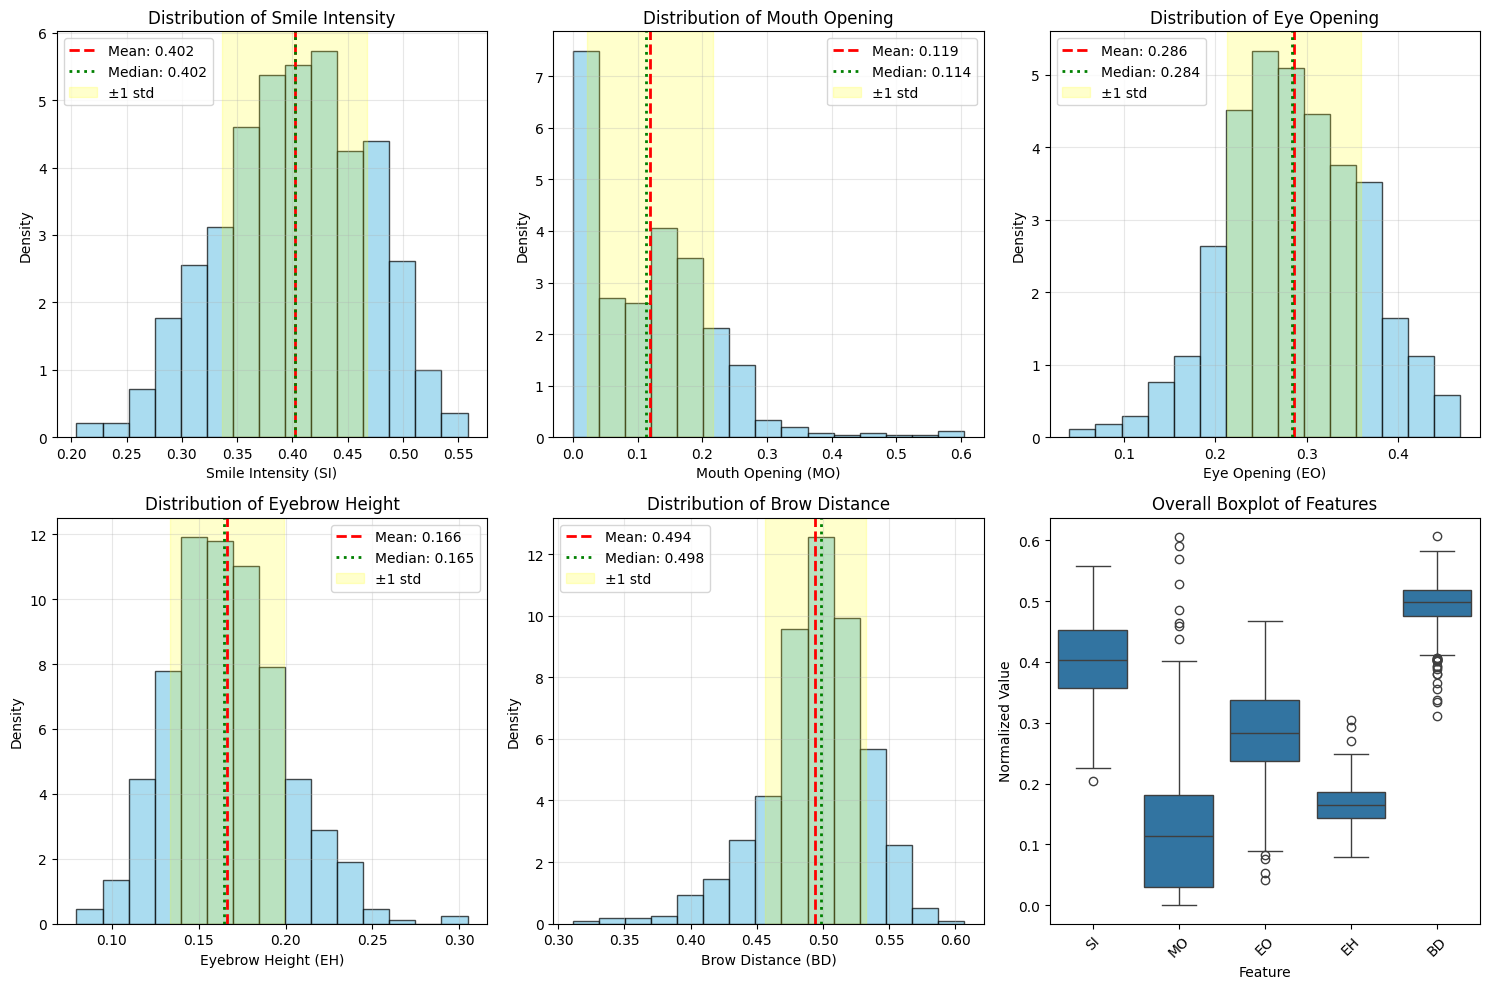

In [7]:

# 6. Display plots
print("\n" + "="*70)
print("Distribution Plots and Boxplots")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

features = ['SI', 'MO', 'EO', 'EH', 'BD']
feature_names = ['Smile Intensity', 'Mouth Opening', 'Eye Opening', 'Eyebrow Height', 'Brow Distance']

for idx, (feature, name) in enumerate(zip(features, feature_names)):
    ax = axes[idx]
    
    # Histogram
    ax.hist(df_data[feature].values, bins=15, alpha=0.7, color='skyblue', edgecolor='black', density=True)
    
    # Mean line
    mean_val = feature_stats[feature]['mean']
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.3f}')
    
    # Median line
    median_val = feature_stats[feature]['median']
    ax.axvline(median_val, color='green', linestyle=':', linewidth=2, label=f'Median: {median_val:.3f}')
    
    # ±1 standard deviation area
    std_val = feature_stats[feature]['std']
    ax.axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='yellow', label='±1 std')
    
    ax.set_xlabel(f'{name} ({feature})')
    ax.set_ylabel('Density')
    ax.set_title(f'Distribution of {name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    
# Overall boxplot
ax_box = axes[5]
df_happy_melted = df_data.melt(value_vars=features, var_name='Feature', value_name='Value')
sns.boxplot(data=df_happy_melted, x='Feature', y='Value', ax=ax_box)
ax_box.set_title('Overall Boxplot of Features')
ax_box.set_xlabel('Feature')
ax_box.set_ylabel('Normalized Value')
ax_box.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



In [9]:

# 7. Summary table
print("Summary Statistics Table")
print("="*70)

summary_df = pd.DataFrame({
    'Feature': features,
    'Mean': [feature_stats[f]['mean'] for f in features],
    'Median': [feature_stats[f]['median'] for f in features],
    'Std': [feature_stats[f]['std'] for f in features],
    'Min': [feature_stats[f]['min'] for f in features],
    'Max': [feature_stats[f]['max'] for f in features],
    'Range': [feature_stats[f]['range'] for f in features],
    'Skewness': [feature_stats[f]['skewness'] for f in features]
})

print(summary_df.to_string(index=False))


Summary Statistics Table
Feature     Mean   Median      Std      Min      Max    Range  Skewness
     SI 0.401937 0.402485 0.065531 0.204620 0.558339 0.353719 -0.232309
     MO 0.119093 0.113655 0.096900 0.000000 0.604594 0.604594  1.165936
     EO 0.286370 0.283680 0.073265 0.040632 0.467709 0.427077 -0.072684
     EH 0.166214 0.164559 0.032872 0.079739 0.304711 0.224972  0.431670
     BD 0.494198 0.498157 0.038363 0.311157 0.606454 0.295297 -0.858017


In [18]:
# 9. Show key insights
print("\n" + "="*70)
print("Key Insights for Membership Function Design:")
print("="*70)

print("\nFor SI (Smile Intensity):")
print(f"  - Happy people have SI between {feature_stats['SI']['q1']:.3f} and {feature_stats['SI']['q3']:.3f}")
print(f"  - Typical value: {feature_stats['SI']['mean']:.3f}")
print(f"  - Use triangular: [{feature_stats['SI']['min']:.3f}, {feature_stats['SI']['median']:.3f}, {feature_stats['SI']['max']:.3f}]")

print("\nFor MO (Mouth Opening):")
print(f"  - Wide variation: {feature_stats['MO']['min']:.3f} to {feature_stats['MO']['max']:.3f}")
print(f"  - Use trapezoidal to cover this wide range")

print("\nFor EO (Eye Opening):")
print(f"  - Gaussian is best due to natural variation in eye opening")
print(f"  - Mean: {feature_stats['EO']['mean']:.3f}, Std: {feature_stats['EO']['std']:.3f}")

print("\nFor BD (Brow Distance):")
print(f"  - Very consistent: range only {feature_stats['BD']['range']:.3f}")
print(f"  - Triangular with narrow base works well")


Key Insights for Membership Function Design:

For SI (Smile Intensity):
  - Happy people have SI between 0.357 and 0.452
  - Typical value: 0.402
  - Use triangular: [0.205, 0.402, 0.558]

For MO (Mouth Opening):
  - Wide variation: 0.000 to 0.605
  - Use trapezoidal to cover this wide range

For EO (Eye Opening):
  - Gaussian is best due to natural variation in eye opening
  - Mean: 0.286, Std: 0.073

For BD (Brow Distance):
  - Very consistent: range only 0.295
  - Triangular with narrow base works well


SI parameters: min=0.2046, median=0.4025, max=0.5583


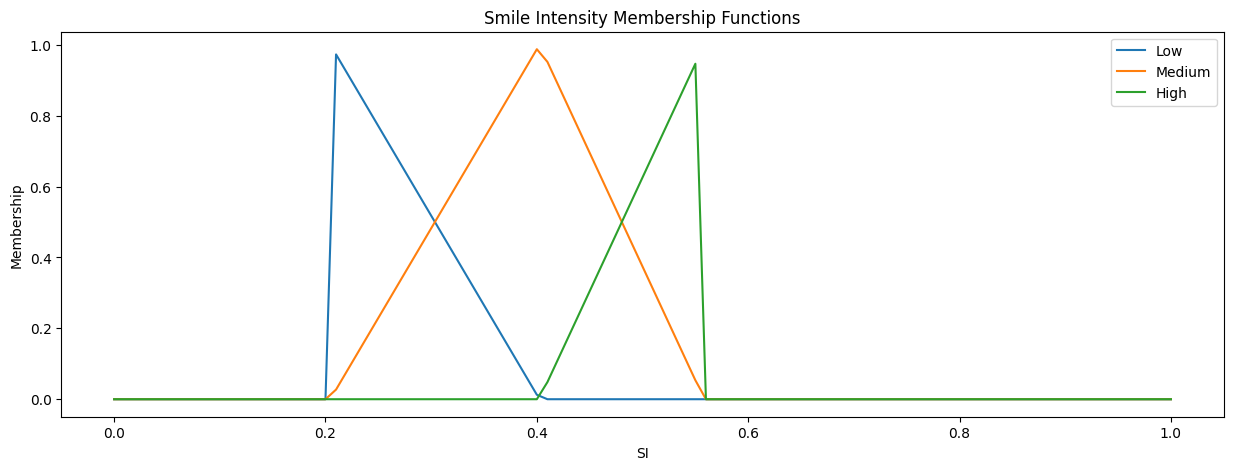

In [19]:
x_SI = np.arange(0, 1.01, 0.01)  # Smile Intensity: 0 to 1
x_MO = np.arange(0, 1.01, 0.01)  # Mouth Opening: 0 to 1
x_EO = np.arange(0, 1.01, 0.01)  # Eye Opening: 0 to 1
x_EH = np.arange(0, 1.01, 0.01)  # Eyebrow Height: 0 to 1
x_BD = np.arange(0, 1.01, 0.01)  # Brow Distance: 0 to 1

si_min = feature_stats['SI']['min']
si_med = feature_stats['SI']['median']
si_max = feature_stats['SI']['max']
print(f"SI parameters: min={si_min:.4f}, median={si_med:.4f}, max={si_max:.4f}")

SI_low = fuzz.trimf(
    x_SI,
    [si_min, si_min, si_med]
)

SI_med = fuzz.trimf(
    x_SI,
    [si_min, si_med, si_max]
)

SI_high = fuzz.trimf(
    x_SI,
    [si_med, si_max, si_max]
)


plt.figure(figsize=(15,5))

plt.plot(x_SI, SI_low, label='Low')
plt.plot(x_SI, SI_med, label='Medium')
plt.plot(x_SI, SI_high, label='High')

plt.title("Smile Intensity Membership Functions")
plt.xlabel("SI")
plt.ylabel("Membership")
plt.legend()

plt.show()


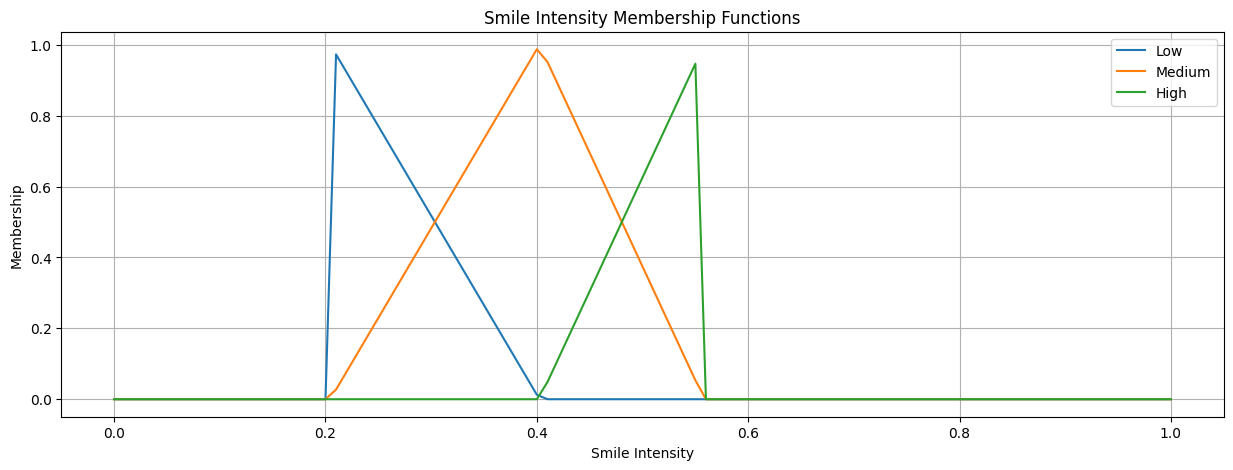

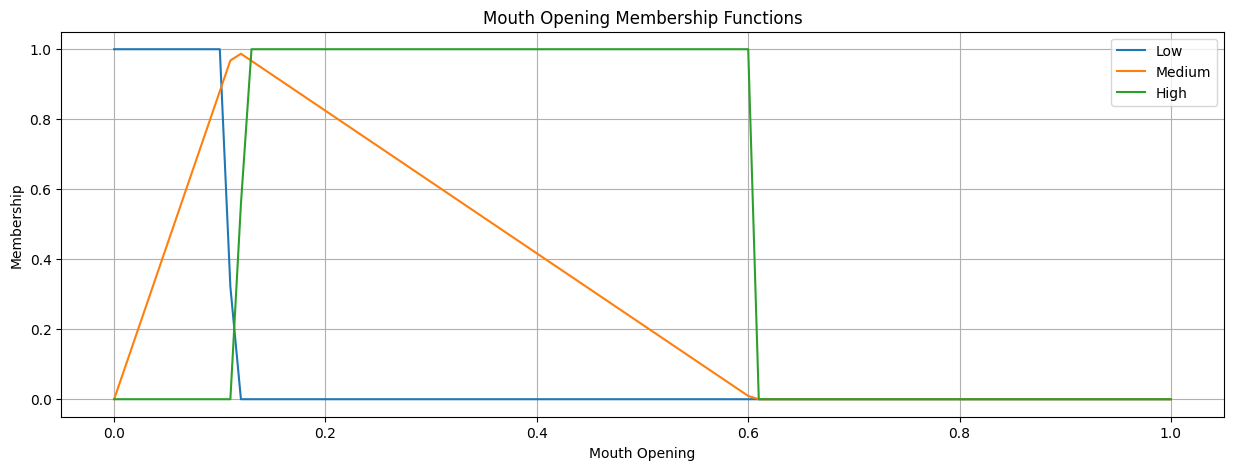

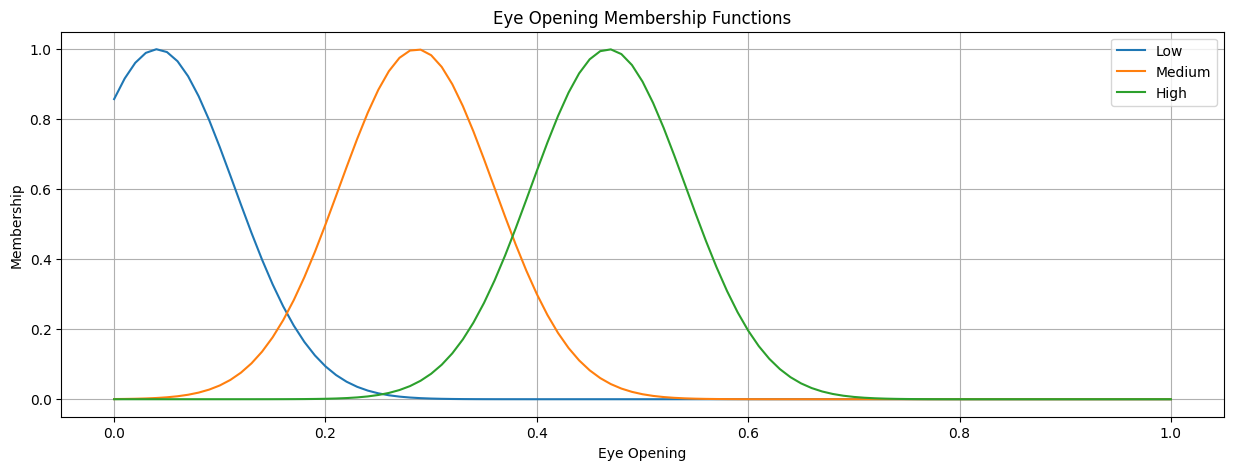

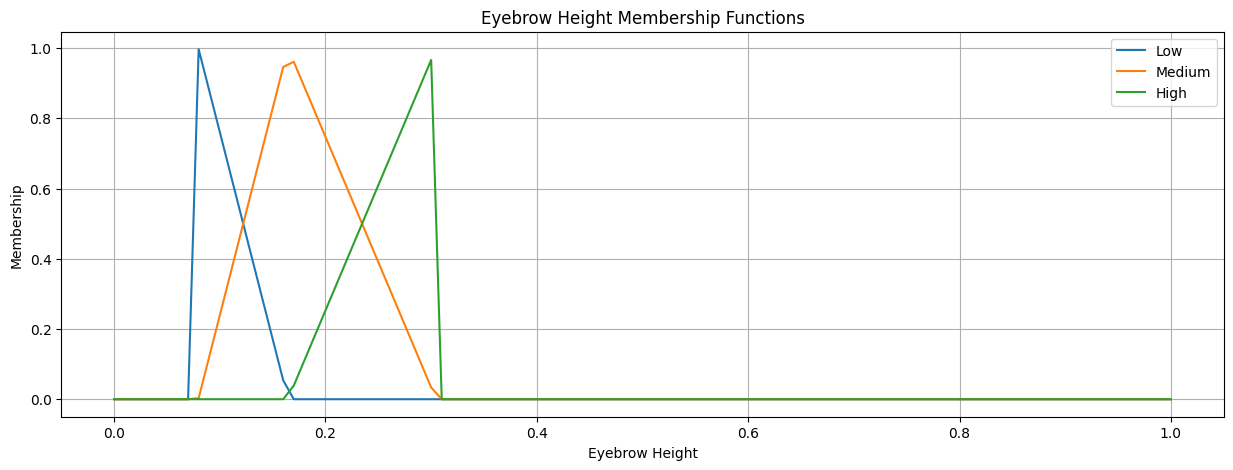

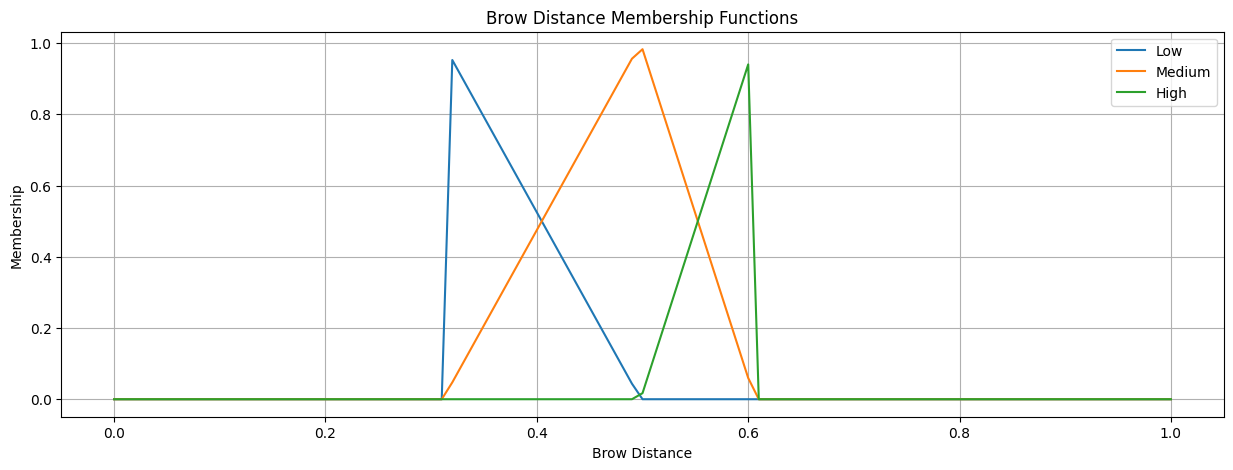

In [20]:
mo_min = feature_stats['MO']['min']
mo_med = feature_stats['MO']['median']
mo_max = feature_stats['MO']['max']

MO_low = fuzz.trapmf(x_MO, [mo_min, mo_min, mo_med*0.9, mo_med])
MO_med = fuzz.trimf(x_MO, [mo_min, mo_med, mo_max])
MO_high = fuzz.trapmf(x_MO, [mo_med, mo_med*1.1, mo_max, mo_max])



eo_mean = feature_stats['EO']['mean']
eo_std  = feature_stats['EO']['std']
eo_min  = feature_stats['EO']['min']
eo_max  = feature_stats['EO']['max']

EO_low = fuzz.gaussmf(x_EO, eo_min, eo_std)
EO_med = fuzz.gaussmf(x_EO, eo_mean, eo_std)
EO_high = fuzz.gaussmf(x_EO, eo_max, eo_std)



eh_min = feature_stats['EH']['min']
eh_med = feature_stats['EH']['median']
eh_max = feature_stats['EH']['max']

EH_low = fuzz.trimf(x_EH, [eh_min, eh_min, eh_med])
EH_med = fuzz.trimf(x_EH, [eh_min, eh_med, eh_max])
EH_high = fuzz.trimf(x_EH, [eh_med, eh_max, eh_max])



bd_min = feature_stats['BD']['min']
bd_med = feature_stats['BD']['median']
bd_max = feature_stats['BD']['max']

BD_low = fuzz.trimf(x_BD, [bd_min, bd_min, bd_med])
BD_med = fuzz.trimf(x_BD, [bd_min, bd_med, bd_max])
BD_high = fuzz.trimf(x_BD, [bd_med, bd_max, bd_max])


def plot_feature(x, low, med, high, name):
    
    plt.figure(figsize=(15,5))

    plt.plot(x, low, label='Low')
    plt.plot(x, med, label='Medium')
    plt.plot(x, high, label='High')

    plt.title(f"{name} Membership Functions")
    plt.xlabel(name)
    plt.ylabel("Membership")

    plt.legend()
    plt.grid(True)
    plt.show()



plot_feature(x_SI, SI_low, SI_med, SI_high, "Smile Intensity")
plot_feature(x_MO, MO_low, MO_med, MO_high, "Mouth Opening")
plot_feature(x_EO, EO_low, EO_med, EO_high, "Eye Opening")
plot_feature(x_EH, EH_low, EH_med, EH_high, "Eyebrow Height")
plot_feature(x_BD, BD_low, BD_med, BD_high, "Brow Distance")


In [14]:
bd_value = 0.55


bd_low_val = fuzz.interp_membership(x_BD, BD_low, bd_value)
bd_med_val = fuzz.interp_membership(x_BD, BD_med, bd_value)
bd_high_val = fuzz.interp_membership(x_BD, BD_high, bd_value)

print(f"At BD={bd_value:.2f}:")
print(f"  Low membership: {bd_low_val:.4f}")
print(f"  Medium membership: {bd_med_val:.4f}")
print(f"  High membership: {bd_high_val:.4f}")


At BD=0.55:
  Low membership: 0.0000
  Medium membership: 0.5213
  High membership: 0.4787


---
## Rules
---

In [21]:
# ruls
"""
Surprise
1.	R1: EH High AND MO High → Surprise
2.	R2: EO High AND EH High → Surprise
3.	R3: BD High AND MO High → Surprise
4.	R4: MO High AND SI Low AND EH High → Surprise
Happy
5.	R5: SI High AND EO Medium → Happy
6.	R6: SI High AND MO Medium → Happy
Angry
7.	R7: EH Low AND BD Low → Angry
8.	R8: EO Low AND MO Low → Angry
Sad
9.	R9: SI Low AND EO Low → Sad
10.	R10: MO Low AND EH Medium → Sad
11.	(+ optional extras)
Neutral
12.	R11: SI Medium AND MO Low AND EO Medium → Neutral
"""
x_sad = np.arange(0, 1.01, 0.01)
x_surprise = np.arange(0, 1.01, 0.01)
x_happy = np.arange(0, 1.01, 0.01)
x_neutral = np.arange(0, 1.01, 0.01)
x_angry = np.arange(0, 1.01, 0.01)

happy_low  = fuzz.trimf(x_happy, [0,0,0.4])
happy_med  = fuzz.trimf(x_happy, [0.2,0.5,0.8])
happy_high = fuzz.trimf(x_happy, [0.6,1,1])

sad_low  = fuzz.trimf(x_sad, [0,0,0.4])
sad_med  = fuzz.trimf(x_sad, [0.2,0.5,0.8])
sad_high = fuzz.trimf(x_sad, [0.6,1,1])

surprise_low  = fuzz.trimf(x_surprise,[0,0,0.4])
surprise_med  = fuzz.trimf(x_surprise,[0.2,0.5,0.8])
surprise_high = fuzz.trimf(x_surprise,[0.6,1,1])

angry_low  = fuzz.trimf(x_angry,[0,0,0.4])
angry_med  = fuzz.trimf(x_angry,[0.2,0.5,0.8])
angry_high = fuzz.trimf(x_angry,[0.6,1,1])

neutral_low  = fuzz.trimf(x_neutral,[0,0,0.4])
neutral_med  = fuzz.trimf(x_neutral,[0.2,0.5,0.8])
neutral_high = fuzz.trimf(x_neutral,[0.6,1,1])

def safe_defuzz(x, mf):
    if np.sum(mf) == 0:
        return 0.0
    return fuzz.defuzz(x, mf, 'centroid')


def check_emotion(points):
    
    si, mo, eo, eh, bd = points

    # ---------- Fuzzification ----------

    si_l = fuzz.interp_membership(x_SI, SI_low, si)
    si_m = fuzz.interp_membership(x_SI, SI_med, si)
    si_h = fuzz.interp_membership(x_SI, SI_high, si)

    mo_l = fuzz.interp_membership(x_MO, MO_low, mo)
    mo_m = fuzz.interp_membership(x_MO, MO_med, mo)
    mo_h = fuzz.interp_membership(x_MO, MO_high, mo)

    eo_l = fuzz.interp_membership(x_EO, EO_low, eo)
    eo_m = fuzz.interp_membership(x_EO, EO_med, eo)
    eo_h = fuzz.interp_membership(x_EO, EO_high, eo)

    eh_l = fuzz.interp_membership(x_EH, EH_low, eh)
    eh_m = fuzz.interp_membership(x_EH, EH_med, eh)
    eh_h = fuzz.interp_membership(x_EH, EH_high, eh)

    bd_l = fuzz.interp_membership(x_BD, BD_low, bd)
    bd_m = fuzz.interp_membership(x_BD, BD_med, bd)
    bd_h = fuzz.interp_membership(x_BD, BD_high, bd)

    # ---------- RULES ----------

    # === Surprise ===
    s1 = min(eh_h, mo_h)
    s2 = min(eo_h, eh_h)
    s3 = min(bd_h, mo_h)
    s4 = min(mo_h, si_l, eh_h)

    surprise_rule = max(s1, s2, s3, s4)

    # === Happy ===
    h1 = min(si_h, eo_m)
    h2 = min(si_h, mo_m)

    happy_rule = max(h1, h2)

    # === Sad ===
    sd1 = min(si_l, eo_l)
    sd2 = min(mo_l, eh_m)
    sd3 = min(si_l, mo_l)
    sd4 = min(eo_m, si_l)

    sad_rule = max(sd1, sd2, sd3, sd4)

    # === Angry ===
    a1 = min(eh_l, bd_l)
    a2 = min(eo_l, mo_l)

    angry_rule = max(a1, a2)

    # === Neutral ===
    n1 = min(si_m, mo_l, eo_m)

    neutral_rule = n1


    # ---------- IMPLICATION ----------

    surprise_out = np.fmin(surprise_rule, surprise_high)
    happy_out    = np.fmin(happy_rule, happy_high)
    sad_out      = np.fmin(sad_rule, sad_high)
    angry_out    = np.fmin(angry_rule, angry_high)
    neutral_out  = np.fmin(neutral_rule, neutral_high)


    # ---------- AGGREGATION ----------

    surprise_agg = surprise_out
    happy_agg    = happy_out
    sad_agg      = sad_out
    angry_agg    = angry_out
    neutral_agg  = neutral_out


    # ---------- DEFUZZIFICATION ----------

    surprise_score = safe_defuzz(x_surprise, surprise_agg)
    happy_score = safe_defuzz(x_happy, happy_agg)
    sad_score = safe_defuzz(x_sad, sad_agg)
    angry_score = safe_defuzz(x_angry, angry_agg)
    neutral_score = safe_defuzz(x_neutral, neutral_agg)


    # ---------- FINAL DECISION ----------

    scores = {
        "Surprise": surprise_score,
        "Happy": happy_score,
        "Sad": sad_score,
        "Angry": angry_score,
        "Neutral": neutral_score
    }

    final_emotion = max(scores, key=scores.get)


    # ---------- PRINT ----------

    print("\nEmotion Scores:")
    for k,v in scores.items():
        print(f"{k:8s} : {v:.3f}")

    print("\nFinal Emotion →", final_emotion)

    return final_emotion, scores


In [26]:
# sample_data = {'MO': np.float64(0.15514766018273363), 'EO': np.float64(0.21724169612145222), 'EH': np.float64(0.12319598928628464), 'BD': np.float64(0.5064382284024355), 'SI': np.float64(0.4593396210086046)}
# sample_data = {'MO': np.float64(0.024096899941875465), 'EO': np.float64(0.3209045637728929), 'EH': np.float64(0.12880892194237167), 'BD': np.float64(0.4750373917841956), 'SI': np.float64(0.3271586609923873)}
# sample_data = {'MO': np.float64(0.36364742287388657), 'EO': np.float64(0.1161324474343107), 'EH': np.float64(0.15151848574573432), 'BD': np.float64(0.5345220967280044), 'SI': np.float64(0.5148692483580007)} 
# sample_data = {'MO': np.float64(0.004759962316479499), 'EO': np.float64(0.25731773624720994), 'EH': np.float64(0.20704277511615002), 'BD': np.float64(0.541249843755753), 'SI': np.float64(0.4508110680190717)}
# sample_data = {'MO': np.float64(0.24699507832682024), 'EO': np.float64(0.08950079268647318), 'EH': np.float64(0.15446810639578984), 'BD': np.float64(0.5327276680779937), 'SI': np.float64(0.5318803858834393)}
# sample_data = {'MO': np.float64(0.25411220357890185), 'EO': np.float64(0.0987878395657156), 'EH': np.float64(0.11262236936695619), 'BD': np.float64(0.5105046457554856), 'SI': np.float64(0.5083618251675941)}
sample_data = {'MO': np.float64(0.5749353234139692), 'EO': np.float64(0.08437934844537405), 'EH': np.float64(0.11331137737381655), 'BD': np.float64(0.4893706678290721), 'SI': np.float64(0.41756894539557754)}
check_emotion([sample_data['SI'], sample_data['MO'], sample_data['EO'], sample_data['EH'], sample_data['BD']])


Emotion Scores:
Surprise : 0.000
Happy    : 0.806
Sad      : 0.000
Angry    : 0.805
Neutral  : 0.000

Final Emotion → Happy


('Happy',
 {'Surprise': 0.0,
  'Happy': np.float64(0.8062136893142765),
  'Sad': 0.0,
  'Angry': np.float64(0.8047969204556508),
  'Neutral': 0.0})

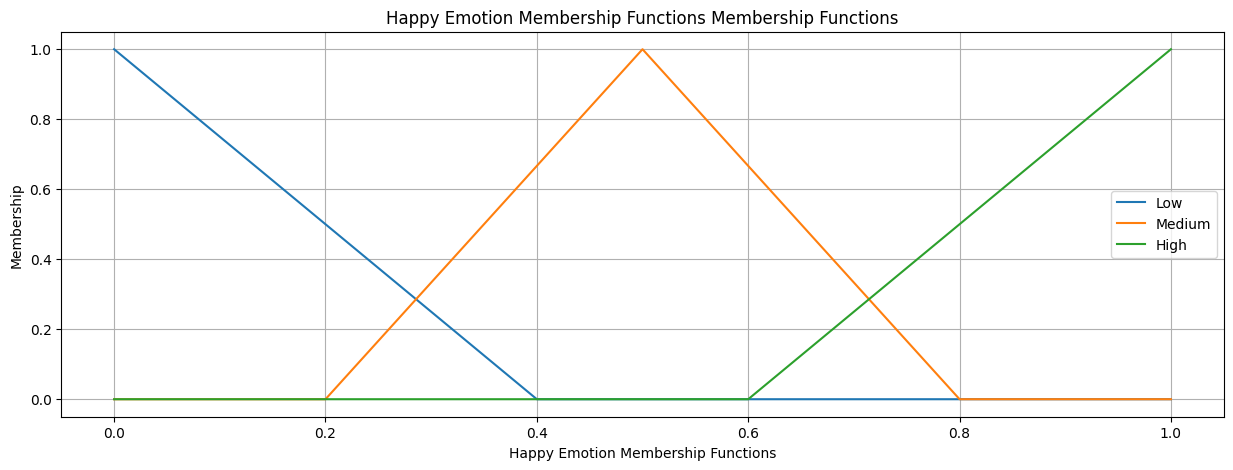

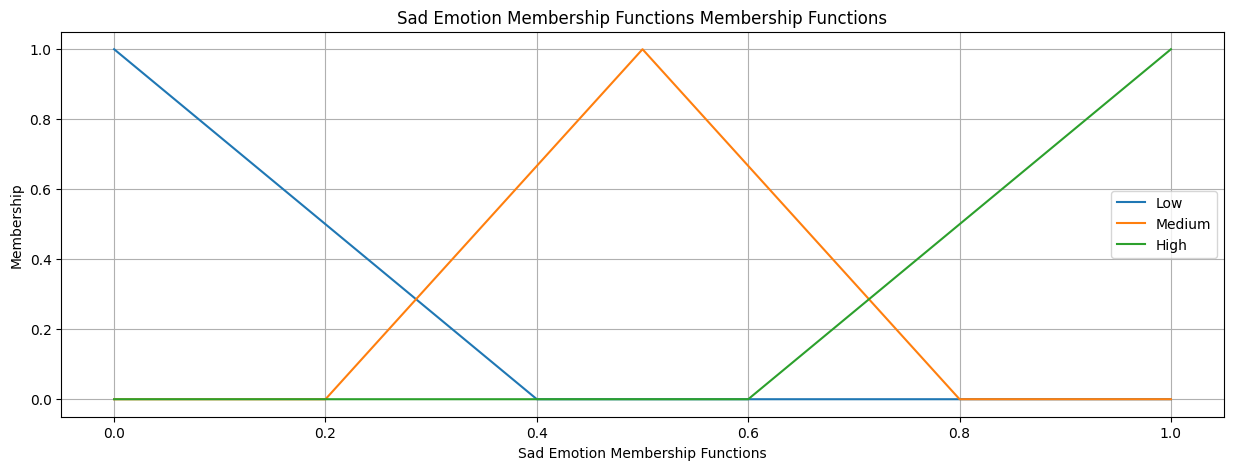

In [19]:
plot_feature(x_happy, happy_low, happy_med, happy_high, "Happy Emotion Membership Functions")
plot_feature(x_sad, sad_low, sad_med, sad_high, "Sad Emotion Membership Functions")